# Dependancies 

In [ ]:
import os
from openpyxl import Workbook
import matplotlib.pyplot as plt
import pandas as pd

# Something

In [2]:
import ME_modules.MakeWriteExcel as MWE
import ME_modules.Folder_n_File_Utilities as fnfu
import  ME_modules.ME_austin_EIS.chip_processor as MCP
processed_chips_folder_path = None
just_do_it = False
chip_choice = None

# Main

In [ ]:
def main(use_hardcoded_path=False, hardcoded_path=None):
    # Determine master folder
    if use_hardcoded_path and hardcoded_path:
        master_folder = hardcoded_path
    else:
        master_folder = fnfu.select_folder()
        if not master_folder:
            print("No folder selected. Exiting.")
            return

    # Processed chips folder stays in same directory as main code
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
        print(f"try base_dir: {base_dir}")
    except NameError:
        base_dir = os.getcwd()  # fallback for notebooks or interactive shells
        print(f"except base_dir: {base_dir}")

    processed_chips_folder = os.path.join(base_dir, "Processed Chips for PCAI1ia")
    os.makedirs(processed_chips_folder, exist_ok=True)

    # Output folder & log
    output_folder = os.path.join(master_folder, "Processed_Chip_Data")
    os.makedirs(output_folder, exist_ok=True)
    log_file = os.path.join(output_folder, "analysis_log.txt")
    open(log_file, 'w').close()

    # Validate chips
    chip_data = fnfu.find_valid_chips(master_folder)
    valid_chips, invalid_chips = fnfu.match_chip_files(chip_data)

    # Chip selection
    chip_choice = input("Enter chip number to process or 'all' to process all valid chips: ").strip()

    if chip_choice.lower() == 'all':
        chips_to_process = sorted(valid_chips.keys(), key=int)
        MWE.create_chips_folder_and_workbooks(processed_chips_folder)
    elif chip_choice in valid_chips:
        chips_to_process = [chip_choice]
        chip_name = f"Chip {chip_choice}"
        MWE.create_single_chip_workbook(chip_name, processed_chips_folder)
    else:
        fnfu.log_and_print(f"Invalid selection: {chip_choice}", log_file)
        return

    # 4. Processing Phase
    for chip in chips_to_process:
        chip_paths = valid_chips[chip]
        fnfu.log_and_print(f"\nProcessing Chip {chip}...", log_file)
        
        try:
            # Process the Excel file for the chip
            chip_results = MCP.process_chip_excel_only(chip, chip_paths,debug=True)

            if not chip_results:
                fnfu.log_and_print(f"No valid results for Chip {chip}", log_file)
                continue

            # Write results into correct workbook/sheets
            MCP.write_chip_results_to_workbook(chip_results, processed_chips_folder)
            fnfu.log_and_print(f"Successfully processed and wrote results for Chip {chip}", log_file)
            
        except Exception as e:
            fnfu.log_and_print(f"Error processing Chip {chip}: {str(e)}", log_file)
            continue
    
    print(f"MCP.all_raw_names_logged:{MCP.all_raw_names_logged}")
    fnfu.log_and_print("\nProcessing completed!", log_file)
    
    return os.path.abspath(processed_chips_folder) , chip_choice


In [ ]:
if __name__ == "__main__":
    processed_chips_folder_path , chip_choice = main()

In [ ]:
print("Done")

# Create Comparitive Graphs

In [ ]:
just_do_it = False
if chip_choice == "all" or just_do_it == True:
    import os
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    '''

    Min-max normalization (scale to 0-1):
    This method rescales the data so that the minimum value becomes 0 and the maximum becomes 1. 
    It's useful for comparing datasets with different ranges or units. The formula is: (value - min) / (max - min).

    Z-score normalization (subtract mean, divide by std):
    This method standardizes the data by subtracting the mean and dividing by the standard deviation. 
    It transforms the data into units of standard deviations from the mean, centering the distribution around zero. 
    This is helpful for identifying outliers or comparing data across different scales.

    Normalize to starting point (e.g., divide all values by the first time point value):
    This method divides all values by the first data point in the series, effectively setting the starting point to 1. 
    It's often used when studying relative changes over time. 
    This normalization highlights trends without focusing on absolute values.

    '''

    # --- 1. Path and Data Loading Setup ---
    # Get the base directory dynamically to handle both script and interactive environments
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()

    # Define the processed chips folder path
    processed_chips_folder_path = os.path.join(base_dir, "Processed Chips for PCAI1ia")

    # Make sure the folder exists (create it if not)
    os.makedirs(processed_chips_folder_path, exist_ok=True)
    folder_path = processed_chips_folder_path

    print("Using folder:", folder_path)

    if not folder_path:
        print("No folder selected. Exiting.")
        exit()

    # Normalization options
    normalize_min_max = True
    normalize_z_score = True
    normalize_start = True
    plot_boolean = False  # set True if you want plots

    CHIP_INFO = {
        #"CHIP TEMPLATE" : ["Cas_{complex} or Cas_{only}","{0.5} or {1} or {5} Conentration of MgCl2", "{HU} protein or {SCDU} protein"],
        'Chip 21': ["Cas_complex"   ,"0.5"   ,"HU"     ],
        'Chip 22': ["Cas_complex"   ,"0.5"   ,"HU"     ],
        'Chip 23': ["Cas_complex"   ,"5"     ,"SCDU"   ],
        'Chip 26': ["Cas_complex"   ,"5"     ,"HU"     ],
        'Chip 27': ["Cas_complex"   ,"5"     ,"HU"     ],
        'Chip 32': ["Cas_complex"   ,"5"     ,"HU"     ],
        'Chip 33': ["Cas_only"      ,"1"     ,"HU"     ],
        'Chip 35': ["Cas_complex"   ,"1"     ,"HU"     ],
        'Chip 36': ["Cas_only"      ,"1"     ,"HU"     ],
        'Chip 37': ["Cas_complex"   ,"1"     ,"HU"     ],
        'Chip 39': ["Cas_complex"   ,"1"     ,"HU"     ],
        'Chip 40': ["Cas_complex"   ,"1"     ,"HU"     ],
        'Chip 41': ["Cas_complex"   ,"1"     ,"SCDU"   ],
        'Chip 43': ["Cas_complex"   ,"5"     ,"SCDU"   ],
        'Chip 44': ["Cas_complex"   ,"5"     ,"SCDU"   ],
        'Chip 45': ["Cas_only"      ,"5"     ,"HU"     ],
        'Chip 46': ["Cas_complex"   ,"1"     ,"SCDU"   ],
        'Chip 47': ["Cas_only"      ,"1"     ,"HU"     ],
        'Chip 48': ["cas_complex"   ,"5"     ,"SCDU"   ],
        'Chip 52': ["Cas_complex"   ,"5"     ,"HU"     ],
        'Chip 53': ["Cas_complex"   ,"1"     ,"SCDU"   ],
        'Chip 54': ["Cas_only"      ,"5"     ,"HU"     ],
        'Chip 55': ["Cas_complex"   ,"1"     ,"SCDU"   ],
        'Chip 56': ["Cas_only"      ,"5"     ,"HU"     ],
        'Chip 57': ["Cas_only"      ,"5"     ,"HU"     ],
        'Chip 59': ["Cas_complex"   ,"0.5"   ,"HU"     ]
    }

    # Constants
    workbook_names = [f"Chip {n}" for n in [21,22,23,26,27,32,33,35,36,37,39,40,41,43,44,45,46,47,48,52,53,54,55,56,57,59]]
    worksheet_names = ["0pM_asso", "0pM_disso", "100pM_asso", "100pM_disso", "1nM_asso", "1nM_disso", "10nM_asso", "10nM_disso", "100nM_asso", "100nM_disso"]
    headers = [
        'time(mins)', 'delta Rct-a', 'normalized Rct_a','delta Rct-d','normalized Rct_d', 'Cp1', 'Ph1', 
        'Slope 1', 'Slope 2', 'Slope 3', 'Slope 4', 'Slope 5', 
        'Angle', 'Cp_exp-a', 'Cp_exp-b', 'Ph_slope', 'Ph_peak', 
        'Area Cp', 'Area Ph', 'Area Slope', 'Area Rs-direct', 'Area Rs-Para',
        '','','linear_eq_m','linear_eq_b','Rs','delta Rct-i','Q','n'
    ]
    # Read and combine all data
    all_data = []
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        chip_name = os.path.splitext(file_name)[0]

        if chip_name not in workbook_names or not file_path.endswith(".xlsx"):
            continue

        xl = pd.ExcelFile(file_path)
        for sheet in xl.sheet_names:
            if sheet not in worksheet_names:
                continue

            df = xl.parse(sheet, usecols=lambda col: col in headers)
            df['chip'] = chip_name
            df['sheet'] = sheet
            all_data.append(df)

    if not all_data:
        print("No valid data found.")
        exit()

    df_all = pd.concat(all_data, ignore_index=True)

    # Add CHIP_INFO metadata
    chip_info_df = pd.DataFrame.from_dict(CHIP_INFO, orient='index', columns=['Type', 'Concentration', 'Protein']).reset_index().rename(columns={'index': 'chip'})
    df_all = df_all.merge(chip_info_df, on='chip', how='left')

    # Define plot groups
    plots = {
        "Plot 1": [("Cas_complex", "5", "HU"), ("Cas_only", "5", "HU")],
        "Plot 2": [("Cas_complex", "5", "SCDU"), ("Cas_complex", "5", "HU")],
        "Plot 3": [("Cas_complex", "0.5", "HU"), ("Cas_complex", "1", "HU"), ("Cas_complex", "5", "HU")],
        "Plot 4": [("Cas_complex", "0.5", "SCDU"), ("Cas_complex", "1", "SCDU"), ("Cas_complex", "5", "SCDU")]
    }

    y_vars = ['delta Rct-a', 'linear_eq_m']

    # Normalization methods
    normalizations = {
        'min-max': lambda y, min_val, max_val: (y - min_val) / (max_val - min_val) if (max_val - min_val) != 0 else np.nan,
        'z-score': lambda y, mean, std: (y - mean) / std if std != 0 else np.nan,
        'start': lambda y, start_val: y / start_val if start_val != 0 else np.nan
    }

    # Create main output folder
    main_output_folder = os.path.join(folder_path, "comparison graphs")
    os.makedirs(main_output_folder, exist_ok=True)

    # Create folders per normalization, per concentration, per worksheet
    for norm_name, norm_func in normalizations.items():
        norm_folder = os.path.join(main_output_folder, norm_name)
        os.makedirs(norm_folder, exist_ok=True)

        for y_var in y_vars:
            for plot_name, groups in plots.items():
                for worksheet in worksheet_names:
                    # Extract concentration prefix (e.g., '0pM' from '0pM_asso')
                    concentration = worksheet.split("_")[0]
                    condition = worksheet  # e.g., '0pM_asso'

                    # Create subfolders: concentration folder + condition folder
                    conc_folder = os.path.join(norm_folder, concentration)
                    condition_folder = os.path.join(conc_folder, condition)
                    os.makedirs(condition_folder, exist_ok=True)

                    plt.figure(figsize=(8,6))

                    for g in groups:
                        subset = df_all[
                            (df_all['Type'] == g[0]) &
                            (df_all['Concentration'] == g[1]) &
                            (df_all['Protein'] == g[2]) &
                            (df_all['sheet'] == worksheet)
                        ]

                        if subset.empty:
                            print(f"No data for {g} in {plot_name} ({worksheet})")
                            continue

                        grouped = subset.groupby('time(mins)')[y_var].mean().reset_index()
                        if grouped.empty:
                            print(f"No data for {g} in {plot_name} ({worksheet})")
                            continue

                        min_val = grouped[y_var].min()
                        max_val = grouped[y_var].max()
                        mean_val = grouped[y_var].mean()
                        std_val = grouped[y_var].std()
                        first_val = grouped[y_var].iloc[0] if not grouped.empty else 0

                        if norm_name == 'min-max':
                            norm_y = norm_func(grouped[y_var], min_val, max_val)
                        elif norm_name == 'z-score':
                            norm_y = norm_func(grouped[y_var], mean_val, std_val)
                        elif norm_name == 'start':
                            norm_y = norm_func(grouped[y_var], first_val)
                        else:
                            norm_y = grouped[y_var]

                        plt.plot(grouped['time(mins)'], norm_y, label=f"{g}")

                    plt.xlabel('time(mins)')
                    plt.ylabel(f"{y_var} ({norm_name})")
                    plt.title(f"{plot_name} - {y_var} ({worksheet}, {norm_name})")
                    plt.legend()
                    plt.tight_layout()

                    # Save figure in the appropriate subfolder
                    safe_plot_name = plot_name.replace(" ", "_")
                    safe_y_var = y_var.replace(" ", "_").replace("-", "_")
                    safe_worksheet = worksheet.replace(" ", "_").replace("-", "_")
                    filename = f"{safe_plot_name}_{safe_y_var}_{safe_worksheet}.png"
                    plt.savefig(os.path.join(condition_folder, filename))
                    plt.close()
    else:
        print("Next time.")

In [ ]:
print("Done")

# Big Excel for Deepta

In [ ]:
just_do_it = False
if chip_choice == "all" or just_do_it == True:
    import os
    import pandas as pd
    import numpy as np
    from sklearn.linear_model import LinearRegression
    from scipy.optimize import curve_fit
    import matplotlib.pyplot as plt

    plot_boolean = False  # set True if you want plots

    # --- 1. Path and Data Loading Setup ---
    # Get the base directory dynamically to handle both script and interactive environments
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()

    # Define the processed chips folder path
    processed_chips_folder_path = os.path.join(base_dir, "Processed Chips for PCAI1ia")

    # Make sure the folder exists (create it if not)
    os.makedirs(processed_chips_folder_path, exist_ok=True)
    folder_path = processed_chips_folder_path

    print("Using folder:", folder_path)

    if not folder_path:
        print("No folder selected. Exiting.")
        exit()

    # Constants
    workbook_names = [f"Chip {n}" for n in [21,22,23,26,27,32,33,35,36,37,39,40,41,43,44,45,46,47,48,52,53,54,55,56,57,59]]
    worksheet_names = [
        "0pM_asso", "0pM_disso",
        "100pM_asso", "100pM_disso",
        "1nM_asso", "1nM_disso",
        "10nM_asso", "10nM_disso",
        "100nM_asso", "100nM_disso"
    ]

    CHIP_INFO = {
        'Chip 21': ["Cas_complex", "0.5", "HU"], 'Chip 22': ["Cas_complex", "0.5", "HU"],
        'Chip 23': ["Cas_complex", "5", "SCDU"], 'Chip 26': ["Cas_complex", "5", "HU"],
        'Chip 27': ["Cas_complex", "5", "HU"], 'Chip 32': ["Cas_complex", "5", "HU"],
        'Chip 33': ["Cas_only", "1", "HU"], 'Chip 35': ["Cas_complex", "1", "HU"],
        'Chip 36': ["Cas_only", "1", "HU"], 'Chip 37': ["Cas_complex", "1", "HU"],
        'Chip 39': ["Cas_complex", "1", "HU"], 'Chip 40': ["Cas_complex", "1", "HU"],
        'Chip 41': ["Cas_complex", "1", "SCDU"], 'Chip 43': ["Cas_complex", "5", "SCDU"],
        'Chip 44': ["Cas_complex", "5", "SCDU"], 'Chip 45': ["Cas_only", "5", "HU"],
        'Chip 46': ["Cas_complex", "1", "SCDU"], 'Chip 47': ["Cas_only", "1", "HU"],
        'Chip 48': ["cas_complex", "5", "SCDU"], 'Chip 52': ["Cas_complex", "5", "HU"],
        'Chip 53': ["Cas_complex", "1", "SCDU"], 'Chip 54': ["Cas_only", "5", "HU"],
        'Chip 55': ["Cas_complex", "1", "SCDU"], 'Chip 56': ["Cas_only", "5", "HU"],
        'Chip 57': ["Cas_only", "5", "HU"], 'Chip 59': ["Cas_complex", "0.5", "HU"]
    }

    def plot_chip_results(X, y_a, y_d, slope_a, intercept_a, r2_a,
                        slope_d, intercept_d, r2_d,
                        exp_A_a, exp_b_a, r2_exp_a,
                        exp_A_d, exp_b_d, r2_exp_d,
                        chip_name, sheet, plot_boolean=False):
        
        """
        Plots delta Rct-a and delta Rct-d with both linear regression and exponential fits.
        """

        if plot_boolean == True:
            # Create figure
            plt.figure(figsize=(10, 6))

            # Raw scatter data
            plt.scatter(X, y_a, color="blue", label="ΔRct-a data")
            plt.scatter(X, y_d, color="green", label="ΔRct-d data")

            # Smooth X for curves
            x_smooth = np.linspace(min(X), max(X), 200)

            # Linear fits
            y_a_lin = slope_a * x_smooth + intercept_a
            y_d_lin = slope_d * x_smooth + intercept_d
            plt.plot(x_smooth, y_a_lin, "b--", label=f"ΔRct-a Linear (R²={r2_a:.3f})")
            plt.plot(x_smooth, y_d_lin, "g--", label=f"ΔRct-d Linear (R²={r2_d:.3f})")

            # Exponential fits (only if valid)
            if not np.isnan(exp_A_a) and not np.isnan(exp_b_a):
                y_a_exp = exp_A_a * np.exp(exp_b_a * x_smooth)
                plt.plot(x_smooth, y_a_exp, "b-", label=f"ΔRct-a Exp (R²={r2_exp_a:.3f})")

            if not np.isnan(exp_A_d) and not np.isnan(exp_b_d):
                y_d_exp = exp_A_d * np.exp(exp_b_d * x_smooth)
                plt.plot(x_smooth, y_d_exp, "g-", label=f"ΔRct-d Exp (R²={r2_exp_d:.3f})")

            # Labels and title
            plt.xlabel("Concentration")
            plt.ylabel("ΔRct")
            plt.title(f"Chip: {chip_name}, Condition: {sheet}")
            plt.legend()
            plt.grid(True, alpha=0.3)

            plt.show()
        else:
            return

    def exp_func(x, A, b):
        return A * np.exp(b * x)

    results = []

    for file_name in os.listdir(processed_chips_folder_path):
        file_path = os.path.join(processed_chips_folder_path, file_name)
        chip_name = os.path.splitext(file_name)[0]

        if chip_name not in workbook_names or not file_path.endswith(".xlsx"):
            continue

        xl = pd.ExcelFile(file_path)

        df_0_asso = xl.parse("0pM_asso") if "0pM_asso" in xl.sheet_names else None
        df_0_disso = xl.parse("0pM_disso") if "0pM_disso" in xl.sheet_names else None

        for sheet in xl.sheet_names:
            if sheet not in worksheet_names:
                continue

            df = xl.parse(sheet)
            df.columns = df.columns.str.strip()  # clean up column headers

            if df.empty:
                continue

            X = df['time(mins)'].iloc[1:].values.reshape(-1, 1)

            # --- Linear regression for delta Rct-a ---
            try:
                y_a = df['delta Rct-a'].iloc[1:].values
                model_a = LinearRegression().fit(X, y_a)
                slope_a = model_a.coef_[0]
                r2_a = model_a.score(X, y_a)
            except Exception as e:
                slope_a, r2_a, y_a, model_a = np.nan, np.nan, None, None

            # --- Linear regression for delta Rct-d ---
            try:
                y_d = df['delta Rct-d'].iloc[1:].values
                model_d = LinearRegression().fit(X, y_d)
                slope_d = model_d.coef_[0]
                r2_d = model_d.score(X, y_d)
            except Exception as e:
                slope_d, r2_d, y_d, model_d = np.nan, np.nan, None, None

            # --- Exponential fit for delta Rct-a ---
            try:
                popt_a, _ = curve_fit(exp_func, X.flatten(), y_a, maxfev=5000)
                exp_A_a, exp_b_a = popt_a
                y_pred_a = exp_func(X.flatten(), *popt_a)
                ss_res_a = np.sum((y_a - y_pred_a) ** 2)
                ss_tot_a = np.sum((y_a - np.mean(y_a)) ** 2)
                r2_exp_a = 1 - (ss_res_a / ss_tot_a) if ss_tot_a > 0 else np.nan
            except Exception:
                exp_A_a, exp_b_a, r2_exp_a, y_pred_a = np.nan, np.nan, np.nan, None

            # --- Exponential fit for delta Rct-d ---
            try:
                popt_d, _ = curve_fit(exp_func, X.flatten(), y_d, maxfev=5000)
                exp_A_d, exp_b_d = popt_d
                y_pred_d = exp_func(X.flatten(), *popt_d)
                ss_res_d = np.sum((y_d - y_pred_d) ** 2)
                ss_tot_d = np.sum((y_d - np.mean(y_d)) ** 2)
                r2_exp_d = 1 - (ss_res_d / ss_tot_d) if ss_tot_d > 0 else np.nan
            except Exception:
                exp_A_d, exp_b_d, r2_exp_d, y_pred_d = np.nan, np.nan, np.nan, None

            # Get the normalized columns
            try:
                y_norm_a = df['normalized Rct_a'].iloc[1:].values
                y_norm_d = df['normalized Rct_d'].iloc[1:].values

                # Linear regression for normalized delta Rct-a
                model_norm_a = LinearRegression().fit(X, y_norm_a)
                norm_slope_a = model_norm_a.coef_[0]
                norm_r2_a = model_norm_a.score(X, y_norm_a)

                # Linear regression for normalized delta Rct-d
                model_norm_d = LinearRegression().fit(X, y_norm_d)
                norm_slope_d = model_norm_d.coef_[0]
                norm_r2_d = model_norm_d.score(X, y_norm_d)
            except Exception:
                norm_slope_a, norm_slope_d = np.nan, np.nan
                norm_r2_a, norm_r2_d = np.nan, np.nan

            # Exponential fits
            try:
                popt_norm_a, _ = curve_fit(exp_func, X.flatten(), y_norm_a, maxfev=5000)
                norm_exp_A_a, norm_exp_b_a = popt_norm_a
                y_pred_norm_a = exp_func(X.flatten(), *popt_norm_a)
                ss_res_norm_a = np.sum((y_norm_a - y_pred_norm_a)**2)
                ss_tot_norm_a = np.sum((y_norm_a - np.mean(y_norm_a))**2)
                r2_exp_norm_a = 1 - (ss_res_norm_a / ss_tot_norm_a) if ss_tot_norm_a > 0 else np.nan
            except Exception:
                norm_exp_A_a, norm_exp_b_a, r2_exp_norm_a = np.nan, np.nan, np.nan

            try:
                popt_norm_d, _ = curve_fit(exp_func, X.flatten(), y_norm_d, maxfev=5000)
                norm_exp_A_d, norm_exp_b_d = popt_norm_d
                y_pred_norm_d = exp_func(X.flatten(), *popt_norm_d)
                ss_res_norm_d = np.sum((y_norm_d - y_pred_norm_d)**2)
                ss_tot_norm_d = np.sum((y_norm_d - np.mean(y_norm_d))**2)
                r2_exp_norm_d = 1 - (ss_res_norm_d / ss_tot_norm_d) if ss_tot_norm_d > 0 else np.nan
            except Exception:
                norm_exp_A_d, norm_exp_b_d, r2_exp_norm_d = np.nan, np.nan, np.nan



            # ✅ Call your plotting function here
            plot_chip_results(
                X.flatten(),        # X values
                y_a,                # delta Rct-a
                y_d,                # delta Rct-d
                slope_a,            # slope_a
                model_a.intercept_ if model_a else 0,   # intercept_a
                r2_a,
                slope_d,
                model_d.intercept_ if model_d else 0,   # intercept_d
                r2_d,
                exp_A_a,
                exp_b_a,
                r2_exp_a,
                exp_A_d,
                exp_b_d,
                r2_exp_d,
                chip_name,
                sheet,
                plot_boolean
            )

            # --- Subtraction vs 0pM, matched by chip and phase ---
            (
                delta_a_minus_0_slope, delta_d_minus_0_slope, 
                delta_normalized_a_minus_0_slope, delta_normalized_d_minus_0_slope,
                delta_a_minus_0_exp_A, delta_a_minus_0_exp_b,
                delta_d_minus_0_exp_A, delta_d_minus_0_exp_b,
                delta_normalized_a_minus_0_exp_A, delta_normalized_a_minus_0_exp_b,
                delta_normalized_d_minus_0_exp_A, delta_normalized_d_minus_0_exp_b,
                delta_normalized_a_minus_0_exp_A_addfor_53, delta_normalized_a_minus_0_exp_b_addfor_53,
                delta_normalized_d_minus_0_exp_A_addfor_53, delta_normalized_d_minus_0_exp_b_addfor_53
            ) = (np.nan, ) * 16
            
            chip_type, mgcl_conc, protein = CHIP_INFO.get(chip_name, ["", "", ""])
            results.append({
                "Chip Name": chip_name,
                "Type": chip_type,
                "Concentration (MgCl)": mgcl_conc,
                "Protein": protein,
                "Concentration": sheet,

                "delta Rct-a Slope": slope_a,
                "R^2_a": r2_a,
                "delta Rct-d Slope": slope_d,
                "R^2_d": r2_d,

                "delta Rct-a slope concentration minus zero concentration slope": delta_a_minus_0_slope,
                "delta Rct-d slope concentration minus zero concentration slope ": delta_d_minus_0_slope,

                "delta Rct-a Exponential A": exp_A_a,
                "delta Rct-a Exponential b": exp_b_a,
                "R^2_exp_a": r2_exp_a,
                "delta Rct-d Exponential A": exp_A_d,
                "delta Rct-d Exponential b": exp_b_d,
                "R^2_exp_d": r2_exp_d,

                "delta Rct-a exp A concentration minus zero concentration exp A": delta_a_minus_0_exp_A,
                "delta Rct-a exp b concentration minus zero concentration exp b": delta_a_minus_0_exp_b,
                "delta Rct-d exp A concentration minus zero concentration exp A ": delta_d_minus_0_exp_A,
                "delta Rct-d exp b concentration minus zero concentration exp b ": delta_d_minus_0_exp_b,

                "delta normalized Rct-a Slope": norm_slope_a,
                "R^2_a": norm_r2_a,
                "delta normalized Rct-d Slope": norm_slope_d,
                "R^2_d": norm_r2_d,

                "delta normalized Rct-a slope concentration minus zero concentration slope": delta_normalized_a_minus_0_slope,
                "delta normalized Rct-d slope concentration minus zero concentration slope": delta_normalized_d_minus_0_slope,

                "delta normalized Rct-a Exponential A": norm_exp_A_a,
                "delta normalized Rct-a Exponential b": norm_exp_b_a,
                "normalized R^2_exp_a": r2_exp_norm_a,
                "delta normalized Rct-d Exponential A": norm_exp_A_d,
                "delta normalized Rct-d Exponential b": norm_exp_b_d,
                "normalized R^2_exp_d": r2_exp_norm_d,

                "delta normalized Rct-a exp A concentration minus zero concentration exp A": delta_normalized_a_minus_0_exp_A,
                "delta normalized Rct-a exp b concentration minus zero concentration exp b": delta_normalized_a_minus_0_exp_b,
                "delta normalized Rct-d exp A concentration minus zero concentration exp A ": delta_normalized_d_minus_0_exp_A,
                "delta normalized Rct-d exp b concentration minus zero concentration exp b ": delta_normalized_d_minus_0_exp_b,
                "delta normalized Rct-a exp A concentration minus zero concentration exp A added 0pM for 53": delta_normalized_a_minus_0_exp_A_addfor_53,
                "delta normalized Rct-a exp b concentration minus zero concentration exp b added 0pM for 53": delta_normalized_a_minus_0_exp_b_addfor_53,
                "delta normalized Rct-d exp A concentration minus zero concentration exp A added 0pM for 53": delta_normalized_d_minus_0_exp_A_addfor_53,
                "delta normalized Rct-d exp b concentration minus zero concentration exp b added 0pM for 53": delta_normalized_d_minus_0_exp_b_addfor_53

            })

    # After building results list
    output_df = pd.DataFrame(results)

    # Initialize columns
    cols_to_init = [
        "delta Rct-a slope concentration minus zero concentration slope",
        "delta Rct-d slope concentration minus zero concentration slope ",
        "delta Rct-a exp A concentration minus zero concentration exp A",
        "delta Rct-a exp b concentration minus zero concentration exp b",
        "delta Rct-d exp A concentration minus zero concentration exp A ",
        "delta Rct-d exp b concentration minus zero concentration exp b ",
        "delta normalized Rct-a slope concentration minus zero concentration slope",
        "delta normalized Rct-d slope concentration minus zero concentration slope",
        "delta normalized Rct-a exp A concentration minus zero concentration exp A",
        "delta normalized Rct-a exp b concentration minus zero concentration exp b",
        "delta normalized Rct-d exp A concentration minus zero concentration exp A ",
        "delta normalized Rct-d exp b concentration minus zero concentration exp b ",
        "delta normalized Rct-a exp A concentration minus zero concentration exp A added 0pM for 53",
        "delta normalized Rct-a exp b concentration minus zero concentration exp b added 0pM for 53",
        "delta normalized Rct-d exp A concentration minus zero concentration exp A added 0pM for 53",
        "delta normalized Rct-d exp b concentration minus zero concentration exp b added 0pM for 53"
    ]

    for col in cols_to_init:
        output_df[col] = np.nan

    chips = output_df['Chip Name'].unique()
    for chip in chips:
        print(chip)
        chip_rows = output_df[output_df['Chip Name'] == chip].index

        # Reference values for this chip
        asso_ref = {
            "slope_a": output_df.loc[chip_rows[0], 'delta Rct-a Slope'],
            "slope_d": output_df.loc[chip_rows[0], 'delta Rct-d Slope'],
            "exp_A_a": output_df.loc[chip_rows[0], 'delta Rct-a Exponential A'],
            "exp_b_a": output_df.loc[chip_rows[0], 'delta Rct-a Exponential b'],
            "exp_A_d": output_df.loc[chip_rows[0], 'delta Rct-d Exponential A'],
            "exp_b_d": output_df.loc[chip_rows[0], 'delta Rct-d Exponential b'],
            "norm_slope_a": output_df.loc[chip_rows[0], 'delta normalized Rct-a Slope'],
            "norm_slope_d": output_df.loc[chip_rows[0], 'delta normalized Rct-d Slope'],
            "norm_exp_A_a": output_df.loc[chip_rows[0], 'delta normalized Rct-a Exponential A'],
            "norm_exp_b_a": output_df.loc[chip_rows[0], 'delta normalized Rct-a Exponential b'],
            "norm_exp_A_d": output_df.loc[chip_rows[0], 'delta normalized Rct-d Exponential A'],
            "norm_exp_b_d": output_df.loc[chip_rows[0], 'delta normalized Rct-d Exponential b']
        }

        disso_ref = {
            "slope_a": output_df.loc[chip_rows[1], 'delta Rct-a Slope'],
            "slope_d": output_df.loc[chip_rows[1], 'delta Rct-d Slope'],
            "exp_A_a": output_df.loc[chip_rows[1], 'delta Rct-a Exponential A'],
            "exp_b_a": output_df.loc[chip_rows[1], 'delta Rct-a Exponential b'],
            "exp_A_d": output_df.loc[chip_rows[1], 'delta Rct-d Exponential A'],
            "exp_b_d": output_df.loc[chip_rows[1], 'delta Rct-d Exponential b'],
            "norm_slope_a": output_df.loc[chip_rows[1], 'delta normalized Rct-a Slope'],
            "norm_slope_d": output_df.loc[chip_rows[1], 'delta normalized Rct-d Slope'],
            "norm_exp_A_a": output_df.loc[chip_rows[1], 'delta normalized Rct-a Exponential A'],
            "norm_exp_b_a": output_df.loc[chip_rows[1], 'delta normalized Rct-a Exponential b'],
            "norm_exp_A_d": output_df.loc[chip_rows[1], 'delta normalized Rct-d Exponential A'],
            "norm_exp_b_d": output_df.loc[chip_rows[1], 'delta normalized Rct-d Exponential b']
        }

        for i, idx in enumerate(chip_rows):
            ref = asso_ref if i % 2 == 0 else disso_ref


            # Slopes
            output_df.loc[idx, 'delta Rct-a slope concentration minus zero concentration slope'] = output_df.loc[idx, 'delta Rct-a Slope'] - ref["slope_a"]
            output_df.loc[idx, 'delta Rct-d slope concentration minus zero concentration slope '] = output_df.loc[idx, 'delta Rct-d Slope'] - ref["slope_d"]

            # Exponential
            output_df.loc[idx, 'delta Rct-a exp A concentration minus zero concentration exp A'] = output_df.loc[idx, 'delta Rct-a Exponential A'] - ref["exp_A_a"]
            output_df.loc[idx, 'delta Rct-a exp b concentration minus zero concentration exp b'] = output_df.loc[idx, 'delta Rct-a Exponential b'] - ref["exp_b_a"]
            output_df.loc[idx, 'delta Rct-d exp A concentration minus zero concentration exp A '] = output_df.loc[idx, 'delta Rct-d Exponential A'] - ref["exp_A_d"]
            output_df.loc[idx, 'delta Rct-d exp b concentration minus zero concentration exp b '] = output_df.loc[idx, 'delta Rct-d Exponential b'] - ref["exp_b_d"]

            # Normalized slopes
            output_df.loc[idx, 'delta normalized Rct-a slope concentration minus zero concentration slope'] = output_df.loc[idx, 'delta normalized Rct-a Slope'] - ref["norm_slope_a"]
            output_df.loc[idx, 'delta normalized Rct-d slope concentration minus zero concentration slope'] = output_df.loc[idx, 'delta normalized Rct-d Slope'] - ref["norm_slope_d"]

            # Normalized exponential
            output_df.loc[idx, 'delta normalized Rct-a exp A concentration minus zero concentration exp A'] = output_df.loc[idx, 'delta normalized Rct-a Exponential A'] - ref["norm_exp_A_a"]
            output_df.loc[idx, 'delta normalized Rct-a exp b concentration minus zero concentration exp b'] = output_df.loc[idx, 'delta normalized Rct-a Exponential b'] - ref["norm_exp_b_a"]
            output_df.loc[idx, 'delta normalized Rct-d exp A concentration minus zero concentration exp A '] = output_df.loc[idx, 'delta normalized Rct-d Exponential A'] - ref["norm_exp_A_d"]
            output_df.loc[idx, 'delta normalized Rct-d exp b concentration minus zero concentration exp b '] = output_df.loc[idx, 'delta normalized Rct-d Exponential b'] - ref["norm_exp_b_d"]

            #Normalized exp with 53 being added instead
            if chip == 53:
                output_df.loc[idx, 'delta normalized Rct-a exp A concentration minus zero concentration exp A added 0pM for 53'] = output_df.loc[idx, 'delta normalized Rct-a Exponential A'] + ref["norm_exp_A_a"]
                output_df.loc[idx, 'delta normalized Rct-a exp b concentration minus zero concentration exp b added 0pM for 53'] = output_df.loc[idx, 'delta normalized Rct-a Exponential b'] + ref["norm_exp_b_a"]
                output_df.loc[idx, 'delta normalized Rct-d exp A concentration minus zero concentration exp A added 0pM for 53'] = output_df.loc[idx, 'delta normalized Rct-d Exponential A'] + ref["norm_exp_A_d"]
                output_df.loc[idx, 'delta normalized Rct-d exp b concentration minus zero concentration exp b added 0pM for 53'] = output_df.loc[idx, 'delta normalized Rct-d Exponential b'] + ref["norm_exp_b_d"]
            else:
                output_df.loc[idx, 'delta normalized Rct-a exp A concentration minus zero concentration exp A added 0pM for 53'] = output_df.loc[idx, 'delta normalized Rct-a Exponential A'] - ref["norm_exp_A_a"]
                output_df.loc[idx, 'delta normalized Rct-a exp b concentration minus zero concentration exp b added 0pM for 53'] = output_df.loc[idx, 'delta normalized Rct-a Exponential b'] - ref["norm_exp_b_a"]
                output_df.loc[idx, 'delta normalized Rct-d exp A concentration minus zero concentration exp A added 0pM for 53'] = output_df.loc[idx, 'delta normalized Rct-d Exponential A'] - ref["norm_exp_A_d"]
                output_df.loc[idx, 'delta normalized Rct-d exp b concentration minus zero concentration exp b added 0pM for 53'] = output_df.loc[idx, 'delta normalized Rct-d Exponential b'] - ref["norm_exp_b_d"]
            

    # --- Save results to Excel ---
    output_file = os.path.join(folder_path, "Big Excel for Deepta.xlsx")
    output_df.to_excel(output_file, index=False)

    print(f"Results saved to: {output_file}")
else:
    print("Next time.")

Using folder: /Users/deeptabharadwaj/Documents/lab/aranLab/AranLab/BioSensorAnalysisSrcCode/EIS_Analysis/Austin_EIS/MegaExcel/Processed Chips for PCAI1ia
Chip 53
Chip 45
Chip 32
Chip 48
Chip 33
Chip 44
Chip 52
Chip 22
Chip 59
Chip 55
Chip 43
Chip 54
Chip 39
Chip 23
Chip 35
Chip 36
Chip 41
Chip 57
Chip 56
Chip 40
Chip 37
Chip 21
Chip 47
Chip 26
Chip 27
Chip 46
Results saved to: /Users/deeptabharadwaj/Documents/lab/aranLab/AranLab/BioSensorAnalysisSrcCode/EIS_Analysis/Austin_EIS/MegaExcel/Processed Chips for PCAI1ia/Big Excel for Deepta_aug26_trail.xlsx


In [ ]:
print("Done.")

# Big Excel file for Deependra

Using folder: /Users/deeptabharadwaj/Documents/lab/aranLab/AranLab/BioSensorAnalysisSrcCode/EIS_Analysis/Austin_EIS/MegaExcel/Processed Chips for PCAI1ia


/var/folders/sl/w1dm71fn6gn8m4wc_ytvxdp40000gn/T/ipykernel_12218/3033577851.py:99: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat(all_data, ignore_index=True)



Processing: normalized Rct_a

Excel saved to: /Users/deeptabharadwaj/Documents/lab/aranLab/AranLab/BioSensorAnalysisSrcCode/EIS_Analysis/Austin_EIS/MegaExcel/Processed Chips for PCAI1ia/Big Excel normalized Rct_a.xlsx
Excel saved to: /Users/deeptabharadwaj/Documents/lab/aranLab/AranLab/BioSensorAnalysisSrcCode/EIS_Analysis/Austin_EIS/MegaExcel/Processed Chips for PCAI1ia/Big Excel normalized Rct_a Subtracted.xlsx
[0.97915743 0.95369268 0.93359568 0.91198342 0.90061782 0.88992197
 0.86941083 0.85729507 0.84704208 1.         0.97915743 0.95369268
 0.93359568 0.91198342 0.90061782 0.88992197 0.86941083 0.85729507
 0.84704208 1.         0.97915743 0.95369268 0.93359568 0.91198342
 0.90061782 0.88992197 0.86941083 0.85729507 0.84704208]  y
[0.97915743 0.95369268 0.93359568 0.91198342 0.90061782 0.88992197
 0.86941083 0.85729507 0.84704208 1.         0.97915743 0.95369268
 0.93359568 0.91198342 0.90061782 0.88992197 0.86941083 0.85729507
 0.84704208 1.         0.97915743 0.95369268 0.933595

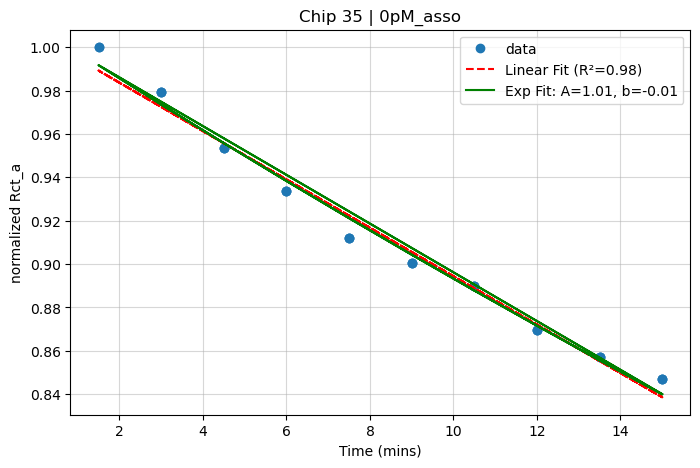

[0.93321993 0.91745248 0.89967904 0.89057724 0.87284152 0.86330518
 0.85385192 0.84316884 0.83397521 0.82224213 0.81243632 0.80158926
 0.79431362 0.78358079 0.77473698 0.76690163 0.76114331 0.75288872
 0.74267133 0.73529074 1.         0.93321993 0.91745248 0.89967904
 0.89057724 0.87284152 0.86330518 0.85385192 0.84316884 0.83397521
 0.82224213 0.81243632 0.80158926 0.79431362 0.78358079 0.77473698
 0.76690163 0.76114331 0.75288872 0.74267133 0.73529074 1.
 0.93321993 0.91745248 0.89967904 0.89057724 0.87284152 0.86330518
 0.85385192 0.84316884 0.83397521 0.82224213 0.81243632 0.80158926
 0.79431362 0.78358079 0.77473698 0.76690163 0.76114331 0.75288872
 0.74267133 0.73529074]  y
[0.93321993 0.91745248 0.89967904 0.89057724 0.87284152 0.86330518
 0.85385192 0.84316884 0.83397521 0.82224213 0.81243632 0.80158926
 0.79431362 0.78358079 0.77473698 0.76690163 0.76114331 0.75288872
 0.74267133 0.73529074 1.         0.93321993 0.91745248 0.89967904
 0.89057724 0.87284152 0.86330518 0.8538519

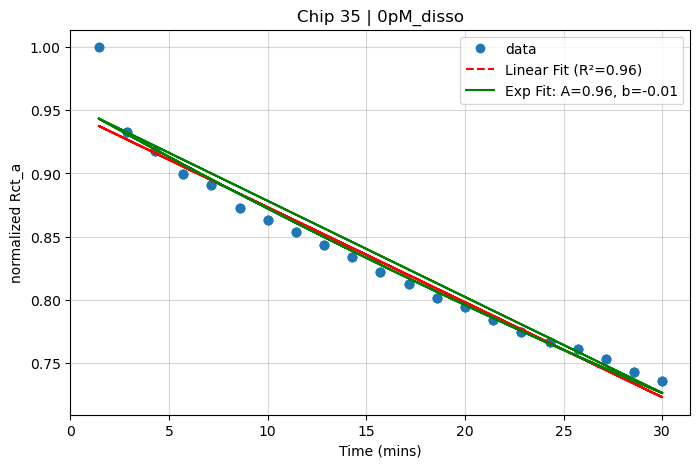

[0.82277633 0.78269935 0.76270366 0.75166333 0.72970198 0.71795116
 0.70373247 0.6880456  0.67644779 1.         0.82277633 0.78269935
 0.76270366 0.75166333 0.72970198 0.71795116 0.70373247 0.6880456
 0.67644779 1.         0.82277633 0.78269935 0.76270366 0.75166333
 0.72970198 0.71795116 0.70373247 0.6880456  0.67644779]  y
[0.82277633 0.78269935 0.76270366 0.75166333 0.72970198 0.71795116
 0.70373247 0.6880456  0.67644779 1.         0.82277633 0.78269935
 0.76270366 0.75166333 0.72970198 0.71795116 0.70373247 0.6880456
 0.67644779 1.         0.82277633 0.78269935 0.76270366 0.75166333
 0.72970198 0.71795116 0.70373247 0.6880456  0.67644779]  x


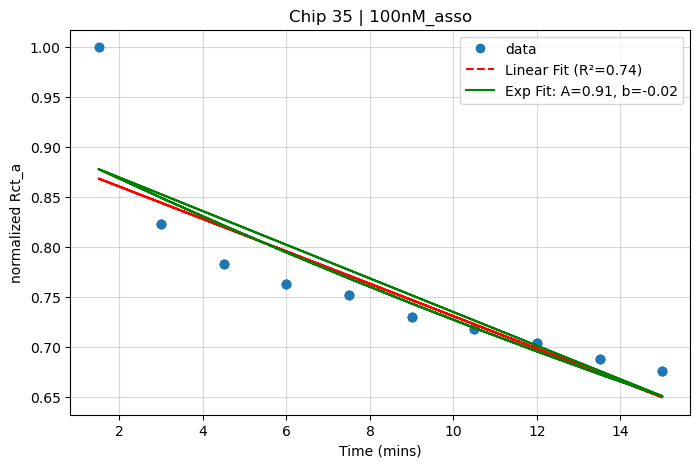

[0.92616021 0.9073865  0.89158227 0.87261813 0.86314954 0.85476198
 0.83930696 0.824108   0.81346169 0.80652255 0.79220306 0.78088176
 0.77675507 0.76372287 0.75776926 0.74550813 0.73630379 0.72974433
 0.71769473 0.71256551 1.         0.92616021 0.9073865  0.89158227
 0.87261813 0.86314954 0.85476198 0.83930696 0.824108   0.81346169
 0.80652255 0.79220306 0.78088176 0.77675507 0.76372287 0.75776926
 0.74550813 0.73630379 0.72974433 0.71769473 0.71256551 1.
 0.92616021 0.9073865  0.89158227 0.87261813 0.86314954 0.85476198
 0.83930696 0.824108   0.81346169 0.80652255 0.79220306 0.78088176
 0.77675507 0.76372287 0.75776926 0.74550813 0.73630379 0.72974433
 0.71769473 0.71256551]  y
[0.92616021 0.9073865  0.89158227 0.87261813 0.86314954 0.85476198
 0.83930696 0.824108   0.81346169 0.80652255 0.79220306 0.78088176
 0.77675507 0.76372287 0.75776926 0.74550813 0.73630379 0.72974433
 0.71769473 0.71256551 1.         0.92616021 0.9073865  0.89158227
 0.87261813 0.86314954 0.85476198 0.8393069

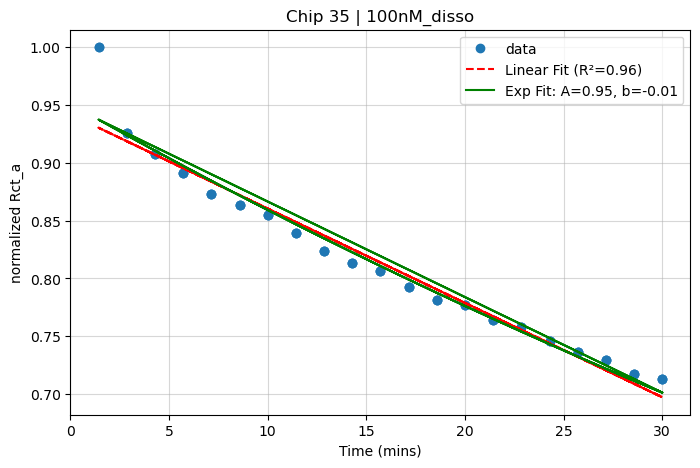

[0.85851004 0.81656673 0.80214723 0.78966087 0.77382436 0.76480474
 0.74970784 0.7415988  0.72633923 1.         0.85851004 0.81656673
 0.80214723 0.78966087 0.77382436 0.76480474 0.74970784 0.7415988
 0.72633923 1.         0.85851004 0.81656673 0.80214723 0.78966087
 0.77382436 0.76480474 0.74970784 0.7415988  0.72633923]  y
[0.85851004 0.81656673 0.80214723 0.78966087 0.77382436 0.76480474
 0.74970784 0.7415988  0.72633923 1.         0.85851004 0.81656673
 0.80214723 0.78966087 0.77382436 0.76480474 0.74970784 0.7415988
 0.72633923 1.         0.85851004 0.81656673 0.80214723 0.78966087
 0.77382436 0.76480474 0.74970784 0.7415988  0.72633923]  x


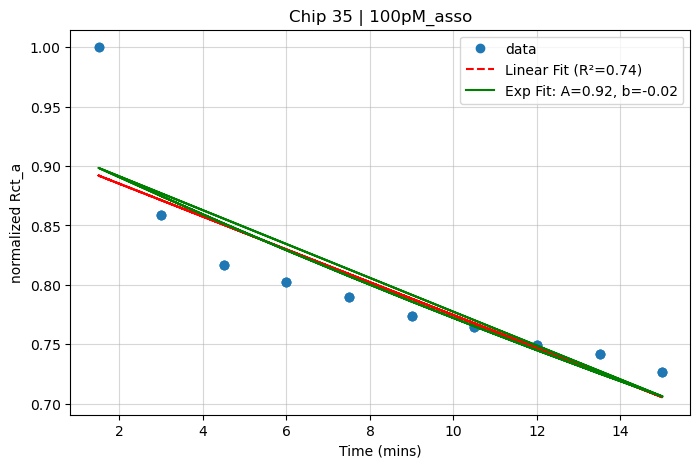

[0.93068888 0.90912039 0.89088425 0.88066914 0.8691412  0.85311608
 0.83753893 0.82924222 0.81540553 0.80239755 0.79823423 0.78316323
 0.77841976 0.76353461 0.75488089 0.75179766 0.73727744 0.73060821
 0.72369778 0.71268785 1.         0.93068888 0.90912039 0.89088425
 0.88066914 0.8691412  0.85311608 0.83753893 0.82924222 0.81540553
 0.80239755 0.79823423 0.78316323 0.77841976 0.76353461 0.75488089
 0.75179766 0.73727744 0.73060821 0.72369778 0.71268785 1.
 0.93068888 0.90912039 0.89088425 0.88066914 0.8691412  0.85311608
 0.83753893 0.82924222 0.81540553 0.80239755 0.79823423 0.78316323
 0.77841976 0.76353461 0.75488089 0.75179766 0.73727744 0.73060821
 0.72369778 0.71268785]  y
[0.93068888 0.90912039 0.89088425 0.88066914 0.8691412  0.85311608
 0.83753893 0.82924222 0.81540553 0.80239755 0.79823423 0.78316323
 0.77841976 0.76353461 0.75488089 0.75179766 0.73727744 0.73060821
 0.72369778 0.71268785 1.         0.93068888 0.90912039 0.89088425
 0.88066914 0.8691412  0.85311608 0.8375389

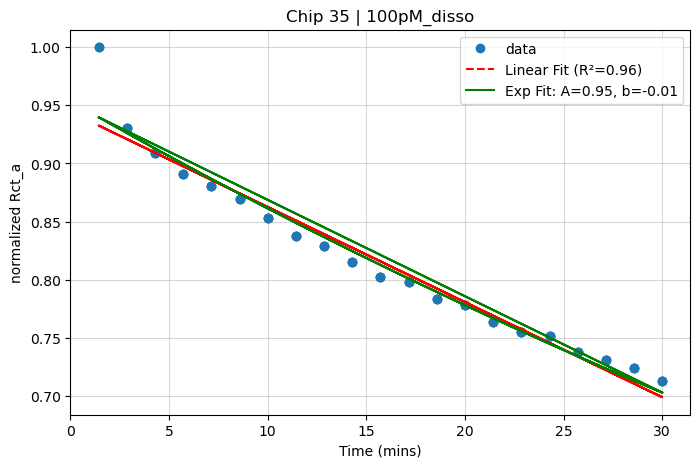

[0.8458755  0.81109771 0.79528299 0.77660208 0.76101532 0.74434651
 0.73190963 0.72025286 0.71114923 1.         0.8458755  0.81109771
 0.79528299 0.77660208 0.76101532 0.74434651 0.73190963 0.72025286
 0.71114923 1.         0.8458755  0.81109771 0.79528299 0.77660208
 0.76101532 0.74434651 0.73190963 0.72025286 0.71114923]  y
[0.8458755  0.81109771 0.79528299 0.77660208 0.76101532 0.74434651
 0.73190963 0.72025286 0.71114923 1.         0.8458755  0.81109771
 0.79528299 0.77660208 0.76101532 0.74434651 0.73190963 0.72025286
 0.71114923 1.         0.8458755  0.81109771 0.79528299 0.77660208
 0.76101532 0.74434651 0.73190963 0.72025286 0.71114923]  x


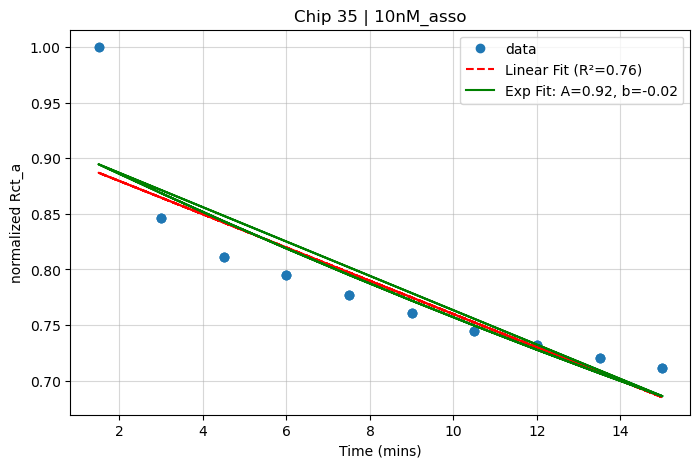

[0.92408366 0.90508803 0.88970182 0.87500007 0.86611571 0.85611795
 0.84482826 0.8348288  0.82160264 0.81684903 0.80420809 0.78858745
 0.78587583 0.77975728 0.77047022 0.75801181 0.75410636 0.74065548
 0.73671182 0.72518029 1.         0.92408366 0.90508803 0.88970182
 0.87500007 0.86611571 0.85611795 0.84482826 0.8348288  0.82160264
 0.81684903 0.80420809 0.78858745 0.78587583 0.77975728 0.77047022
 0.75801181 0.75410636 0.74065548 0.73671182 0.72518029 1.
 0.92408366 0.90508803 0.88970182 0.87500007 0.86611571 0.85611795
 0.84482826 0.8348288  0.82160264 0.81684903 0.80420809 0.78858745
 0.78587583 0.77975728 0.77047022 0.75801181 0.75410636 0.74065548
 0.73671182 0.72518029]  y
[0.92408366 0.90508803 0.88970182 0.87500007 0.86611571 0.85611795
 0.84482826 0.8348288  0.82160264 0.81684903 0.80420809 0.78858745
 0.78587583 0.77975728 0.77047022 0.75801181 0.75410636 0.74065548
 0.73671182 0.72518029 1.         0.92408366 0.90508803 0.88970182
 0.87500007 0.86611571 0.85611795 0.8448282

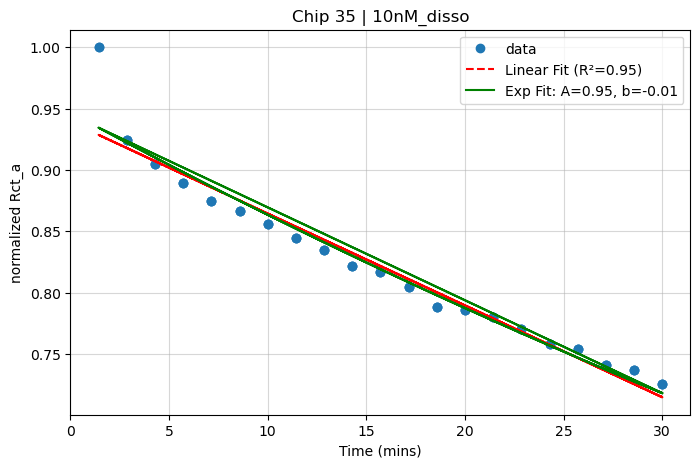

[0.85581327 0.81682357 0.80185596 0.78671228 0.77014813 0.75828903
 0.74421767 0.73234614 0.72342694 1.         0.85581327 0.81682357
 0.80185596 0.78671228 0.77014813 0.75828903 0.74421767 0.73234614
 0.72342694 1.         0.85581327 0.81682357 0.80185596 0.78671228
 0.77014813 0.75828903 0.74421767 0.73234614 0.72342694]  y
[0.85581327 0.81682357 0.80185596 0.78671228 0.77014813 0.75828903
 0.74421767 0.73234614 0.72342694 1.         0.85581327 0.81682357
 0.80185596 0.78671228 0.77014813 0.75828903 0.74421767 0.73234614
 0.72342694 1.         0.85581327 0.81682357 0.80185596 0.78671228
 0.77014813 0.75828903 0.74421767 0.73234614 0.72342694]  x


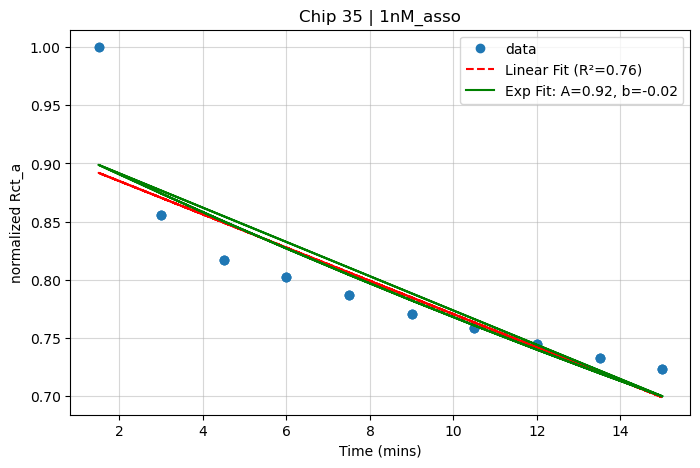

[0.93079395 0.91350156 0.89845637 0.88784972 0.86719793 0.85609646
 0.84155806 0.82959123 0.81612455 0.80620483 0.79531998 0.78187725
 0.77160295 0.76575464 0.75338306 0.747846   0.73831336 0.7297903
 0.71763933 0.70894183 1.         0.93079395 0.91350156 0.89845637
 0.88784972 0.86719793 0.85609646 0.84155806 0.82959123 0.81612455
 0.80620483 0.79531998 0.78187725 0.77160295 0.76575464 0.75338306
 0.747846   0.73831336 0.7297903  0.71763933 0.70894183 1.
 0.93079395 0.91350156 0.89845637 0.88784972 0.86719793 0.85609646
 0.84155806 0.82959123 0.81612455 0.80620483 0.79531998 0.78187725
 0.77160295 0.76575464 0.75338306 0.747846   0.73831336 0.7297903
 0.71763933 0.70894183]  y
[0.93079395 0.91350156 0.89845637 0.88784972 0.86719793 0.85609646
 0.84155806 0.82959123 0.81612455 0.80620483 0.79531998 0.78187725
 0.77160295 0.76575464 0.75338306 0.747846   0.73831336 0.7297903
 0.71763933 0.70894183 1.         0.93079395 0.91350156 0.89845637
 0.88784972 0.86719793 0.85609646 0.84155806 0

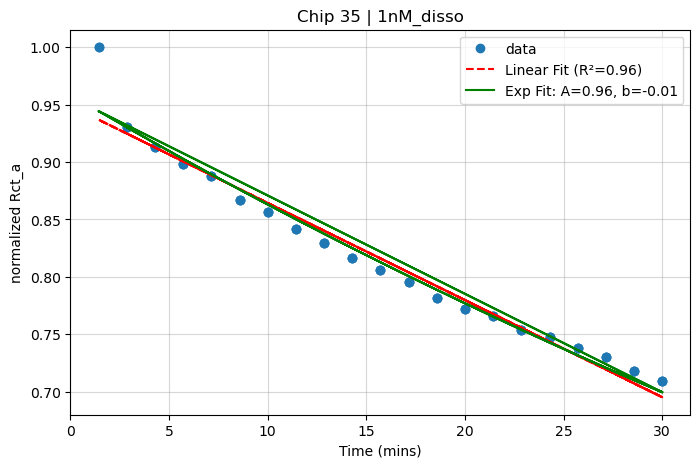

[0.96553262 0.93351893 0.911046   0.89591098 0.87523188 0.85763049
 0.84685654 0.83526176 0.82372265 1.         0.96553262 0.93351893
 0.911046   0.89591098 0.87523188 0.85763049 0.84685654 0.83526176
 0.82372265]  y
[0.96553262 0.93351893 0.911046   0.89591098 0.87523188 0.85763049
 0.84685654 0.83526176 0.82372265 1.         0.96553262 0.93351893
 0.911046   0.89591098 0.87523188 0.85763049 0.84685654 0.83526176
 0.82372265]  x


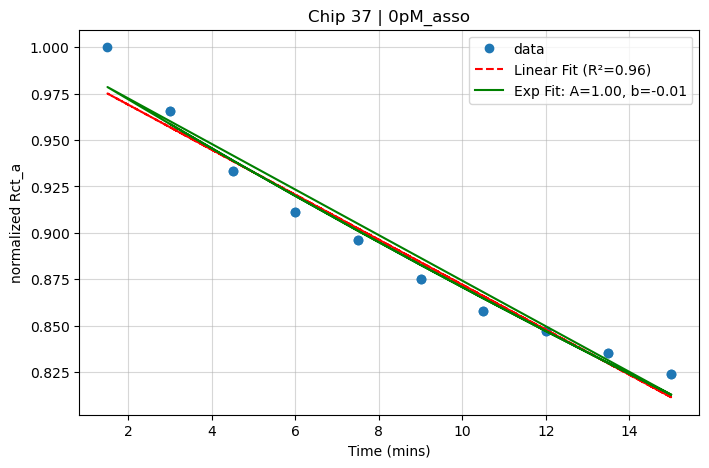

[0.97017818 0.95536747 0.9375057  0.92573946 0.91633606 0.90116474
 0.89187655 0.88192234 0.86850366 0.86209673 0.85347515 0.84239892
 0.83444516 0.82536277 0.81510735 0.80688238 0.79862081 0.79549775
 0.79158747 0.77750577 1.         0.97017818 0.95536747 0.9375057
 0.92573946 0.91633606 0.90116474 0.89187655 0.88192234 0.86850366
 0.86209673 0.85347515 0.84239892 0.83444516 0.82536277 0.81510735
 0.80688238 0.79862081 0.79549775 0.79158747 0.77750577]  y
[0.97017818 0.95536747 0.9375057  0.92573946 0.91633606 0.90116474
 0.89187655 0.88192234 0.86850366 0.86209673 0.85347515 0.84239892
 0.83444516 0.82536277 0.81510735 0.80688238 0.79862081 0.79549775
 0.79158747 0.77750577 1.         0.97017818 0.95536747 0.9375057
 0.92573946 0.91633606 0.90116474 0.89187655 0.88192234 0.86850366
 0.86209673 0.85347515 0.84239892 0.83444516 0.82536277 0.81510735
 0.80688238 0.79862081 0.79549775 0.79158747 0.77750577]  x


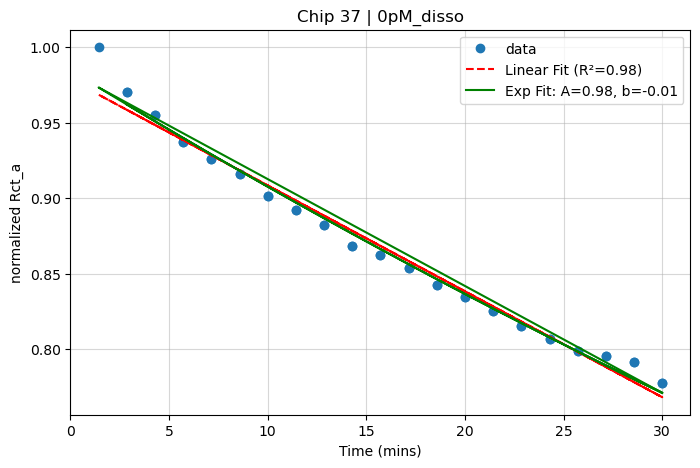

[0.86488635 0.8341286  0.81452956 0.79805879 0.77889313 0.75933369
 0.74922581 0.72596024 0.72022873 1.         0.86488635 0.8341286
 0.81452956 0.79805879 0.77889313 0.75933369 0.74922581 0.72596024
 0.72022873]  y
[0.86488635 0.8341286  0.81452956 0.79805879 0.77889313 0.75933369
 0.74922581 0.72596024 0.72022873 1.         0.86488635 0.8341286
 0.81452956 0.79805879 0.77889313 0.75933369 0.74922581 0.72596024
 0.72022873]  x


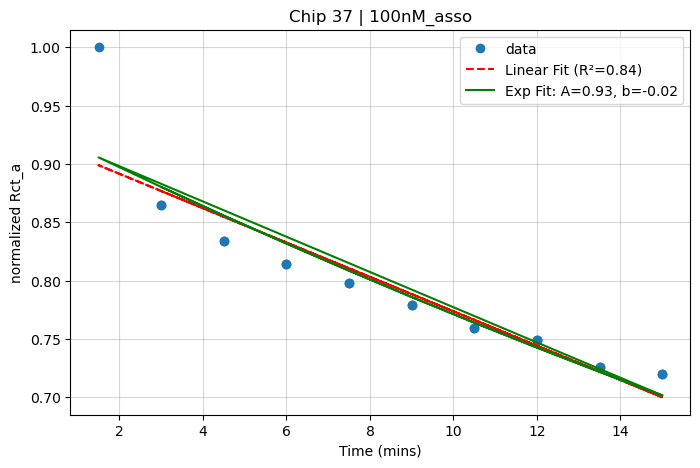

[0.93229972 0.9076678  0.89395925 0.8766363  0.8684964  0.86120301
 0.84737913 0.84071658 0.82532596 0.82012752 0.81131698 0.80023965
 0.794513   0.78625316 0.77855439 0.76913664 0.76027536 0.7551686
 0.74980236 0.73766977 1.         0.93229972 0.9076678  0.89395925
 0.8766363  0.8684964  0.86120301 0.84737913 0.84071658 0.82532596
 0.82012752 0.81131698 0.80023965 0.794513   0.78625316 0.77855439
 0.76913664 0.76027536 0.7551686  0.74980236 0.73766977]  y
[0.93229972 0.9076678  0.89395925 0.8766363  0.8684964  0.86120301
 0.84737913 0.84071658 0.82532596 0.82012752 0.81131698 0.80023965
 0.794513   0.78625316 0.77855439 0.76913664 0.76027536 0.7551686
 0.74980236 0.73766977 1.         0.93229972 0.9076678  0.89395925
 0.8766363  0.8684964  0.86120301 0.84737913 0.84071658 0.82532596
 0.82012752 0.81131698 0.80023965 0.794513   0.78625316 0.77855439
 0.76913664 0.76027536 0.7551686  0.74980236 0.73766977]  x


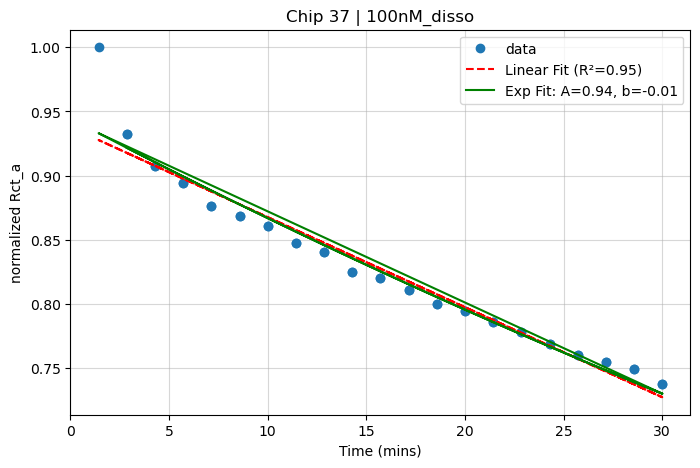

[0.84001434 0.80758029 0.78123983 0.76730175 0.7611358  0.74629106
 0.7328756  0.72340698 0.71328757 1.         0.84001434 0.80758029
 0.78123983 0.76730175 0.7611358  0.74629106 0.7328756  0.72340698
 0.71328757]  y
[0.84001434 0.80758029 0.78123983 0.76730175 0.7611358  0.74629106
 0.7328756  0.72340698 0.71328757 1.         0.84001434 0.80758029
 0.78123983 0.76730175 0.7611358  0.74629106 0.7328756  0.72340698
 0.71328757]  x


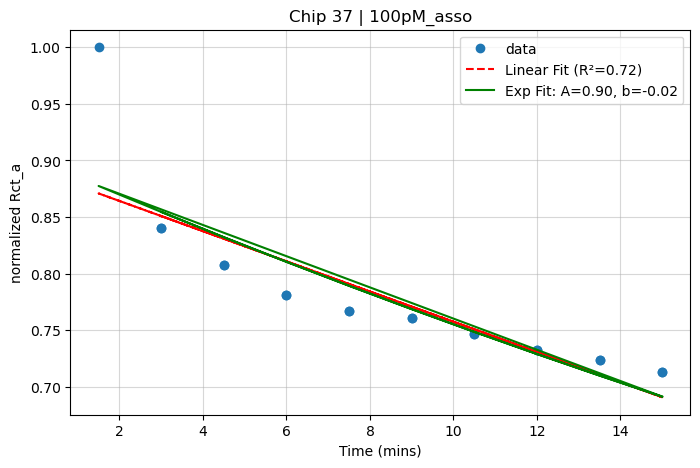

[0.9368287  0.92069744 0.90178337 0.88618516 0.86943011 0.85877257
 0.84532425 0.83377925 0.82752821 0.8120898  0.79993528 0.79121818
 0.78417613 0.76945339 0.76241305 0.75288439 0.74709449 0.73944234
 0.72727413 0.7178442  1.         0.9368287  0.92069744 0.90178337
 0.88618516 0.86943011 0.85877257 0.84532425 0.83377925 0.82752821
 0.8120898  0.79993528 0.79121818 0.78417613 0.76945339 0.76241305
 0.75288439 0.74709449 0.73944234 0.72727413 0.7178442 ]  y
[0.9368287  0.92069744 0.90178337 0.88618516 0.86943011 0.85877257
 0.84532425 0.83377925 0.82752821 0.8120898  0.79993528 0.79121818
 0.78417613 0.76945339 0.76241305 0.75288439 0.74709449 0.73944234
 0.72727413 0.7178442  1.         0.9368287  0.92069744 0.90178337
 0.88618516 0.86943011 0.85877257 0.84532425 0.83377925 0.82752821
 0.8120898  0.79993528 0.79121818 0.78417613 0.76945339 0.76241305
 0.75288439 0.74709449 0.73944234 0.72727413 0.7178442 ]  x


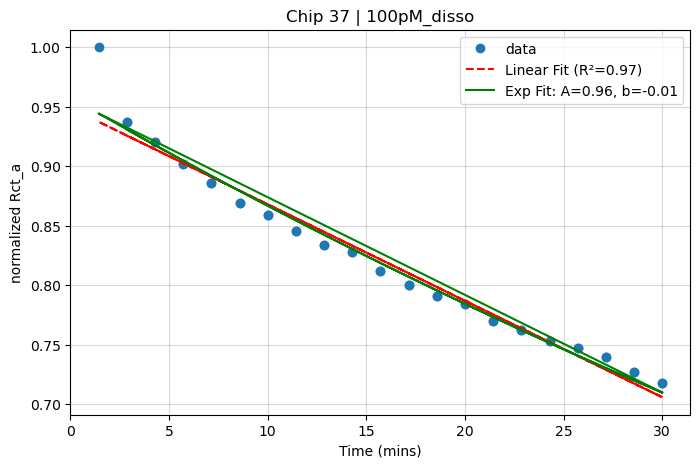

[0.84447301 0.80983293 0.7909382  0.77546402 0.76522008 0.74601825
 0.74109106 0.72399135 0.71597601 1.         0.84447301 0.80983293
 0.7909382  0.77546402 0.76522008 0.74601825 0.74109106 0.72399135
 0.71597601]  y
[0.84447301 0.80983293 0.7909382  0.77546402 0.76522008 0.74601825
 0.74109106 0.72399135 0.71597601 1.         0.84447301 0.80983293
 0.7909382  0.77546402 0.76522008 0.74601825 0.74109106 0.72399135
 0.71597601]  x


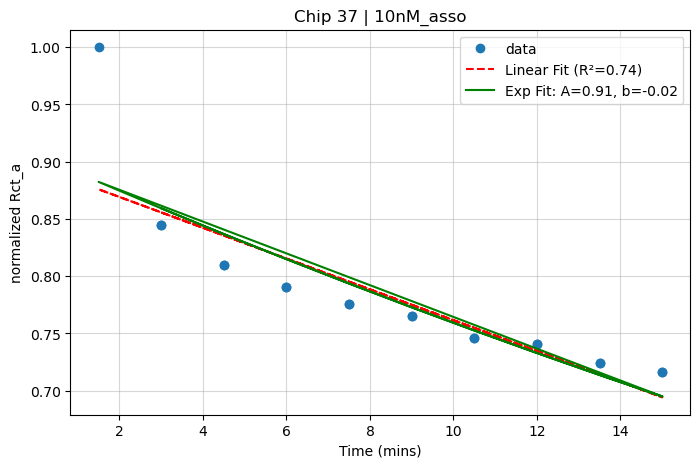

[0.93850264 0.9122262  0.8969794  0.88471565 0.87339609 0.8612325
 0.85219254 0.83935948 0.83388654 0.82793976 0.81618735 0.80813491
 0.79705138 0.79451874 0.78477827 0.77735372 0.77176539 0.76270552
 0.75106732 0.74475681 1.         0.93850264 0.9122262  0.8969794
 0.88471565 0.87339609 0.8612325  0.85219254 0.83935948 0.83388654
 0.82793976 0.81618735 0.80813491 0.79705138 0.79451874 0.78477827
 0.77735372 0.77176539 0.76270552 0.75106732 0.74475681]  y
[0.93850264 0.9122262  0.8969794  0.88471565 0.87339609 0.8612325
 0.85219254 0.83935948 0.83388654 0.82793976 0.81618735 0.80813491
 0.79705138 0.79451874 0.78477827 0.77735372 0.77176539 0.76270552
 0.75106732 0.74475681 1.         0.93850264 0.9122262  0.8969794
 0.88471565 0.87339609 0.8612325  0.85219254 0.83935948 0.83388654
 0.82793976 0.81618735 0.80813491 0.79705138 0.79451874 0.78477827
 0.77735372 0.77176539 0.76270552 0.75106732 0.74475681]  x


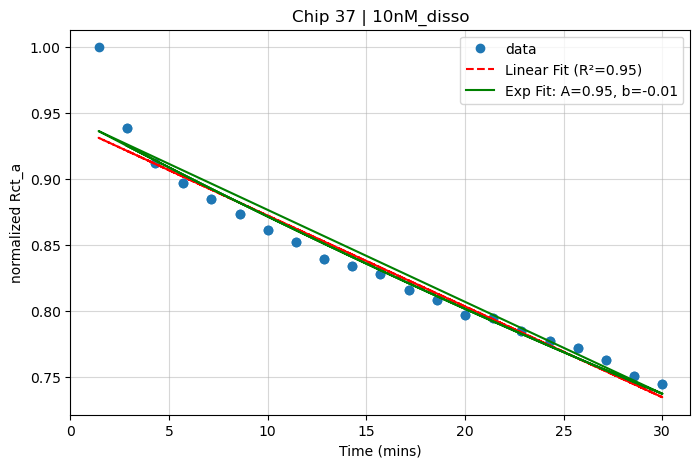

[0.83947772 0.79496288 0.77725397 0.76172211 0.75090747 0.74023904
 0.72627329 0.71455965 0.70425188 1.         0.83947772 0.79496288
 0.77725397 0.76172211 0.75090747 0.74023904 0.72627329 0.71455965
 0.70425188]  y
[0.83947772 0.79496288 0.77725397 0.76172211 0.75090747 0.74023904
 0.72627329 0.71455965 0.70425188 1.         0.83947772 0.79496288
 0.77725397 0.76172211 0.75090747 0.74023904 0.72627329 0.71455965
 0.70425188]  x


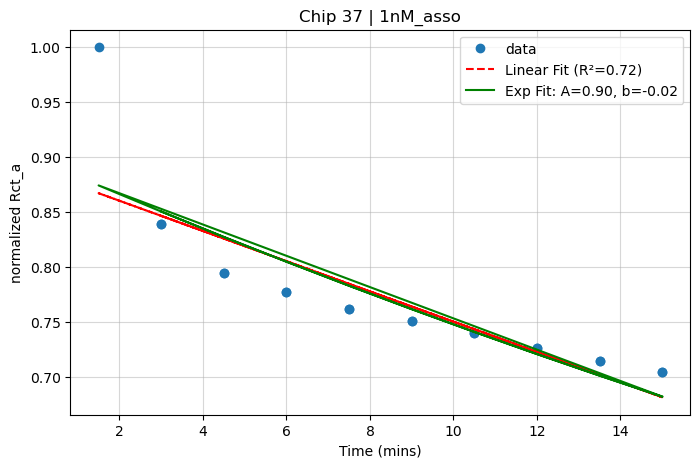

[0.94096711 0.91363248 0.90362143 0.88581043 0.8824709  0.87201126
 0.8576273  0.84836681 0.83945522 0.83025384 0.8185058  0.8157957
 0.80614167 0.79397981 0.78970021 0.77987231 0.77194484 0.76278809
 0.75460909 0.74753071 1.         0.94096711 0.91363248 0.90362143
 0.88581043 0.8824709  0.87201126 0.8576273  0.84836681 0.83945522
 0.83025384 0.8185058  0.8157957  0.80614167 0.79397981 0.78970021
 0.77987231 0.77194484 0.76278809 0.75460909 0.74753071]  y
[0.94096711 0.91363248 0.90362143 0.88581043 0.8824709  0.87201126
 0.8576273  0.84836681 0.83945522 0.83025384 0.8185058  0.8157957
 0.80614167 0.79397981 0.78970021 0.77987231 0.77194484 0.76278809
 0.75460909 0.74753071 1.         0.94096711 0.91363248 0.90362143
 0.88581043 0.8824709  0.87201126 0.8576273  0.84836681 0.83945522
 0.83025384 0.8185058  0.8157957  0.80614167 0.79397981 0.78970021
 0.77987231 0.77194484 0.76278809 0.75460909 0.74753071]  x


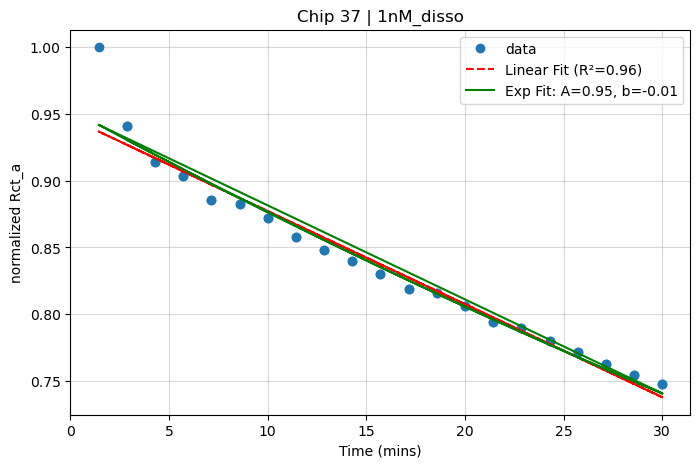

[0.97658284 0.95661165 0.93865324 0.91781028 0.90073184 0.88088208
 0.86869568 0.85542692 0.83920674 1.         0.97658284 0.95661165
 0.93865324 0.91781028 0.90073184 0.88088208 0.86869568 0.85542692
 0.83920674]  y
[0.97658284 0.95661165 0.93865324 0.91781028 0.90073184 0.88088208
 0.86869568 0.85542692 0.83920674 1.         0.97658284 0.95661165
 0.93865324 0.91781028 0.90073184 0.88088208 0.86869568 0.85542692
 0.83920674]  x


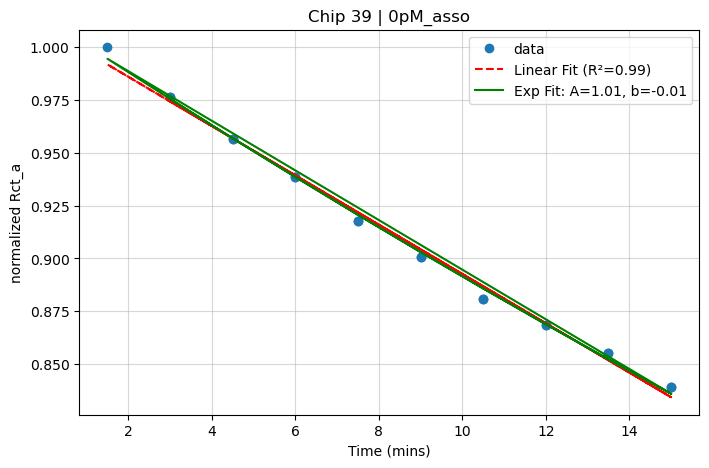

[0.94381491 0.93501026 0.91960786 0.91384448 0.89896235 0.8854468
 0.87340848 0.86157037 0.84648941 0.8363012  0.82829005 0.81893987
 0.80894268 0.79996813 0.79072633 0.77952558 0.77009413 0.76094416
 0.74986603 0.73994002 1.         0.94381491 0.93501026 0.91960786
 0.91384448 0.89896235 0.8854468  0.87340848 0.86157037 0.84648941
 0.8363012  0.82829005 0.81893987 0.80894268 0.79996813 0.79072633
 0.77952558 0.77009413 0.76094416 0.74986603 0.73994002]  y
[0.94381491 0.93501026 0.91960786 0.91384448 0.89896235 0.8854468
 0.87340848 0.86157037 0.84648941 0.8363012  0.82829005 0.81893987
 0.80894268 0.79996813 0.79072633 0.77952558 0.77009413 0.76094416
 0.74986603 0.73994002 1.         0.94381491 0.93501026 0.91960786
 0.91384448 0.89896235 0.8854468  0.87340848 0.86157037 0.84648941
 0.8363012  0.82829005 0.81893987 0.80894268 0.79996813 0.79072633
 0.77952558 0.77009413 0.76094416 0.74986603 0.73994002]  x


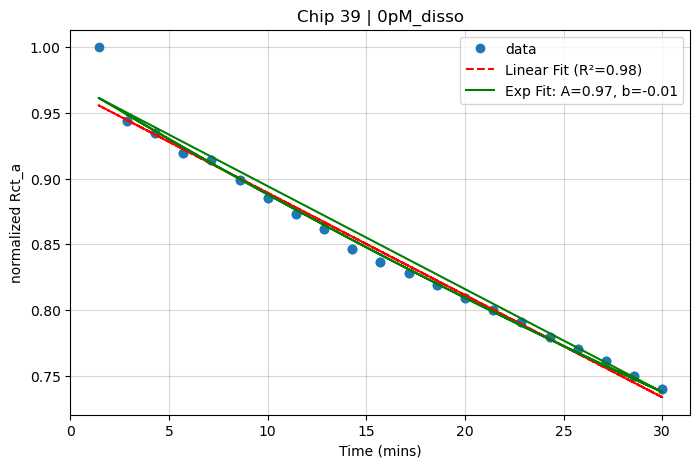

[0.83863006 0.80397932 0.78252478 0.77158719 0.74718042 0.72705049
 0.71567562 0.70099691 0.68400461 1.         0.83863006 0.80397932
 0.78252478 0.77158719 0.74718042 0.72705049 0.71567562 0.70099691
 0.68400461]  y
[0.83863006 0.80397932 0.78252478 0.77158719 0.74718042 0.72705049
 0.71567562 0.70099691 0.68400461 1.         0.83863006 0.80397932
 0.78252478 0.77158719 0.74718042 0.72705049 0.71567562 0.70099691
 0.68400461]  x


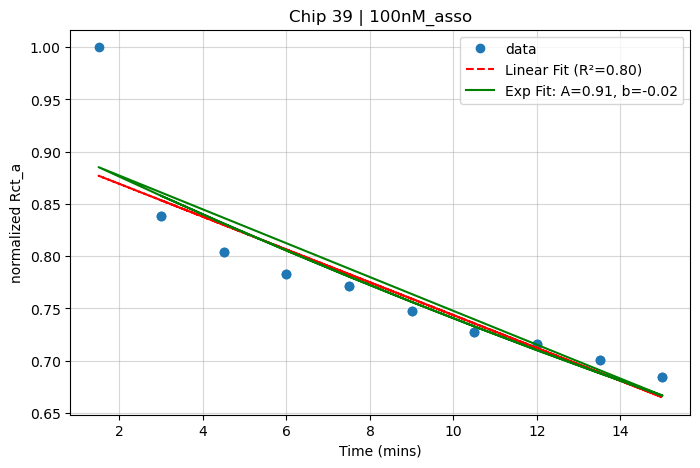

[0.93747006 0.91629567 0.89832853 0.88097277 0.87642749 0.86307762
 0.8443055  0.83708897 0.82441713 0.81303566 0.80656185 0.79581707
 0.7856506  0.77622101 0.76435073 0.75347268 0.74382568 0.73390776
 0.72660027 0.71031798 1.         0.93747006 0.91629567 0.89832853
 0.88097277 0.87642749 0.86307762 0.8443055  0.83708897 0.82441713
 0.81303566 0.80656185 0.79581707 0.7856506  0.77622101 0.76435073
 0.75347268 0.74382568 0.73390776 0.72660027 0.71031798]  y
[0.93747006 0.91629567 0.89832853 0.88097277 0.87642749 0.86307762
 0.8443055  0.83708897 0.82441713 0.81303566 0.80656185 0.79581707
 0.7856506  0.77622101 0.76435073 0.75347268 0.74382568 0.73390776
 0.72660027 0.71031798 1.         0.93747006 0.91629567 0.89832853
 0.88097277 0.87642749 0.86307762 0.8443055  0.83708897 0.82441713
 0.81303566 0.80656185 0.79581707 0.7856506  0.77622101 0.76435073
 0.75347268 0.74382568 0.73390776 0.72660027 0.71031798]  x


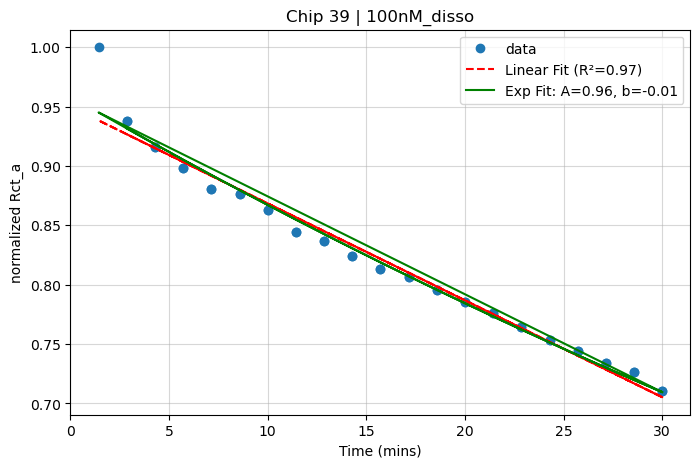

[0.87082782 0.83292069 0.81916909 0.79894975 0.78185003 0.76999315
 0.75306088 0.74215013 0.73269822 1.         0.87082782 0.83292069
 0.81916909 0.79894975 0.78185003 0.76999315 0.75306088 0.74215013
 0.73269822]  y
[0.87082782 0.83292069 0.81916909 0.79894975 0.78185003 0.76999315
 0.75306088 0.74215013 0.73269822 1.         0.87082782 0.83292069
 0.81916909 0.79894975 0.78185003 0.76999315 0.75306088 0.74215013
 0.73269822]  x


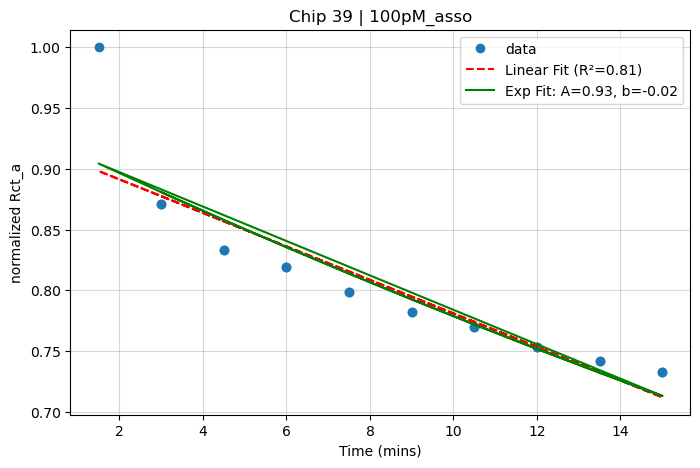

[0.9439717  0.93054531 0.91293895 0.90354776 0.88824616 0.87999504
 0.86760276 0.85633021 0.84227559 0.83472602 0.81713481 0.80539582
 0.79571228 0.79011598 0.77776532 0.76681918 0.75719572 0.74737688
 0.73803016 0.73015418 1.         0.9439717  0.93054531 0.91293895
 0.90354776 0.88824616 0.87999504 0.86760276 0.85633021 0.84227559
 0.83472602 0.81713481 0.80539582 0.79571228 0.79011598 0.77776532
 0.76681918 0.75719572 0.74737688 0.73803016 0.73015418]  y
[0.9439717  0.93054531 0.91293895 0.90354776 0.88824616 0.87999504
 0.86760276 0.85633021 0.84227559 0.83472602 0.81713481 0.80539582
 0.79571228 0.79011598 0.77776532 0.76681918 0.75719572 0.74737688
 0.73803016 0.73015418 1.         0.9439717  0.93054531 0.91293895
 0.90354776 0.88824616 0.87999504 0.86760276 0.85633021 0.84227559
 0.83472602 0.81713481 0.80539582 0.79571228 0.79011598 0.77776532
 0.76681918 0.75719572 0.74737688 0.73803016 0.73015418]  x


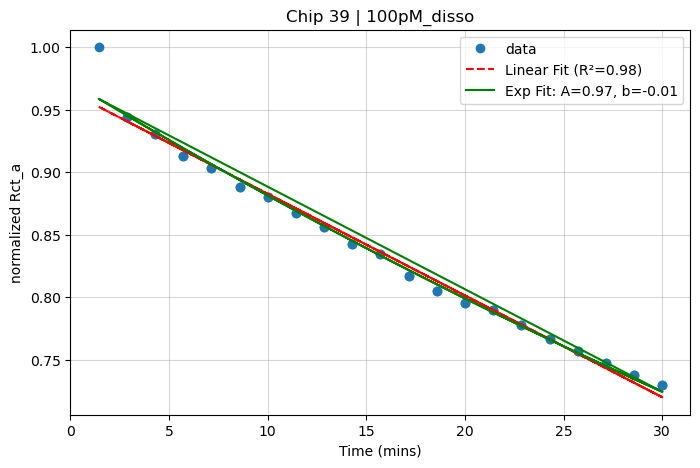

[0.84421314 0.8014762  0.78393318 0.77435119 0.7607021  0.74605125
 0.73366788 0.71690484 0.70212896 1.         0.84421314 0.8014762
 0.78393318 0.77435119 0.7607021  0.74605125 0.73366788 0.71690484
 0.70212896]  y
[0.84421314 0.8014762  0.78393318 0.77435119 0.7607021  0.74605125
 0.73366788 0.71690484 0.70212896 1.         0.84421314 0.8014762
 0.78393318 0.77435119 0.7607021  0.74605125 0.73366788 0.71690484
 0.70212896]  x


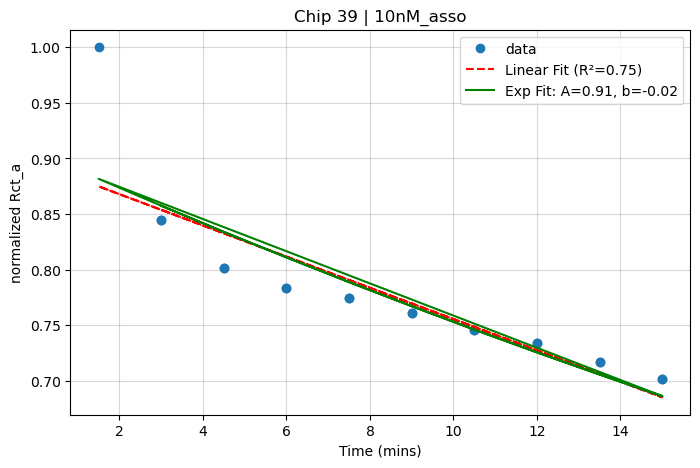

[0.94647348 0.92801502 0.9132907  0.89843127 0.88542885 0.8740688
 0.86591971 0.85456302 0.84198604 0.82672081 0.81539718 0.79866301
 0.79675665 0.78561939 0.76737892 0.76180358 0.75009522 0.73895604
 0.72446265 0.71862907 1.         0.94647348 0.92801502 0.9132907
 0.89843127 0.88542885 0.8740688  0.86591971 0.85456302 0.84198604
 0.82672081 0.81539718 0.79866301 0.79675665 0.78561939 0.76737892
 0.76180358 0.75009522 0.73895604 0.72446265 0.71862907]  y
[0.94647348 0.92801502 0.9132907  0.89843127 0.88542885 0.8740688
 0.86591971 0.85456302 0.84198604 0.82672081 0.81539718 0.79866301
 0.79675665 0.78561939 0.76737892 0.76180358 0.75009522 0.73895604
 0.72446265 0.71862907 1.         0.94647348 0.92801502 0.9132907
 0.89843127 0.88542885 0.8740688  0.86591971 0.85456302 0.84198604
 0.82672081 0.81539718 0.79866301 0.79675665 0.78561939 0.76737892
 0.76180358 0.75009522 0.73895604 0.72446265 0.71862907]  x


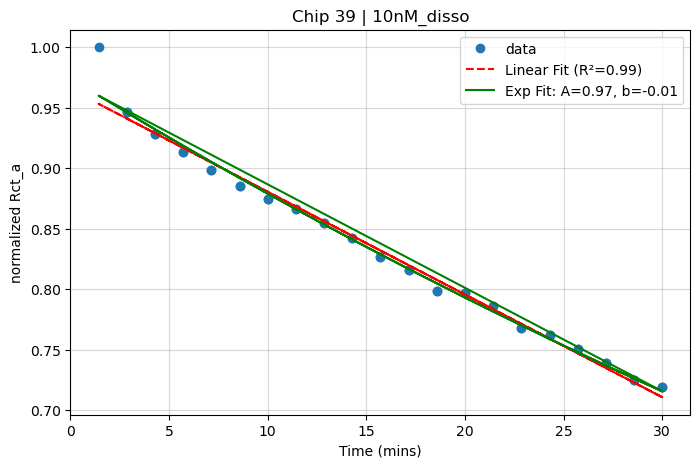

[0.81155371 0.76858372 0.74761218 0.73482332 0.71966883 0.70743321
 0.69590673 0.68443773 0.67139134 1.         0.81155371 0.76858372
 0.74761218 0.73482332 0.71966883 0.70743321 0.69590673 0.68443773
 0.67139134]  y
[0.81155371 0.76858372 0.74761218 0.73482332 0.71966883 0.70743321
 0.69590673 0.68443773 0.67139134 1.         0.81155371 0.76858372
 0.74761218 0.73482332 0.71966883 0.70743321 0.69590673 0.68443773
 0.67139134]  x


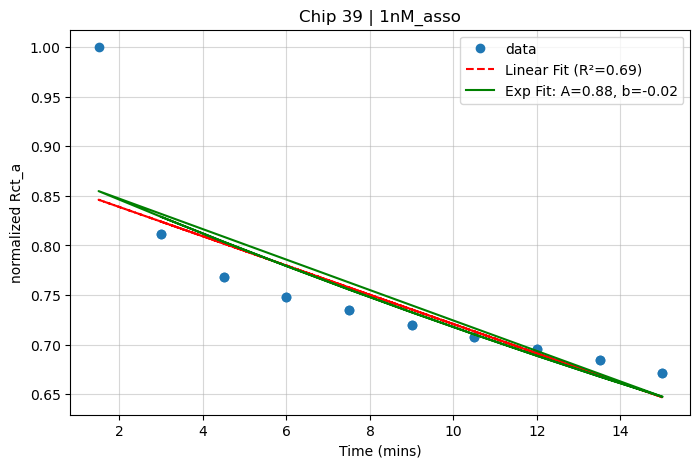

[0.94583756 0.92526902 0.90860178 0.89876301 0.88104711 0.86896483
 0.8548268  0.84514616 0.83557493 0.82193137 0.8120797  0.7985422
 0.79540673 0.78978983 0.77192774 0.76538114 0.75467048 0.74942766
 0.7399515  0.72766904 1.         0.94583756 0.92526902 0.90860178
 0.89876301 0.88104711 0.86896483 0.8548268  0.84514616 0.83557493
 0.82193137 0.8120797  0.7985422  0.79540673 0.78978983 0.77192774
 0.76538114 0.75467048 0.74942766 0.7399515  0.72766904]  y
[0.94583756 0.92526902 0.90860178 0.89876301 0.88104711 0.86896483
 0.8548268  0.84514616 0.83557493 0.82193137 0.8120797  0.7985422
 0.79540673 0.78978983 0.77192774 0.76538114 0.75467048 0.74942766
 0.7399515  0.72766904 1.         0.94583756 0.92526902 0.90860178
 0.89876301 0.88104711 0.86896483 0.8548268  0.84514616 0.83557493
 0.82193137 0.8120797  0.7985422  0.79540673 0.78978983 0.77192774
 0.76538114 0.75467048 0.74942766 0.7399515  0.72766904]  x


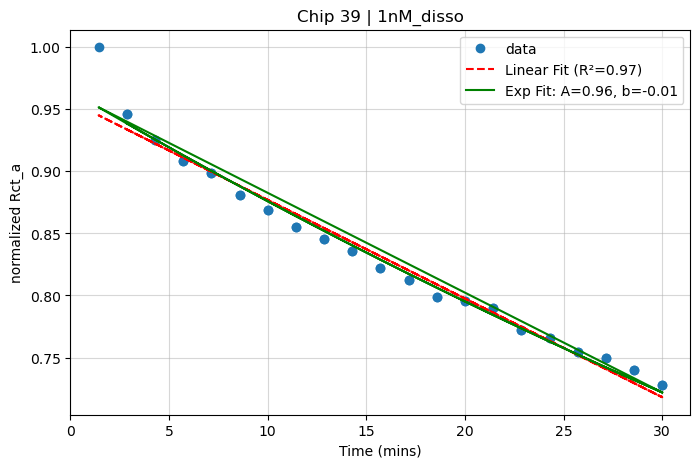

[0.95533478 0.92076529 0.90037684 0.87650731 0.86071411 0.84642772
 0.82951901 0.82199955 0.81124691 1.         0.95533478 0.92076529
 0.90037684 0.87650731 0.86071411 0.84642772 0.82951901 0.82199955
 0.81124691]  y
[0.95533478 0.92076529 0.90037684 0.87650731 0.86071411 0.84642772
 0.82951901 0.82199955 0.81124691 1.         0.95533478 0.92076529
 0.90037684 0.87650731 0.86071411 0.84642772 0.82951901 0.82199955
 0.81124691]  x


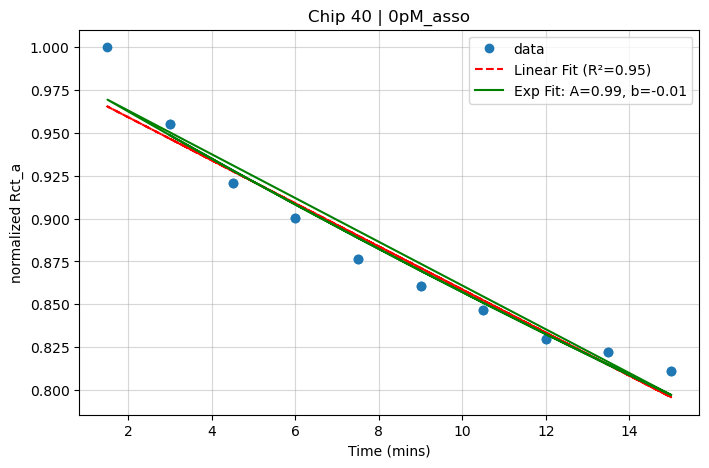

[0.99192515 0.97739469 0.96239161 0.95641011 0.93634599 0.9257736
 0.9133355  0.90228503 0.89261128 0.88089973 0.86789477 0.86453529
 0.85194544 0.84415129 0.83569656 0.82559977 0.81501797 0.81065223
 0.80461965 0.79931858 1.         0.99192515 0.97739469 0.96239161
 0.95641011 0.93634599 0.9257736  0.9133355  0.90228503 0.89261128
 0.88089973 0.86789477 0.86453529 0.85194544 0.84415129 0.83569656
 0.82559977 0.81501797 0.81065223 0.80461965 0.79931858]  y
[0.99192515 0.97739469 0.96239161 0.95641011 0.93634599 0.9257736
 0.9133355  0.90228503 0.89261128 0.88089973 0.86789477 0.86453529
 0.85194544 0.84415129 0.83569656 0.82559977 0.81501797 0.81065223
 0.80461965 0.79931858 1.         0.99192515 0.97739469 0.96239161
 0.95641011 0.93634599 0.9257736  0.9133355  0.90228503 0.89261128
 0.88089973 0.86789477 0.86453529 0.85194544 0.84415129 0.83569656
 0.82559977 0.81501797 0.81065223 0.80461965 0.79931858]  x


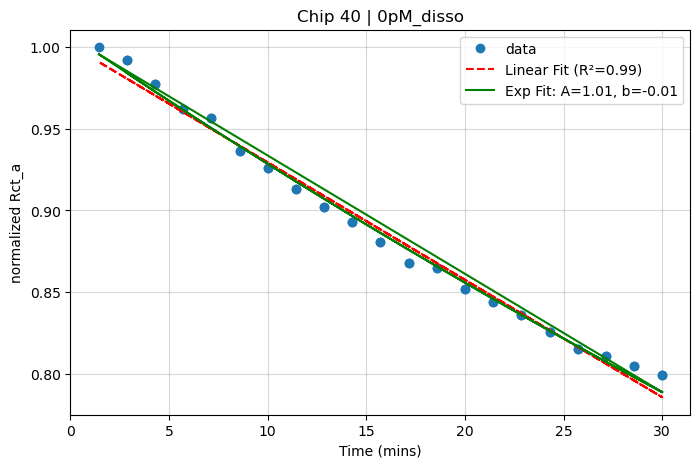

[0.82643438 0.78359759 0.75925681 0.74538851 0.73196539 0.7176549
 0.70685027 0.69332899 0.67747625 1.         0.82643438 0.78359759
 0.75925681 0.74538851 0.73196539 0.7176549  0.70685027 0.69332899
 0.67747625]  y
[0.82643438 0.78359759 0.75925681 0.74538851 0.73196539 0.7176549
 0.70685027 0.69332899 0.67747625 1.         0.82643438 0.78359759
 0.75925681 0.74538851 0.73196539 0.7176549  0.70685027 0.69332899
 0.67747625]  x


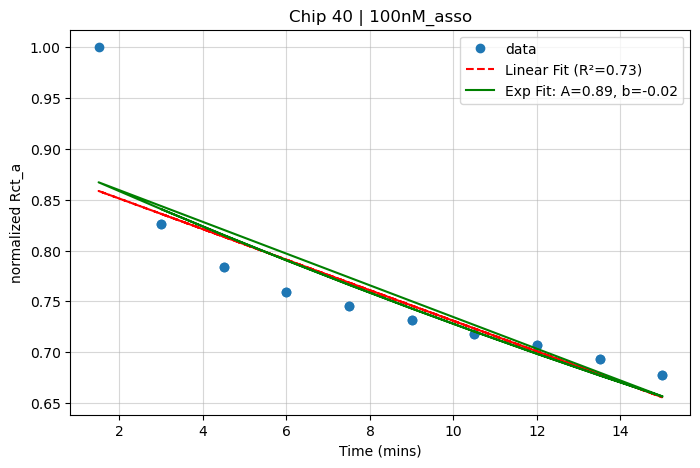

[0.92722964 0.91295146 0.89678833 0.88320609 0.87235366 0.86362532
 0.85272755 0.84654525 0.83998348 0.82405568 0.81963805 0.80933072
 0.80122433 0.79369217 0.78814567 0.78544879 0.77547034 0.76931764
 0.75797739 0.7499784  1.         0.92722964 0.91295146 0.89678833
 0.88320609 0.87235366 0.86362532 0.85272755 0.84654525 0.83998348
 0.82405568 0.81963805 0.80933072 0.80122433 0.79369217 0.78814567
 0.78544879 0.77547034 0.76931764 0.75797739 0.7499784 ]  y
[0.92722964 0.91295146 0.89678833 0.88320609 0.87235366 0.86362532
 0.85272755 0.84654525 0.83998348 0.82405568 0.81963805 0.80933072
 0.80122433 0.79369217 0.78814567 0.78544879 0.77547034 0.76931764
 0.75797739 0.7499784  1.         0.92722964 0.91295146 0.89678833
 0.88320609 0.87235366 0.86362532 0.85272755 0.84654525 0.83998348
 0.82405568 0.81963805 0.80933072 0.80122433 0.79369217 0.78814567
 0.78544879 0.77547034 0.76931764 0.75797739 0.7499784 ]  x


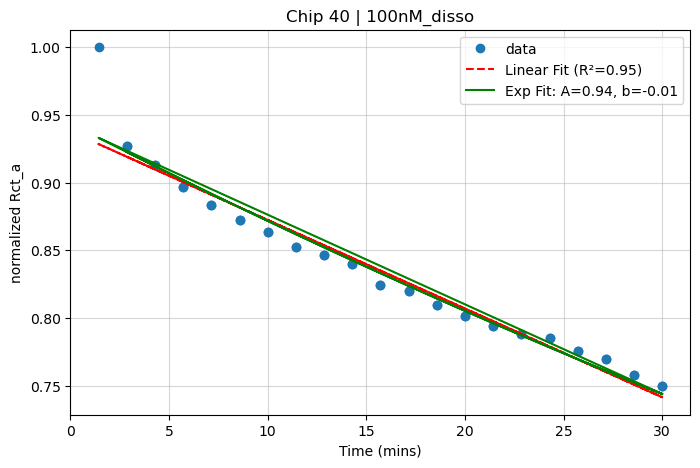

[0.85176723 0.81237432 0.7947999  0.77998867 0.77333851 0.7580833
 0.74118066 0.73656426 0.7232123  1.         0.85176723 0.81237432
 0.7947999  0.77998867 0.77333851 0.7580833  0.74118066 0.73656426
 0.7232123 ]  y
[0.85176723 0.81237432 0.7947999  0.77998867 0.77333851 0.7580833
 0.74118066 0.73656426 0.7232123  1.         0.85176723 0.81237432
 0.7947999  0.77998867 0.77333851 0.7580833  0.74118066 0.73656426
 0.7232123 ]  x


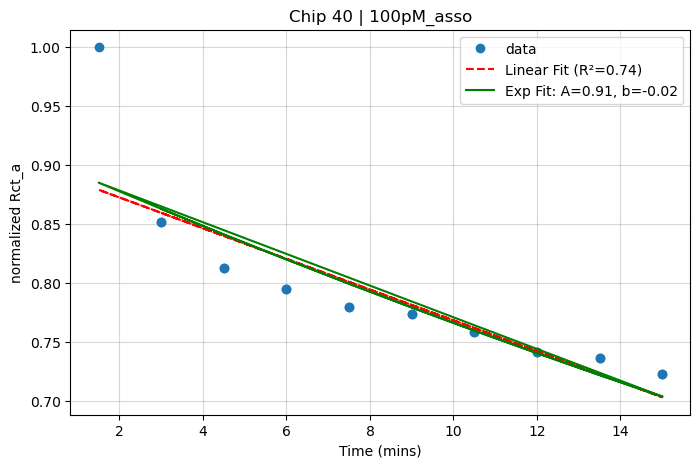

[0.9744656  0.96346889 0.92988954 0.91200519 0.90036557 0.88393394
 0.86533667 0.85192947 0.83480176 0.82404198 0.81302736 0.80756717
 0.79504877 0.78534627 0.78012145 0.76824489 0.76414106 0.75211918
 0.74884149 0.74822491 1.         0.9744656  0.96346889 0.92988954
 0.91200519 0.90036557 0.88393394 0.86533667 0.85192947 0.83480176
 0.82404198 0.81302736 0.80756717 0.79504877 0.78534627 0.78012145
 0.76824489 0.76414106 0.75211918 0.74884149 0.74822491]  y
[0.9744656  0.96346889 0.92988954 0.91200519 0.90036557 0.88393394
 0.86533667 0.85192947 0.83480176 0.82404198 0.81302736 0.80756717
 0.79504877 0.78534627 0.78012145 0.76824489 0.76414106 0.75211918
 0.74884149 0.74822491 1.         0.9744656  0.96346889 0.92988954
 0.91200519 0.90036557 0.88393394 0.86533667 0.85192947 0.83480176
 0.82404198 0.81302736 0.80756717 0.79504877 0.78534627 0.78012145
 0.76824489 0.76414106 0.75211918 0.74884149 0.74822491]  x


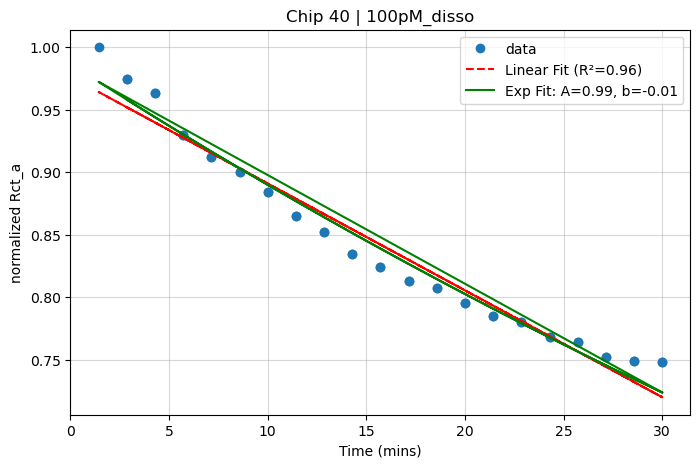

[0.83607885 0.79549506 0.77285843 0.75791714 0.74851071 0.73324832
 0.71550753 0.70521866 0.69536682 1.         0.83607885 0.79549506
 0.77285843 0.75791714 0.74851071 0.73324832 0.71550753 0.70521866
 0.69536682]  y
[0.83607885 0.79549506 0.77285843 0.75791714 0.74851071 0.73324832
 0.71550753 0.70521866 0.69536682 1.         0.83607885 0.79549506
 0.77285843 0.75791714 0.74851071 0.73324832 0.71550753 0.70521866
 0.69536682]  x


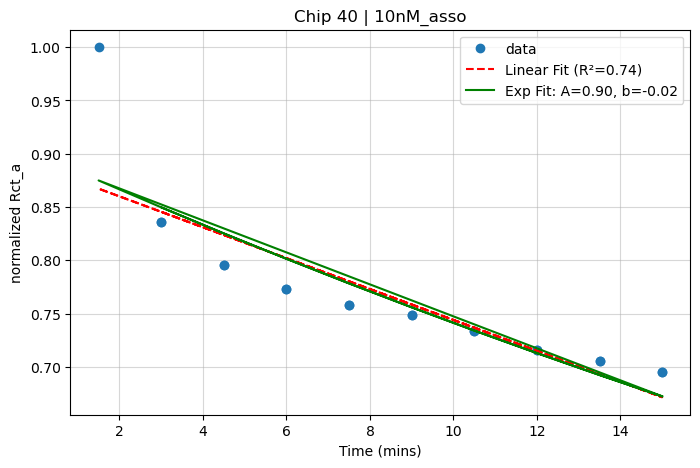

[0.94016597 0.92268069 0.90436876 0.89772822 0.87916632 0.86895931
 0.8568642  0.84796248 0.83762717 0.82405917 0.82102486 0.80924696
 0.79764802 0.78534554 0.78039093 0.76978008 0.76720264 0.75567472
 0.74446637 0.73887309 1.         0.94016597 0.92268069 0.90436876
 0.89772822 0.87916632 0.86895931 0.8568642  0.84796248 0.83762717
 0.82405917 0.82102486 0.80924696 0.79764802 0.78534554 0.78039093
 0.76978008 0.76720264 0.75567472 0.74446637 0.73887309]  y
[0.94016597 0.92268069 0.90436876 0.89772822 0.87916632 0.86895931
 0.8568642  0.84796248 0.83762717 0.82405917 0.82102486 0.80924696
 0.79764802 0.78534554 0.78039093 0.76978008 0.76720264 0.75567472
 0.74446637 0.73887309 1.         0.94016597 0.92268069 0.90436876
 0.89772822 0.87916632 0.86895931 0.8568642  0.84796248 0.83762717
 0.82405917 0.82102486 0.80924696 0.79764802 0.78534554 0.78039093
 0.76978008 0.76720264 0.75567472 0.74446637 0.73887309]  x


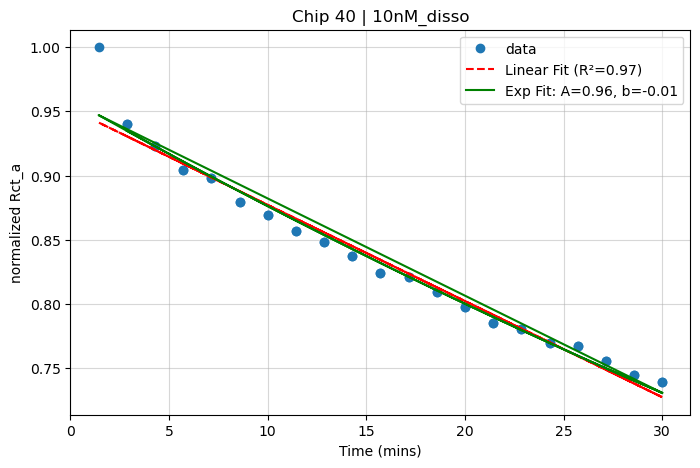

[0.80412724 0.76167754 0.74388636 0.73153223 0.72326955 0.71196439
 0.69521839 0.6870837  0.67762736 1.         0.80412724 0.76167754
 0.74388636 0.73153223 0.72326955 0.71196439 0.69521839 0.6870837
 0.67762736]  y
[0.80412724 0.76167754 0.74388636 0.73153223 0.72326955 0.71196439
 0.69521839 0.6870837  0.67762736 1.         0.80412724 0.76167754
 0.74388636 0.73153223 0.72326955 0.71196439 0.69521839 0.6870837
 0.67762736]  x


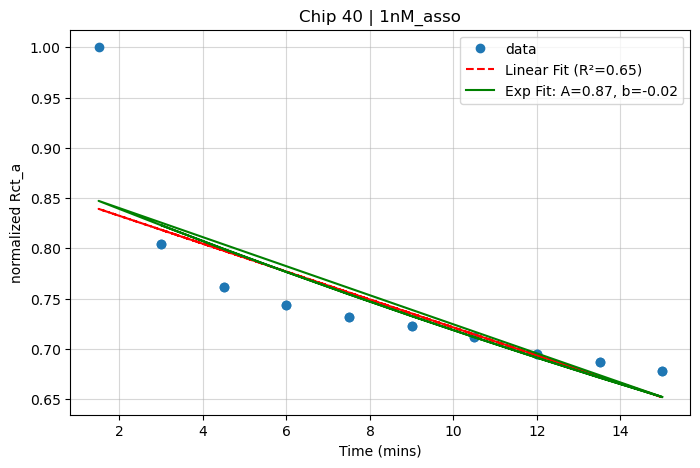

[0.96771178 0.95407107 0.94050042 0.92426748 0.91125381 0.89502888
 0.88377022 0.87366354 0.86710841 0.85367938 0.85016987 0.83720874
 0.8265591  0.82118299 0.81485856 0.80011039 0.79262547 0.78781034
 0.78091592 0.77311272 1.         0.96771178 0.95407107 0.94050042
 0.92426748 0.91125381 0.89502888 0.88377022 0.87366354 0.86710841
 0.85367938 0.85016987 0.83720874 0.8265591  0.82118299 0.81485856
 0.80011039 0.79262547 0.78781034 0.78091592 0.77311272]  y
[0.96771178 0.95407107 0.94050042 0.92426748 0.91125381 0.89502888
 0.88377022 0.87366354 0.86710841 0.85367938 0.85016987 0.83720874
 0.8265591  0.82118299 0.81485856 0.80011039 0.79262547 0.78781034
 0.78091592 0.77311272 1.         0.96771178 0.95407107 0.94050042
 0.92426748 0.91125381 0.89502888 0.88377022 0.87366354 0.86710841
 0.85367938 0.85016987 0.83720874 0.8265591  0.82118299 0.81485856
 0.80011039 0.79262547 0.78781034 0.78091592 0.77311272]  x


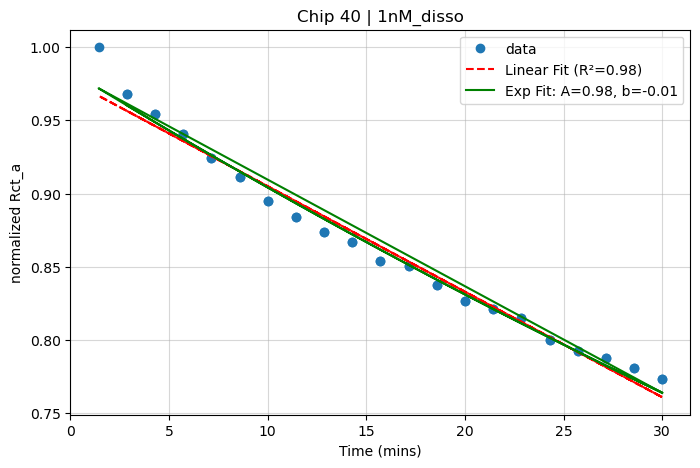

[0.94148524 0.91548528 0.89667953 0.87694863 0.86454801 0.85032536
 0.84220696 0.8259922  0.81589462 1.         0.94148524 0.91548528
 0.89667953 0.87694863 0.86454801 0.85032536 0.84220696 0.8259922
 0.81589462]  y
[0.94148524 0.91548528 0.89667953 0.87694863 0.86454801 0.85032536
 0.84220696 0.8259922  0.81589462 1.         0.94148524 0.91548528
 0.89667953 0.87694863 0.86454801 0.85032536 0.84220696 0.8259922
 0.81589462]  x


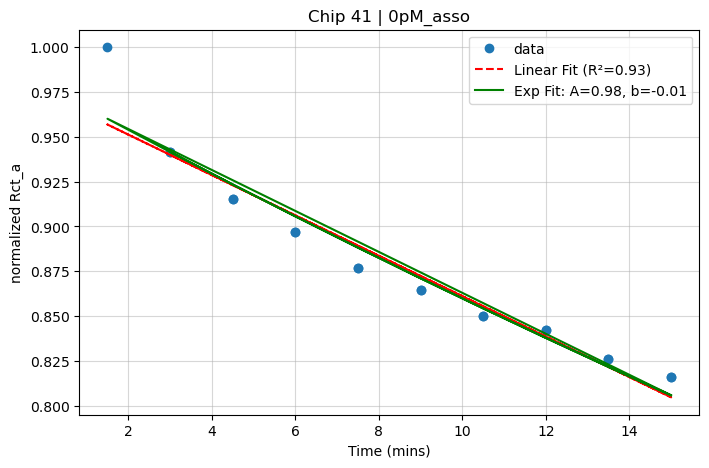

[0.93225799 0.90579705 0.89062843 0.87433326 0.87048132 0.85307551
 0.84670351 0.84083114 0.82479896 0.81907624 0.8082577  0.80437047
 0.79535759 0.78785556 0.7810565  0.77238616 0.76237997 0.75503504
 0.74823001 0.74102627 1.         0.93225799 0.90579705 0.89062843
 0.87433326 0.87048132 0.85307551 0.84670351 0.84083114 0.82479896
 0.81907624 0.8082577  0.80437047 0.79535759 0.78785556 0.7810565
 0.77238616 0.76237997 0.75503504 0.74823001 0.74102627]  y
[0.93225799 0.90579705 0.89062843 0.87433326 0.87048132 0.85307551
 0.84670351 0.84083114 0.82479896 0.81907624 0.8082577  0.80437047
 0.79535759 0.78785556 0.7810565  0.77238616 0.76237997 0.75503504
 0.74823001 0.74102627 1.         0.93225799 0.90579705 0.89062843
 0.87433326 0.87048132 0.85307551 0.84670351 0.84083114 0.82479896
 0.81907624 0.8082577  0.80437047 0.79535759 0.78785556 0.7810565
 0.77238616 0.76237997 0.75503504 0.74823001 0.74102627]  x


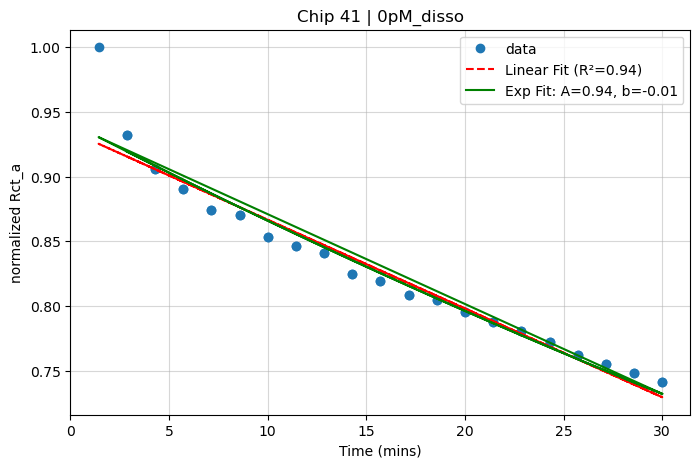

[0.80723056 0.7663571  0.74426589 0.72943546 0.71499195 0.69987606
 0.68697525 0.67933201 0.66280834 1.         0.80723056 0.7663571
 0.74426589 0.72943546 0.71499195 0.69987606 0.68697525 0.67933201
 0.66280834]  y
[0.80723056 0.7663571  0.74426589 0.72943546 0.71499195 0.69987606
 0.68697525 0.67933201 0.66280834 1.         0.80723056 0.7663571
 0.74426589 0.72943546 0.71499195 0.69987606 0.68697525 0.67933201
 0.66280834]  x


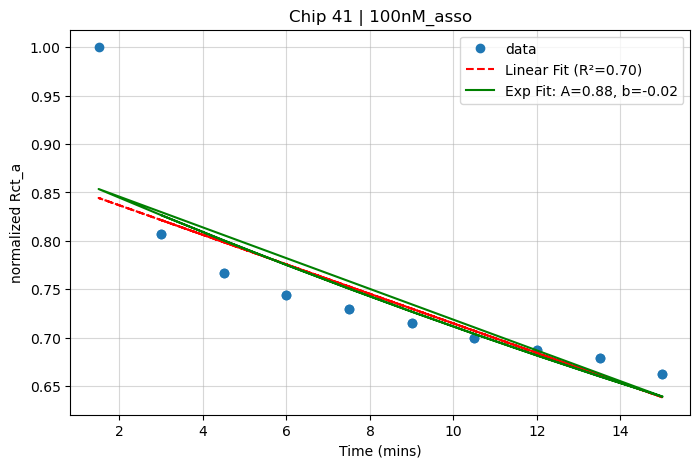

[0.93691665 0.91583371 0.89958031 0.88311423 0.87516086 0.8646164
 0.85166587 0.84344015 0.83396284 0.82539751 0.81918509 0.80852454
 0.80416809 0.79714731 0.78892051 0.78165669 0.77466575 0.7660912
 0.75596503 0.75046874 1.         0.93691665 0.91583371 0.89958031
 0.88311423 0.87516086 0.8646164  0.85166587 0.84344015 0.83396284
 0.82539751 0.81918509 0.80852454 0.80416809 0.79714731 0.78892051
 0.78165669 0.77466575 0.7660912  0.75596503 0.75046874]  y
[0.93691665 0.91583371 0.89958031 0.88311423 0.87516086 0.8646164
 0.85166587 0.84344015 0.83396284 0.82539751 0.81918509 0.80852454
 0.80416809 0.79714731 0.78892051 0.78165669 0.77466575 0.7660912
 0.75596503 0.75046874 1.         0.93691665 0.91583371 0.89958031
 0.88311423 0.87516086 0.8646164  0.85166587 0.84344015 0.83396284
 0.82539751 0.81918509 0.80852454 0.80416809 0.79714731 0.78892051
 0.78165669 0.77466575 0.7660912  0.75596503 0.75046874]  x


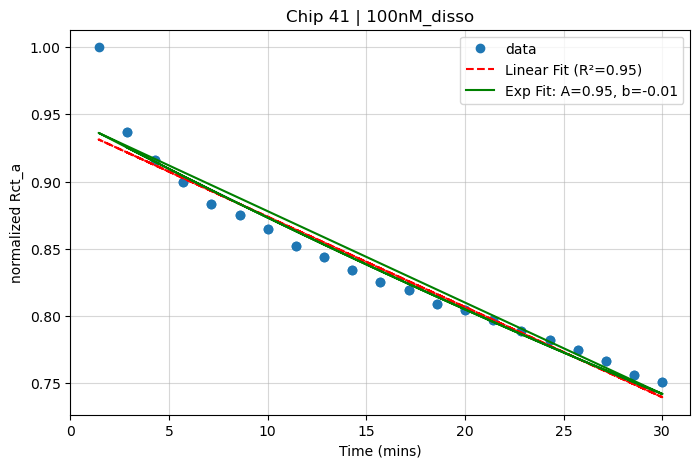

[0.84769909 0.81164143 0.79804087 0.77184195 0.76503544 0.74801524
 0.73549741 0.72617588 0.71110691 1.         0.84769909 0.81164143
 0.79804087 0.77184195 0.76503544 0.74801524 0.73549741 0.72617588
 0.71110691]  y
[0.84769909 0.81164143 0.79804087 0.77184195 0.76503544 0.74801524
 0.73549741 0.72617588 0.71110691 1.         0.84769909 0.81164143
 0.79804087 0.77184195 0.76503544 0.74801524 0.73549741 0.72617588
 0.71110691]  x


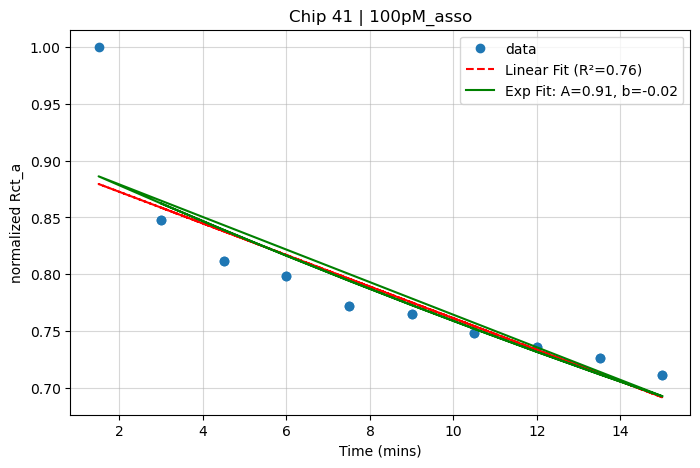

[0.92921767 0.90733324 0.8937606  0.87831623 0.8670275  0.85959834
 0.84961201 0.83623456 0.83012758 0.8215841  0.80974531 0.7980799
 0.79015999 0.78923882 0.77804084 0.76732499 0.76241243 0.75094626
 0.74998251 0.73823091 1.         0.92921767 0.90733324 0.8937606
 0.87831623 0.8670275  0.85959834 0.84961201 0.83623456 0.83012758
 0.8215841  0.80974531 0.7980799  0.79015999 0.78923882 0.77804084
 0.76732499 0.76241243 0.75094626 0.74998251 0.73823091]  y
[0.92921767 0.90733324 0.8937606  0.87831623 0.8670275  0.85959834
 0.84961201 0.83623456 0.83012758 0.8215841  0.80974531 0.7980799
 0.79015999 0.78923882 0.77804084 0.76732499 0.76241243 0.75094626
 0.74998251 0.73823091 1.         0.92921767 0.90733324 0.8937606
 0.87831623 0.8670275  0.85959834 0.84961201 0.83623456 0.83012758
 0.8215841  0.80974531 0.7980799  0.79015999 0.78923882 0.77804084
 0.76732499 0.76241243 0.75094626 0.74998251 0.73823091]  x


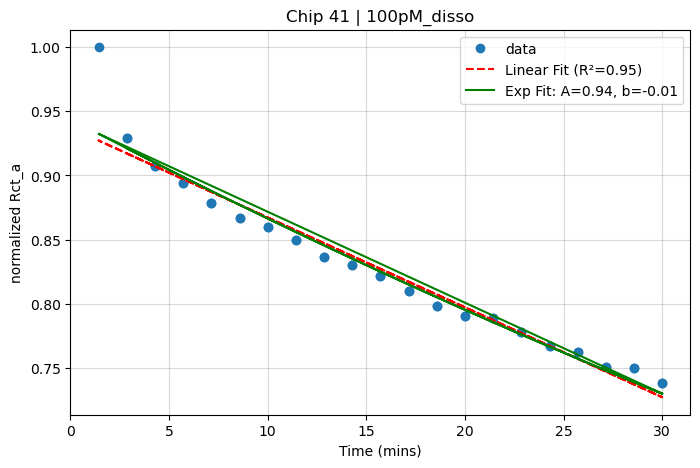

[0.84493247 0.81227569 0.78834237 0.78109402 0.76443431 0.75165075
 0.74026828 0.72801617 0.71853521 1.         0.84493247 0.81227569
 0.78834237 0.78109402 0.76443431 0.75165075 0.74026828 0.72801617
 0.71853521]  y
[0.84493247 0.81227569 0.78834237 0.78109402 0.76443431 0.75165075
 0.74026828 0.72801617 0.71853521 1.         0.84493247 0.81227569
 0.78834237 0.78109402 0.76443431 0.75165075 0.74026828 0.72801617
 0.71853521]  x


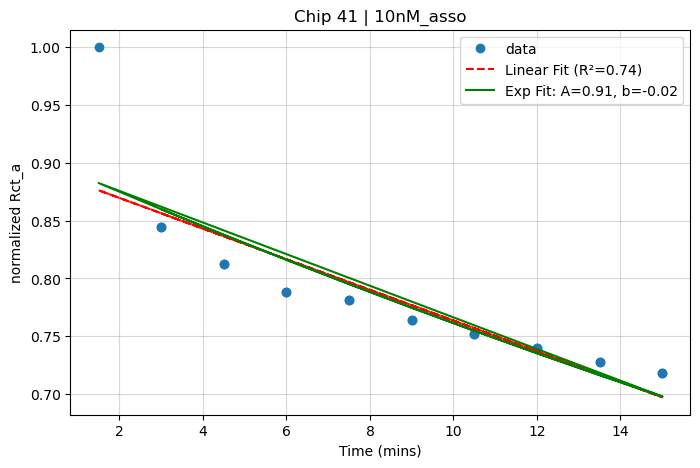

[0.94333064 0.92263564 0.90331431 0.89326307 0.88076976 0.86323365
 0.86037293 0.84695402 0.8359712  0.82878505 0.81886409 0.8107698
 0.80358637 0.7948701  0.79171121 0.78033972 0.77782405 0.76439424
 0.75696552 0.75295407 1.         0.94333064 0.92263564 0.90331431
 0.89326307 0.88076976 0.86323365 0.86037293 0.84695402 0.8359712
 0.82878505 0.81886409 0.8107698  0.80358637 0.7948701  0.79171121
 0.78033972 0.77782405 0.76439424 0.75696552 0.75295407]  y
[0.94333064 0.92263564 0.90331431 0.89326307 0.88076976 0.86323365
 0.86037293 0.84695402 0.8359712  0.82878505 0.81886409 0.8107698
 0.80358637 0.7948701  0.79171121 0.78033972 0.77782405 0.76439424
 0.75696552 0.75295407 1.         0.94333064 0.92263564 0.90331431
 0.89326307 0.88076976 0.86323365 0.86037293 0.84695402 0.8359712
 0.82878505 0.81886409 0.8107698  0.80358637 0.7948701  0.79171121
 0.78033972 0.77782405 0.76439424 0.75696552 0.75295407]  x


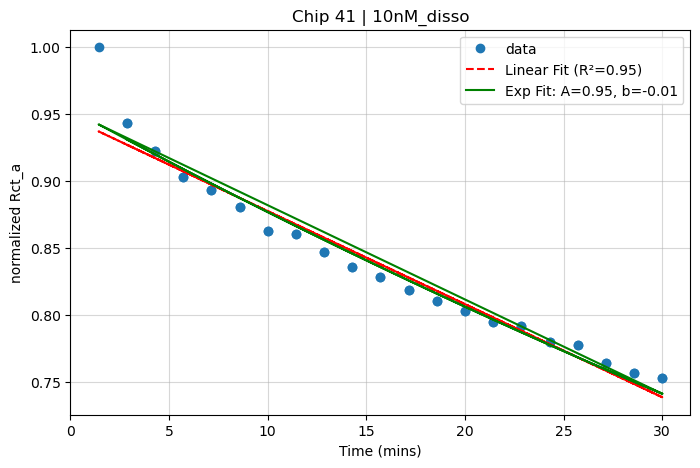

[0.84640984 0.80609534 0.79025626 0.7725416  0.76200411 0.74526479
 0.73245494 0.72127022 0.71060985 1.         0.84640984 0.80609534
 0.79025626 0.7725416  0.76200411 0.74526479 0.73245494 0.72127022
 0.71060985]  y
[0.84640984 0.80609534 0.79025626 0.7725416  0.76200411 0.74526479
 0.73245494 0.72127022 0.71060985 1.         0.84640984 0.80609534
 0.79025626 0.7725416  0.76200411 0.74526479 0.73245494 0.72127022
 0.71060985]  x


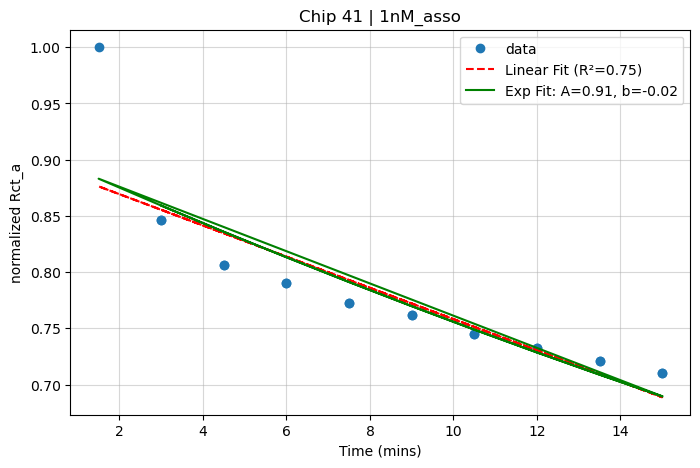

[0.92089002 0.90101853 0.8921267  0.87451917 0.86500004 0.85743903
 0.84878389 0.84065109 0.8289013  0.82589496 0.81473614 0.80785442
 0.80241001 0.78919869 0.78155996 0.77980572 0.76594337 0.75448881
 0.75191801 0.74846756 1.         0.92089002 0.90101853 0.8921267
 0.87451917 0.86500004 0.85743903 0.84878389 0.84065109 0.8289013
 0.82589496 0.81473614 0.80785442 0.80241001 0.78919869 0.78155996
 0.77980572 0.76594337 0.75448881 0.75191801 0.74846756]  y
[0.92089002 0.90101853 0.8921267  0.87451917 0.86500004 0.85743903
 0.84878389 0.84065109 0.8289013  0.82589496 0.81473614 0.80785442
 0.80241001 0.78919869 0.78155996 0.77980572 0.76594337 0.75448881
 0.75191801 0.74846756 1.         0.92089002 0.90101853 0.8921267
 0.87451917 0.86500004 0.85743903 0.84878389 0.84065109 0.8289013
 0.82589496 0.81473614 0.80785442 0.80241001 0.78919869 0.78155996
 0.77980572 0.76594337 0.75448881 0.75191801 0.74846756]  x


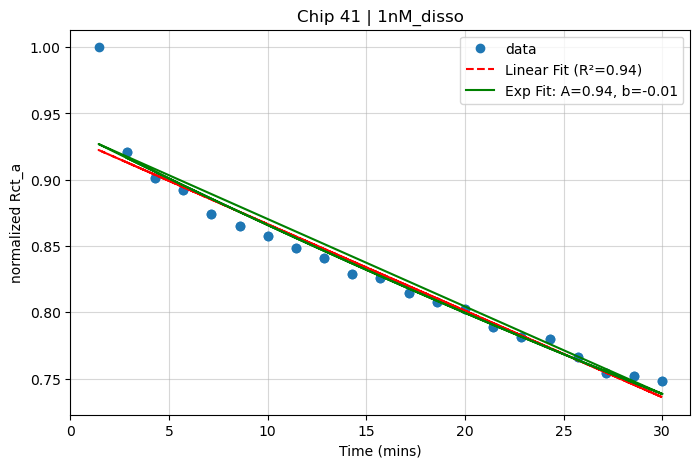

[0.92879857 0.90686713 0.88652671 0.8757738  0.85810653 0.8463987
 0.83234061 0.82036607 0.81328312 1.         0.92879857 0.90686713
 0.88652671 0.8757738  0.85810653 0.8463987  0.83234061 0.82036607
 0.81328312 1.         0.92879857 0.90686713 0.88652671 0.8757738
 0.85810653 0.8463987  0.83234061 0.82036607 0.81328312 1.
 0.92879857 0.90686713 0.88652671 0.8757738  0.85810653 0.8463987
 0.83234061 0.82036607 0.81328312 1.         0.92879857 0.90686713
 0.88652671 0.8757738  0.85810653 0.8463987  0.83234061 0.82036607
 0.81328312 1.         0.92879857 0.90686713 0.88652671 0.8757738
 0.85810653 0.8463987  0.83234061 0.82036607 0.81328312 1.
 0.92879857 0.90686713 0.88652671 0.8757738  0.85810653 0.8463987
 0.83234061 0.82036607 0.81328312]  y
[0.92879857 0.90686713 0.88652671 0.8757738  0.85810653 0.8463987
 0.83234061 0.82036607 0.81328312 1.         0.92879857 0.90686713
 0.88652671 0.8757738  0.85810653 0.8463987  0.83234061 0.82036607
 0.81328312 1.         0.92879857 0.90686713 0

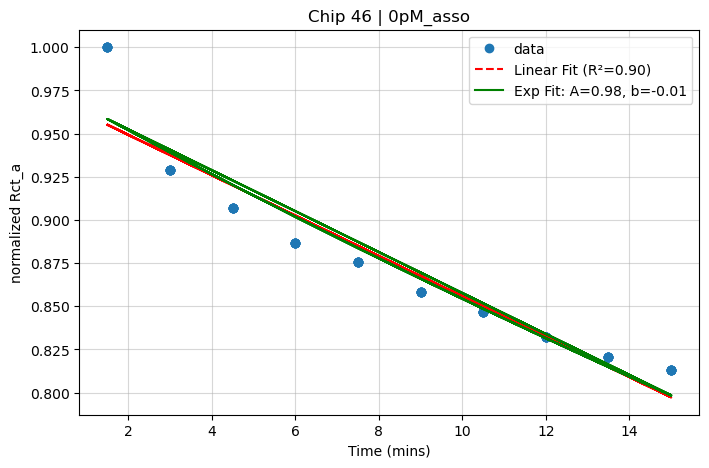

[0.94693185 0.92603949 0.91406321 0.9004598  0.88721137 0.87250669
 0.86386345 0.84854971 0.83115245 0.82356696 0.81356669 0.80439763
 0.79985801 0.7899509  0.77359816 0.77118173 0.76017554 0.74915888
 0.74339673 0.73439357 1.         0.94693185 0.92603949 0.91406321
 0.9004598  0.88721137 0.87250669 0.86386345 0.84854971 0.83115245
 0.82356696 0.81356669 0.80439763 0.79985801 0.7899509  0.77359816
 0.77118173 0.76017554 0.74915888 0.74339673 0.73439357 1.
 0.94693185 0.92603949 0.91406321 0.9004598  0.88721137 0.87250669
 0.86386345 0.84854971 0.83115245 0.82356696 0.81356669 0.80439763
 0.79985801 0.7899509  0.77359816 0.77118173 0.76017554 0.74915888
 0.74339673 0.73439357 1.         0.94693185 0.92603949 0.91406321
 0.9004598  0.88721137 0.87250669 0.86386345 0.84854971 0.83115245
 0.82356696 0.81356669 0.80439763 0.79985801 0.7899509  0.77359816
 0.77118173 0.76017554 0.74915888 0.74339673 0.73439357 1.
 0.94693185 0.92603949 0.91406321 0.9004598  0.88721137 0.87250669
 0.86386345

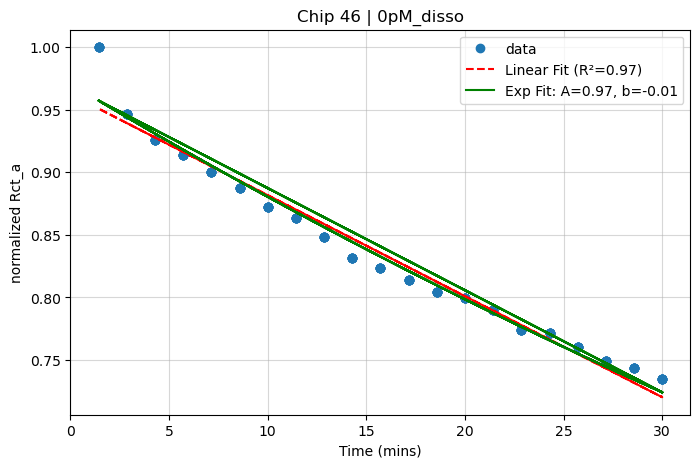

[0.83216168 0.79469207 0.7806303  0.75769056 0.74266565 0.73457832
 0.7180901  0.70813548 0.69374348 1.         0.83216168 0.79469207
 0.7806303  0.75769056 0.74266565 0.73457832 0.7180901  0.70813548
 0.69374348 1.         0.83216168 0.79469207 0.7806303  0.75769056
 0.74266565 0.73457832 0.7180901  0.70813548 0.69374348 1.
 0.83216168 0.79469207 0.7806303  0.75769056 0.74266565 0.73457832
 0.7180901  0.70813548 0.69374348 1.         0.83216168 0.79469207
 0.7806303  0.75769056 0.74266565 0.73457832 0.7180901  0.70813548
 0.69374348 1.         0.83216168 0.79469207 0.7806303  0.75769056
 0.74266565 0.73457832 0.7180901  0.70813548 0.69374348 1.
 0.83216168 0.79469207 0.7806303  0.75769056 0.74266565 0.73457832
 0.7180901  0.70813548 0.69374348]  y
[0.83216168 0.79469207 0.7806303  0.75769056 0.74266565 0.73457832
 0.7180901  0.70813548 0.69374348 1.         0.83216168 0.79469207
 0.7806303  0.75769056 0.74266565 0.73457832 0.7180901  0.70813548
 0.69374348 1.         0.83216168 0.7946

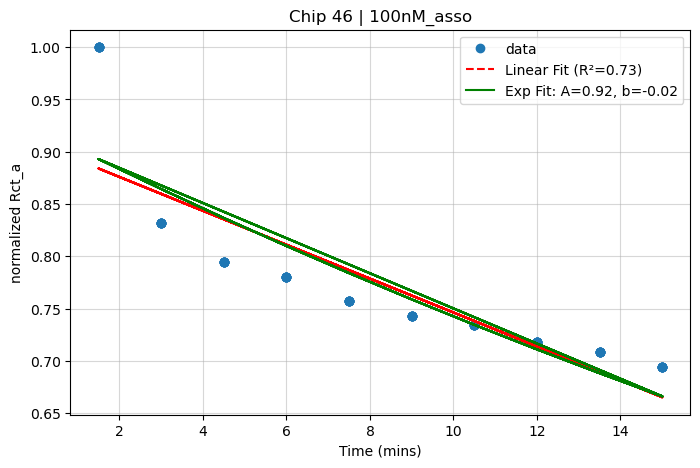

[0.9393982  0.9152969  0.89960808 0.88770721 0.87451827 0.8636484
 0.85458563 0.84371739 0.83560556 0.8314478  0.82145316 0.81312565
 0.81049342 0.80240555 0.79435636 0.78319402 0.77533435 0.76214378
 0.76235129 0.75499051 1.         0.9393982  0.9152969  0.89960808
 0.88770721 0.87451827 0.8636484  0.85458563 0.84371739 0.83560556
 0.8314478  0.82145316 0.81312565 0.81049342 0.80240555 0.79435636
 0.78319402 0.77533435 0.76214378 0.76235129 0.75499051 1.
 0.9393982  0.9152969  0.89960808 0.88770721 0.87451827 0.8636484
 0.85458563 0.84371739 0.83560556 0.8314478  0.82145316 0.81312565
 0.81049342 0.80240555 0.79435636 0.78319402 0.77533435 0.76214378
 0.76235129 0.75499051 1.         0.9393982  0.9152969  0.89960808
 0.88770721 0.87451827 0.8636484  0.85458563 0.84371739 0.83560556
 0.8314478  0.82145316 0.81312565 0.81049342 0.80240555 0.79435636
 0.78319402 0.77533435 0.76214378 0.76235129 0.75499051 1.
 0.9393982  0.9152969  0.89960808 0.88770721 0.87451827 0.8636484
 0.85458563 0.

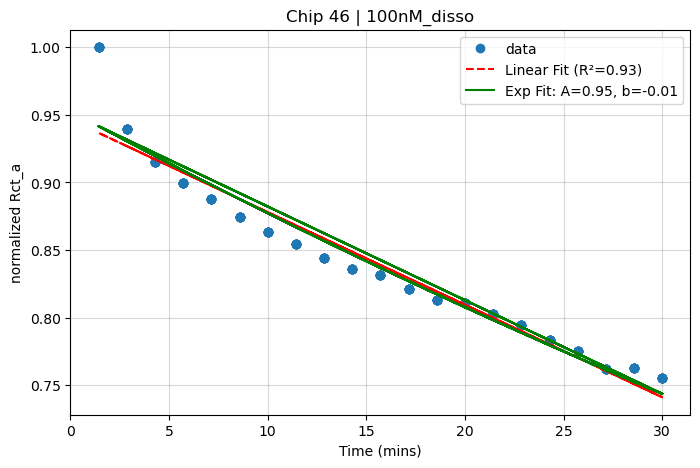

[0.86720716 0.8312655  0.81528743 0.79450453 0.78059661 0.76390102
 0.75147051 0.73673407 0.72817719 1.         0.86720716 0.8312655
 0.81528743 0.79450453 0.78059661 0.76390102 0.75147051 0.73673407
 0.72817719 1.         0.86720716 0.8312655  0.81528743 0.79450453
 0.78059661 0.76390102 0.75147051 0.73673407 0.72817719 1.
 0.86720716 0.8312655  0.81528743 0.79450453 0.78059661 0.76390102
 0.75147051 0.73673407 0.72817719 1.         0.86720716 0.8312655
 0.81528743 0.79450453 0.78059661 0.76390102 0.75147051 0.73673407
 0.72817719 1.         0.86720716 0.8312655  0.81528743 0.79450453
 0.78059661 0.76390102 0.75147051 0.73673407 0.72817719 1.
 0.86720716 0.8312655  0.81528743 0.79450453 0.78059661 0.76390102
 0.75147051 0.73673407 0.72817719]  y
[0.86720716 0.8312655  0.81528743 0.79450453 0.78059661 0.76390102
 0.75147051 0.73673407 0.72817719 1.         0.86720716 0.8312655
 0.81528743 0.79450453 0.78059661 0.76390102 0.75147051 0.73673407
 0.72817719 1.         0.86720716 0.8312655

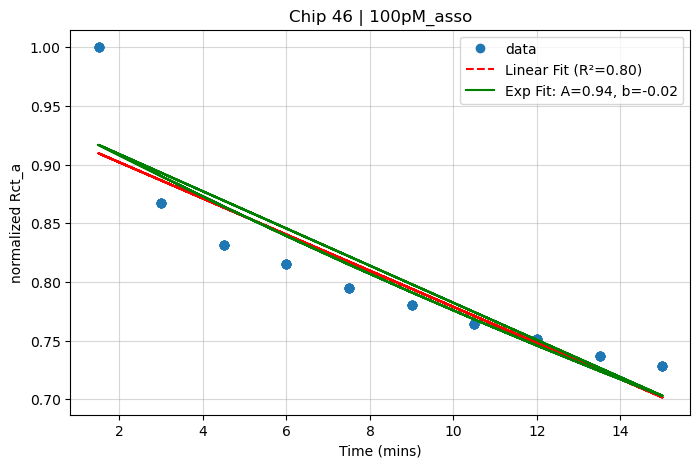

[0.92549817 0.90672595 0.88737687 0.87722712 0.8661199  0.85665589
 0.85473074 0.84332918 0.83873329 0.82924178 0.82164254 0.81825425
 0.80288325 0.80291128 0.79626949 0.78700279 0.78084458 0.76756369
 0.7640665  0.74687008 1.         0.92549817 0.90672595 0.88737687
 0.87722712 0.8661199  0.85665589 0.85473074 0.84332918 0.83873329
 0.82924178 0.82164254 0.81825425 0.80288325 0.80291128 0.79626949
 0.78700279 0.78084458 0.76756369 0.7640665  0.74687008 1.
 0.92549817 0.90672595 0.88737687 0.87722712 0.8661199  0.85665589
 0.85473074 0.84332918 0.83873329 0.82924178 0.82164254 0.81825425
 0.80288325 0.80291128 0.79626949 0.78700279 0.78084458 0.76756369
 0.7640665  0.74687008 1.         0.92549817 0.90672595 0.88737687
 0.87722712 0.8661199  0.85665589 0.85473074 0.84332918 0.83873329
 0.82924178 0.82164254 0.81825425 0.80288325 0.80291128 0.79626949
 0.78700279 0.78084458 0.76756369 0.7640665  0.74687008 1.
 0.92549817 0.90672595 0.88737687 0.87722712 0.8661199  0.85665589
 0.85473074

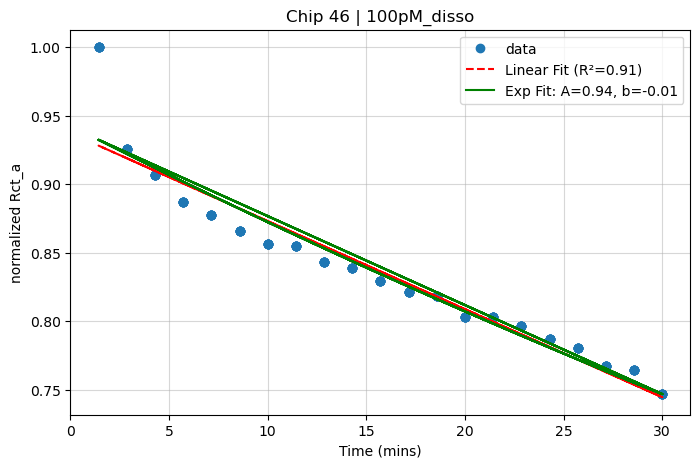

[0.91832799 0.89334888 0.87217901 0.85627375 0.83938055 0.82709894
 0.81306807 0.80497532 0.79051384 1.         0.91832799 0.89334888
 0.87217901 0.85627375 0.83938055 0.82709894 0.81306807 0.80497532
 0.79051384 1.         0.91832799 0.89334888 0.87217901 0.85627375
 0.83938055 0.82709894 0.81306807 0.80497532 0.79051384 1.
 0.91832799 0.89334888 0.87217901 0.85627375 0.83938055 0.82709894
 0.81306807 0.80497532 0.79051384 1.         0.91832799 0.89334888
 0.87217901 0.85627375 0.83938055 0.82709894 0.81306807 0.80497532
 0.79051384 1.         0.91832799 0.89334888 0.87217901 0.85627375
 0.83938055 0.82709894 0.81306807 0.80497532 0.79051384 1.
 0.91832799 0.89334888 0.87217901 0.85627375 0.83938055 0.82709894
 0.81306807 0.80497532 0.79051384]  y
[0.91832799 0.89334888 0.87217901 0.85627375 0.83938055 0.82709894
 0.81306807 0.80497532 0.79051384 1.         0.91832799 0.89334888
 0.87217901 0.85627375 0.83938055 0.82709894 0.81306807 0.80497532
 0.79051384 1.         0.91832799 0.8933

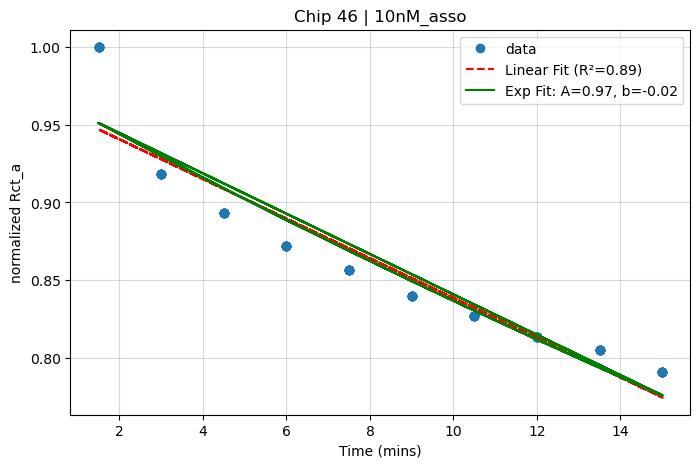

[0.93924438 0.91364134 0.90526753 0.89594343 0.87602058 0.87259667
 0.85902161 0.85073051 0.84176642 0.82938112 0.82543937 0.81319948
 0.80755821 0.80010714 0.79289175 0.7769112  0.77908857 0.77179535
 0.75613156 0.74856752 1.         0.93924438 0.91364134 0.90526753
 0.89594343 0.87602058 0.87259667 0.85902161 0.85073051 0.84176642
 0.82938112 0.82543937 0.81319948 0.80755821 0.80010714 0.79289175
 0.7769112  0.77908857 0.77179535 0.75613156 0.74856752 1.
 0.93924438 0.91364134 0.90526753 0.89594343 0.87602058 0.87259667
 0.85902161 0.85073051 0.84176642 0.82938112 0.82543937 0.81319948
 0.80755821 0.80010714 0.79289175 0.7769112  0.77908857 0.77179535
 0.75613156 0.74856752 1.         0.93924438 0.91364134 0.90526753
 0.89594343 0.87602058 0.87259667 0.85902161 0.85073051 0.84176642
 0.82938112 0.82543937 0.81319948 0.80755821 0.80010714 0.79289175
 0.7769112  0.77908857 0.77179535 0.75613156 0.74856752 1.
 0.93924438 0.91364134 0.90526753 0.89594343 0.87602058 0.87259667
 0.85902161

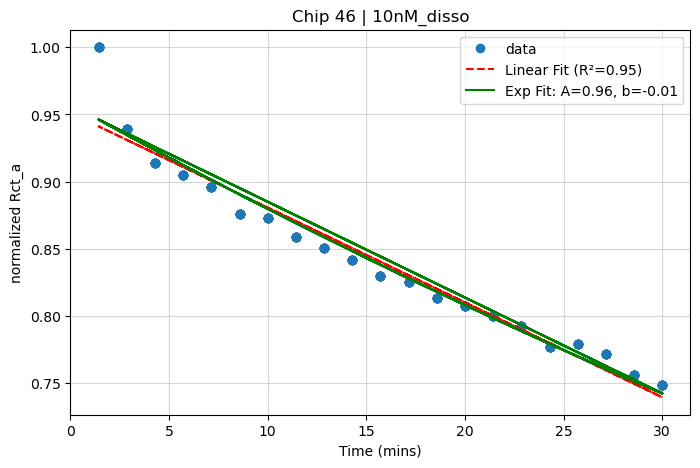

[0.88239341 0.85210983 0.82944309 0.81712721 0.80652019 0.78541901
 0.77087383 0.75971258 0.75028688 1.         0.88239341 0.85210983
 0.82944309 0.81712721 0.80652019 0.78541901 0.77087383 0.75971258
 0.75028688 1.         0.88239341 0.85210983 0.82944309 0.81712721
 0.80652019 0.78541901 0.77087383 0.75971258 0.75028688 1.
 0.88239341 0.85210983 0.82944309 0.81712721 0.80652019 0.78541901
 0.77087383 0.75971258 0.75028688 1.         0.88239341 0.85210983
 0.82944309 0.81712721 0.80652019 0.78541901 0.77087383 0.75971258
 0.75028688 1.         0.88239341 0.85210983 0.82944309 0.81712721
 0.80652019 0.78541901 0.77087383 0.75971258 0.75028688 1.
 0.88239341 0.85210983 0.82944309 0.81712721 0.80652019 0.78541901
 0.77087383 0.75971258 0.75028688]  y
[0.88239341 0.85210983 0.82944309 0.81712721 0.80652019 0.78541901
 0.77087383 0.75971258 0.75028688 1.         0.88239341 0.85210983
 0.82944309 0.81712721 0.80652019 0.78541901 0.77087383 0.75971258
 0.75028688 1.         0.88239341 0.8521

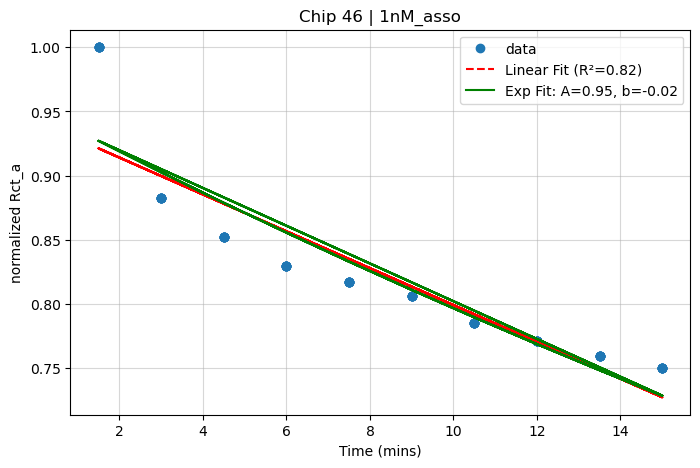

[0.9360504  0.91519445 0.89766601 0.88614204 0.87255995 0.86576245
 0.85540625 0.84601782 0.83146258 0.83185238 0.81506482 0.8124755
 0.80128756 0.78975391 0.77959396 0.77426317 0.76914475 0.76095259
 0.75208191 0.73810088 1.         0.9360504  0.91519445 0.89766601
 0.88614204 0.87255995 0.86576245 0.85540625 0.84601782 0.83146258
 0.83185238 0.81506482 0.8124755  0.80128756 0.78975391 0.77959396
 0.77426317 0.76914475 0.76095259 0.75208191 0.73810088 1.
 0.9360504  0.91519445 0.89766601 0.88614204 0.87255995 0.86576245
 0.85540625 0.84601782 0.83146258 0.83185238 0.81506482 0.8124755
 0.80128756 0.78975391 0.77959396 0.77426317 0.76914475 0.76095259
 0.75208191 0.73810088 1.         0.9360504  0.91519445 0.89766601
 0.88614204 0.87255995 0.86576245 0.85540625 0.84601782 0.83146258
 0.83185238 0.81506482 0.8124755  0.80128756 0.78975391 0.77959396
 0.77426317 0.76914475 0.76095259 0.75208191 0.73810088 1.
 0.9360504  0.91519445 0.89766601 0.88614204 0.87255995 0.86576245
 0.85540625 0

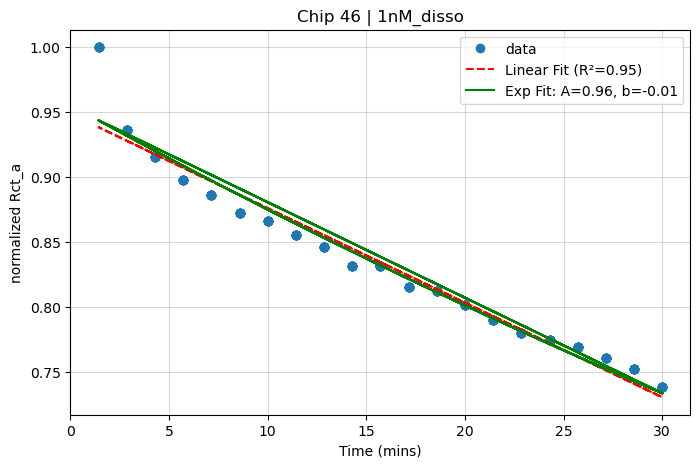

[0.96968418 0.9480794  0.92529692 0.90696869 0.89424662 0.87190643
 0.85977156 0.84290151 0.83499013 1.         0.96968418 0.9480794
 0.92529692 0.90696869 0.89424662 0.87190643 0.85977156 0.84290151
 0.83499013 1.         0.96968418 0.9480794  0.92529692 0.90696869
 0.89424662 0.87190643 0.85977156 0.84290151 0.83499013 1.
 0.96968418 0.9480794  0.92529692 0.90696869 0.89424662 0.87190643
 0.85977156 0.84290151 0.83499013 1.         0.96968418 0.9480794
 0.92529692 0.90696869 0.89424662 0.87190643 0.85977156 0.84290151
 0.83499013]  y
[0.96968418 0.9480794  0.92529692 0.90696869 0.89424662 0.87190643
 0.85977156 0.84290151 0.83499013 1.         0.96968418 0.9480794
 0.92529692 0.90696869 0.89424662 0.87190643 0.85977156 0.84290151
 0.83499013 1.         0.96968418 0.9480794  0.92529692 0.90696869
 0.89424662 0.87190643 0.85977156 0.84290151 0.83499013 1.
 0.96968418 0.9480794  0.92529692 0.90696869 0.89424662 0.87190643
 0.85977156 0.84290151 0.83499013 1.         0.96968418 0.9480794

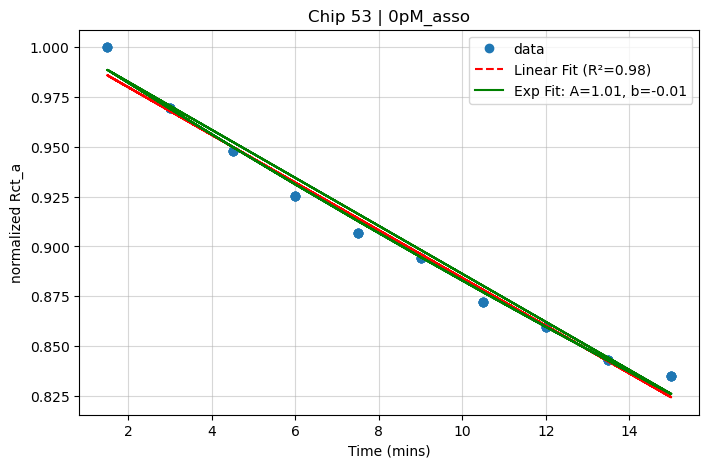

[0.93442347 0.92169437 0.90560657 0.88776901 0.87560657 0.87083239
 0.86267793 0.85061268 0.83753333 0.82508732 0.82007793 0.81284601
 0.80319296 0.79119155 0.7825554  0.77013568 0.76245211 0.75372676
 0.75136573 0.74012394 1.         0.93442347 0.92169437 0.90560657
 0.88776901 0.87560657 0.87083239 0.86267793 0.85061268 0.83753333
 0.82508732 0.82007793 0.81284601 0.80319296 0.79119155 0.7825554
 0.77013568 0.76245211 0.75372676 0.75136573 0.74012394 1.
 0.93442347 0.92169437 0.90560657 0.88776901 0.87560657 0.87083239
 0.86267793 0.85061268 0.83753333 0.82508732 0.82007793 0.81284601
 0.80319296 0.79119155 0.7825554  0.77013568 0.76245211 0.75372676
 0.75136573 0.74012394 1.         0.93442347 0.92169437 0.90560657
 0.88776901 0.87560657 0.87083239 0.86267793 0.85061268 0.83753333
 0.82508732 0.82007793 0.81284601 0.80319296 0.79119155 0.7825554
 0.77013568 0.76245211 0.75372676 0.75136573 0.74012394 1.
 0.93442347 0.92169437 0.90560657 0.88776901 0.87560657 0.87083239
 0.86267793 0

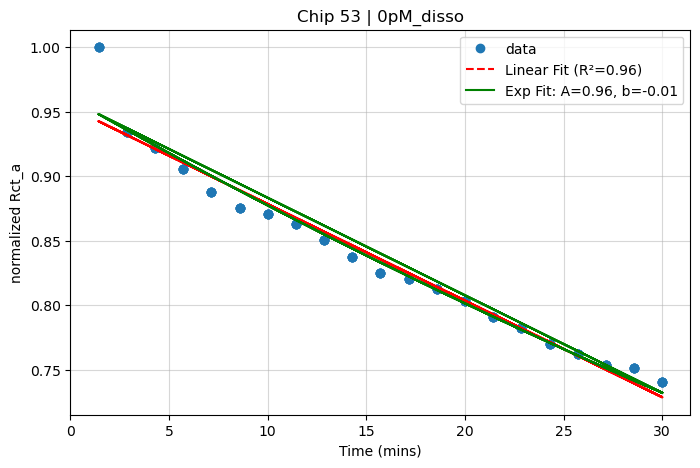

[0.82103497 0.77906383 0.75476178 0.74375348 0.72775592 0.71088975
 0.69981827 0.68091541 0.67587839 1.         0.82103497 0.77906383
 0.75476178 0.74375348 0.72775592 0.71088975 0.69981827 0.68091541
 0.67587839 1.         0.82103497 0.77906383 0.75476178 0.74375348
 0.72775592 0.71088975 0.69981827 0.68091541 0.67587839 1.
 0.82103497 0.77906383 0.75476178 0.74375348 0.72775592 0.71088975
 0.69981827 0.68091541 0.67587839 1.         0.82103497 0.77906383
 0.75476178 0.74375348 0.72775592 0.71088975 0.69981827 0.68091541
 0.67587839]  y
[0.82103497 0.77906383 0.75476178 0.74375348 0.72775592 0.71088975
 0.69981827 0.68091541 0.67587839 1.         0.82103497 0.77906383
 0.75476178 0.74375348 0.72775592 0.71088975 0.69981827 0.68091541
 0.67587839 1.         0.82103497 0.77906383 0.75476178 0.74375348
 0.72775592 0.71088975 0.69981827 0.68091541 0.67587839 1.
 0.82103497 0.77906383 0.75476178 0.74375348 0.72775592 0.71088975
 0.69981827 0.68091541 0.67587839 1.         0.82103497 0.7790

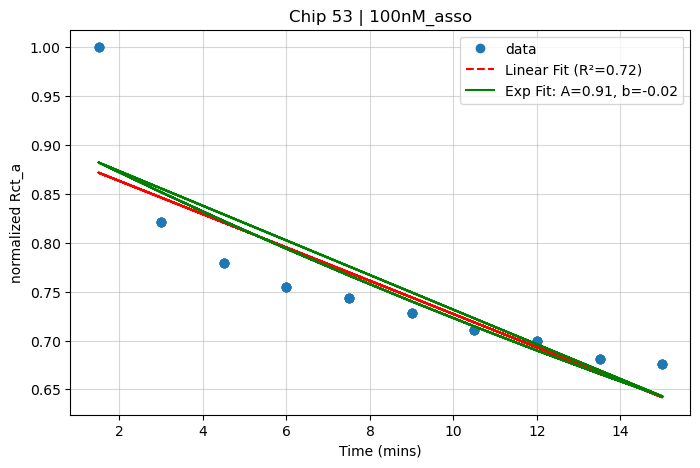

[0.93246728 0.91685717 0.90248625 0.8913588  0.88117373 0.86149775
 0.85755382 0.85016336 0.84219145 0.829767   0.82817417 0.81497929
 0.81442503 0.80374011 0.79675139 0.79172759 0.77902868 0.76983118
 0.76055449 0.75214442 1.         0.93246728 0.91685717 0.90248625
 0.8913588  0.88117373 0.86149775 0.85755382 0.85016336 0.84219145
 0.829767   0.82817417 0.81497929 0.81442503 0.80374011 0.79675139
 0.79172759 0.77902868 0.76983118 0.76055449 0.75214442 1.
 0.93246728 0.91685717 0.90248625 0.8913588  0.88117373 0.86149775
 0.85755382 0.85016336 0.84219145 0.829767   0.82817417 0.81497929
 0.81442503 0.80374011 0.79675139 0.79172759 0.77902868 0.76983118
 0.76055449 0.75214442 1.         0.93246728 0.91685717 0.90248625
 0.8913588  0.88117373 0.86149775 0.85755382 0.85016336 0.84219145
 0.829767   0.82817417 0.81497929 0.81442503 0.80374011 0.79675139
 0.79172759 0.77902868 0.76983118 0.76055449 0.75214442 1.
 0.93246728 0.91685717 0.90248625 0.8913588  0.88117373 0.86149775
 0.85755382

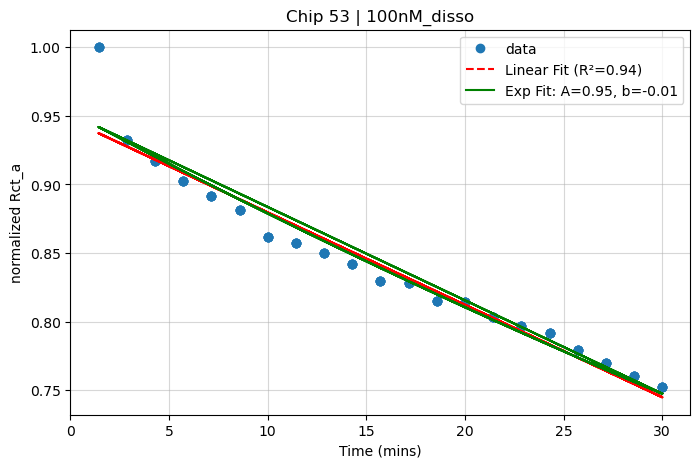

[0.8508497  0.81494921 0.78809678 0.77468631 0.75424301 0.74036097
 0.72996007 0.71873289 0.70784412 1.         0.8508497  0.81494921
 0.78809678 0.77468631 0.75424301 0.74036097 0.72996007 0.71873289
 0.70784412 1.         0.8508497  0.81494921 0.78809678 0.77468631
 0.75424301 0.74036097 0.72996007 0.71873289 0.70784412 1.
 0.8508497  0.81494921 0.78809678 0.77468631 0.75424301 0.74036097
 0.72996007 0.71873289 0.70784412 1.         0.8508497  0.81494921
 0.78809678 0.77468631 0.75424301 0.74036097 0.72996007 0.71873289
 0.70784412]  y
[0.8508497  0.81494921 0.78809678 0.77468631 0.75424301 0.74036097
 0.72996007 0.71873289 0.70784412 1.         0.8508497  0.81494921
 0.78809678 0.77468631 0.75424301 0.74036097 0.72996007 0.71873289
 0.70784412 1.         0.8508497  0.81494921 0.78809678 0.77468631
 0.75424301 0.74036097 0.72996007 0.71873289 0.70784412 1.
 0.8508497  0.81494921 0.78809678 0.77468631 0.75424301 0.74036097
 0.72996007 0.71873289 0.70784412 1.         0.8508497  0.8149

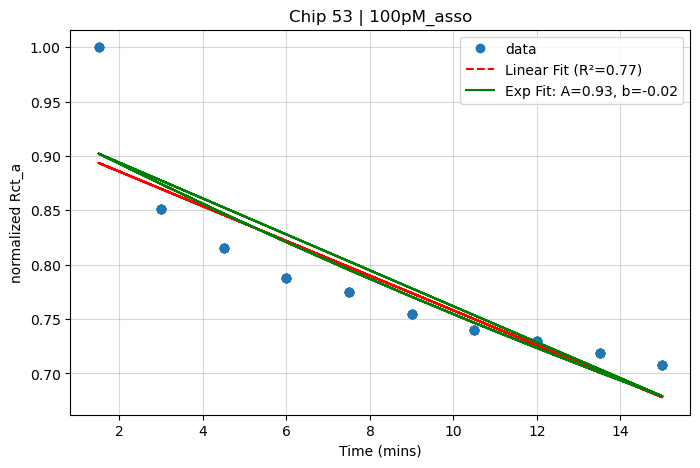

[0.94282347 0.92036507 0.90838464 0.89627945 0.88727699 0.8733007
 0.86304864 0.84780147 0.8378292  0.83769876 0.81896319 0.81558774
 0.80322355 0.79652322 0.78142257 0.77115397 0.75554288 0.75669607
 0.74378269 0.73220305 1.         0.94282347 0.92036507 0.90838464
 0.89627945 0.88727699 0.8733007  0.86304864 0.84780147 0.8378292
 0.83769876 0.81896319 0.81558774 0.80322355 0.79652322 0.78142257
 0.77115397 0.75554288 0.75669607 0.74378269 0.73220305 1.
 0.94282347 0.92036507 0.90838464 0.89627945 0.88727699 0.8733007
 0.86304864 0.84780147 0.8378292  0.83769876 0.81896319 0.81558774
 0.80322355 0.79652322 0.78142257 0.77115397 0.75554288 0.75669607
 0.74378269 0.73220305 1.         0.94282347 0.92036507 0.90838464
 0.89627945 0.88727699 0.8733007  0.86304864 0.84780147 0.8378292
 0.83769876 0.81896319 0.81558774 0.80322355 0.79652322 0.78142257
 0.77115397 0.75554288 0.75669607 0.74378269 0.73220305 1.
 0.94282347 0.92036507 0.90838464 0.89627945 0.88727699 0.8733007
 0.86304864 0.84

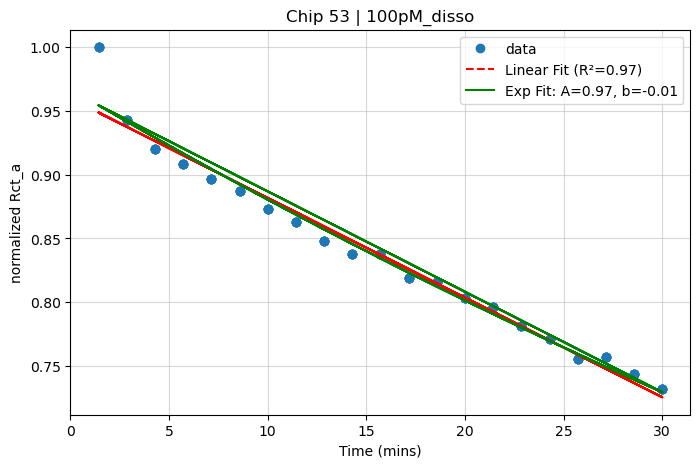

[0.83250733 0.78943955 0.77552957 0.76477431 0.74990351 0.73354531
 0.72205901 0.71497647 0.7029601  1.         0.83250733 0.78943955
 0.77552957 0.76477431 0.74990351 0.73354531 0.72205901 0.71497647
 0.7029601  1.         0.83250733 0.78943955 0.77552957 0.76477431
 0.74990351 0.73354531 0.72205901 0.71497647 0.7029601  1.
 0.83250733 0.78943955 0.77552957 0.76477431 0.74990351 0.73354531
 0.72205901 0.71497647 0.7029601  1.         0.83250733 0.78943955
 0.77552957 0.76477431 0.74990351 0.73354531 0.72205901 0.71497647
 0.7029601 ]  y
[0.83250733 0.78943955 0.77552957 0.76477431 0.74990351 0.73354531
 0.72205901 0.71497647 0.7029601  1.         0.83250733 0.78943955
 0.77552957 0.76477431 0.74990351 0.73354531 0.72205901 0.71497647
 0.7029601  1.         0.83250733 0.78943955 0.77552957 0.76477431
 0.74990351 0.73354531 0.72205901 0.71497647 0.7029601  1.
 0.83250733 0.78943955 0.77552957 0.76477431 0.74990351 0.73354531
 0.72205901 0.71497647 0.7029601  1.         0.83250733 0.7894

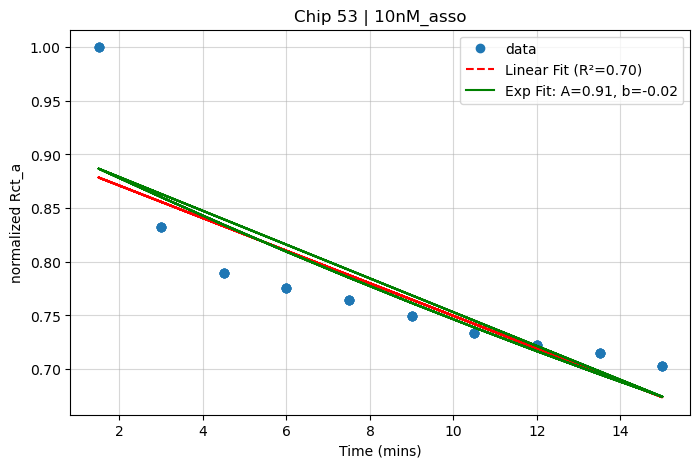

[0.93213587 0.90584936 0.89980908 0.88391863 0.86966349 0.85982136
 0.8530507  0.83850653 0.8361399  0.81967375 0.81563349 0.80847305
 0.80184288 0.79815598 0.78077261 0.77926219 0.77117836 0.76078419
 0.75588631 0.74387102 1.         0.93213587 0.90584936 0.89980908
 0.88391863 0.86966349 0.85982136 0.8530507  0.83850653 0.8361399
 0.81967375 0.81563349 0.80847305 0.80184288 0.79815598 0.78077261
 0.77926219 0.77117836 0.76078419 0.75588631 0.74387102 1.
 0.93213587 0.90584936 0.89980908 0.88391863 0.86966349 0.85982136
 0.8530507  0.83850653 0.8361399  0.81967375 0.81563349 0.80847305
 0.80184288 0.79815598 0.78077261 0.77926219 0.77117836 0.76078419
 0.75588631 0.74387102 1.         0.93213587 0.90584936 0.89980908
 0.88391863 0.86966349 0.85982136 0.8530507  0.83850653 0.8361399
 0.81967375 0.81563349 0.80847305 0.80184288 0.79815598 0.78077261
 0.77926219 0.77117836 0.76078419 0.75588631 0.74387102 1.
 0.93213587 0.90584936 0.89980908 0.88391863 0.86966349 0.85982136
 0.8530507  0

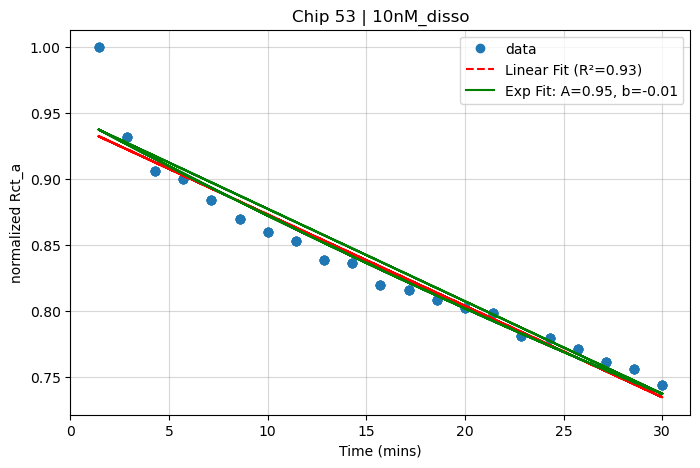

[0.82536165 0.78744093 0.7663298  0.74983587 0.74235022 0.72741843
 0.71290465 0.705419   0.69235148 1.         0.82536165 0.78744093
 0.7663298  0.74983587 0.74235022 0.72741843 0.71290465 0.705419
 0.69235148 1.         0.82536165 0.78744093 0.7663298  0.74983587
 0.74235022 0.72741843 0.71290465 0.705419   0.69235148 1.
 0.82536165 0.78744093 0.7663298  0.74983587 0.74235022 0.72741843
 0.71290465 0.705419   0.69235148 1.         0.82536165 0.78744093
 0.7663298  0.74983587 0.74235022 0.72741843 0.71290465 0.705419
 0.69235148]  y
[0.82536165 0.78744093 0.7663298  0.74983587 0.74235022 0.72741843
 0.71290465 0.705419   0.69235148 1.         0.82536165 0.78744093
 0.7663298  0.74983587 0.74235022 0.72741843 0.71290465 0.705419
 0.69235148 1.         0.82536165 0.78744093 0.7663298  0.74983587
 0.74235022 0.72741843 0.71290465 0.705419   0.69235148 1.
 0.82536165 0.78744093 0.7663298  0.74983587 0.74235022 0.72741843
 0.71290465 0.705419   0.69235148 1.         0.82536165 0.78744093
 

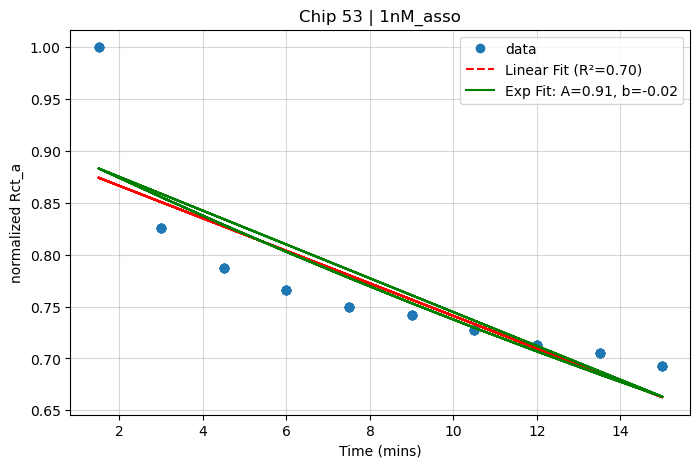

[0.93615303 0.91499346 0.9047663  0.88516302 0.87475695 0.86447488
 0.85491795 0.84680278 0.8412464  0.82714885 0.81885097 0.80764308
 0.80647113 0.79272621 0.78607313 0.77473413 0.77032463 0.7620949
 0.75704073 0.74761018 1.         0.93615303 0.91499346 0.9047663
 0.88516302 0.87475695 0.86447488 0.85491795 0.84680278 0.8412464
 0.82714885 0.81885097 0.80764308 0.80647113 0.79272621 0.78607313
 0.77473413 0.77032463 0.7620949  0.75704073 0.74761018 1.
 0.93615303 0.91499346 0.9047663  0.88516302 0.87475695 0.86447488
 0.85491795 0.84680278 0.8412464  0.82714885 0.81885097 0.80764308
 0.80647113 0.79272621 0.78607313 0.77473413 0.77032463 0.7620949
 0.75704073 0.74761018 1.         0.93615303 0.91499346 0.9047663
 0.88516302 0.87475695 0.86447488 0.85491795 0.84680278 0.8412464
 0.82714885 0.81885097 0.80764308 0.80647113 0.79272621 0.78607313
 0.77473413 0.77032463 0.7620949  0.75704073 0.74761018 1.
 0.93615303 0.91499346 0.9047663  0.88516302 0.87475695 0.86447488
 0.85491795 0.846

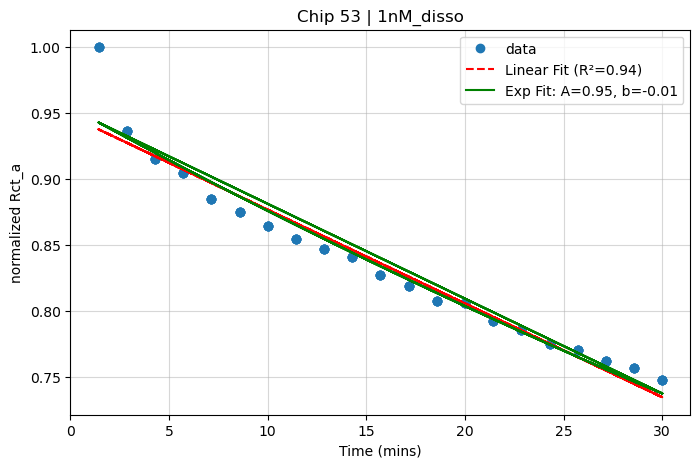

[0.95651178 0.92705815 0.90317608 0.88472072 0.87315761 0.85475054
 0.84187021 0.82796972 0.8094816  1.         0.95651178 0.92705815
 0.90317608 0.88472072 0.87315761 0.85475054 0.84187021 0.82796972
 0.8094816 ]  y
[0.95651178 0.92705815 0.90317608 0.88472072 0.87315761 0.85475054
 0.84187021 0.82796972 0.8094816  1.         0.95651178 0.92705815
 0.90317608 0.88472072 0.87315761 0.85475054 0.84187021 0.82796972
 0.8094816 ]  x


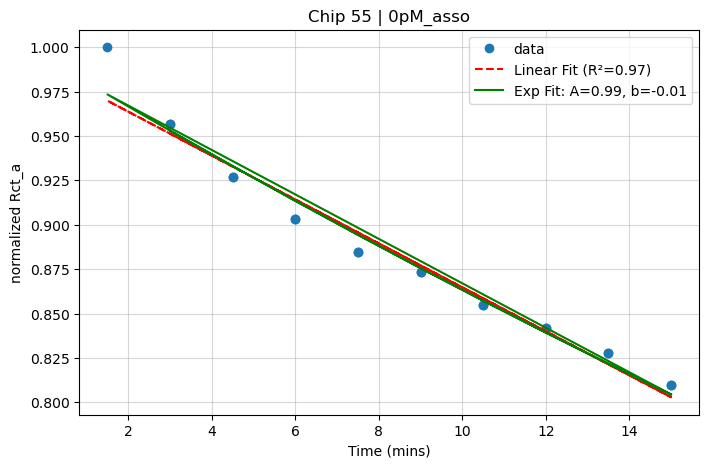

[0.93007583 0.91251858 0.8957966  0.8832488  0.86981172 0.85798335
 0.84215152 0.83442504 0.81985525 0.81163536 0.79893775 0.78681107
 0.77609843 0.76939274 0.75743242 0.74867687 0.7393247  0.73308281
 0.7228614  0.71219405 1.         0.93007583 0.91251858 0.8957966
 0.8832488  0.86981172 0.85798335 0.84215152 0.83442504 0.81985525
 0.81163536 0.79893775 0.78681107 0.77609843 0.76939274 0.75743242
 0.74867687 0.7393247  0.73308281 0.7228614  0.71219405]  y
[0.93007583 0.91251858 0.8957966  0.8832488  0.86981172 0.85798335
 0.84215152 0.83442504 0.81985525 0.81163536 0.79893775 0.78681107
 0.77609843 0.76939274 0.75743242 0.74867687 0.7393247  0.73308281
 0.7228614  0.71219405 1.         0.93007583 0.91251858 0.8957966
 0.8832488  0.86981172 0.85798335 0.84215152 0.83442504 0.81985525
 0.81163536 0.79893775 0.78681107 0.77609843 0.76939274 0.75743242
 0.74867687 0.7393247  0.73308281 0.7228614  0.71219405]  x


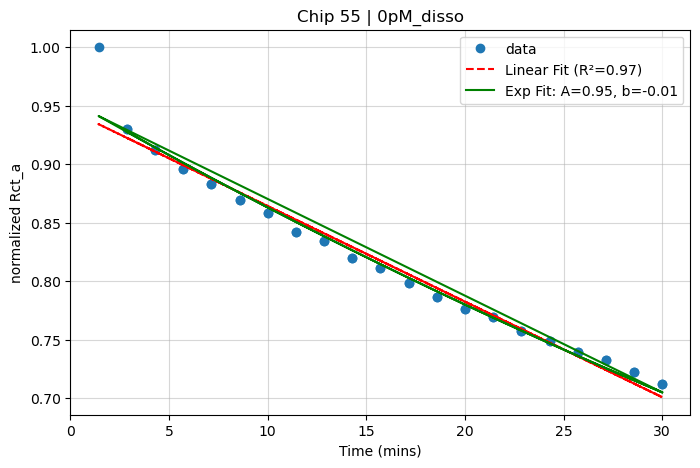

[0.86152375 0.82295151 0.80384915 0.78381703 0.77269763 0.75701547
 0.73850553 0.72928264 0.70997048 1.         0.86152375 0.82295151
 0.80384915 0.78381703 0.77269763 0.75701547 0.73850553 0.72928264
 0.70997048]  y
[0.86152375 0.82295151 0.80384915 0.78381703 0.77269763 0.75701547
 0.73850553 0.72928264 0.70997048 1.         0.86152375 0.82295151
 0.80384915 0.78381703 0.77269763 0.75701547 0.73850553 0.72928264
 0.70997048]  x


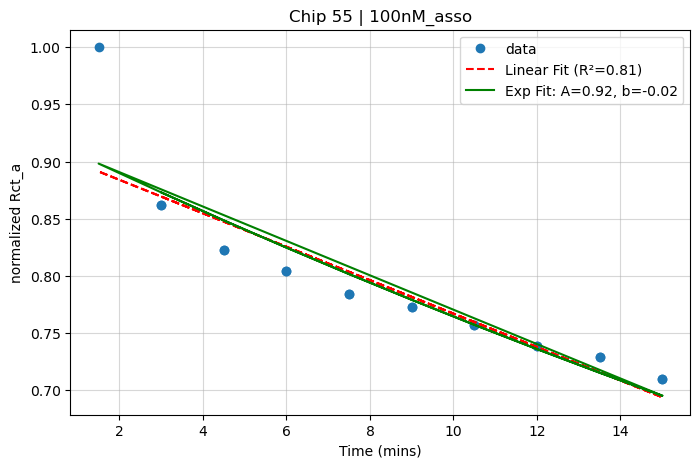

[0.93757517 0.92513743 0.90688774 0.89249106 0.87818415 0.86794833
 0.85268903 0.83705843 0.82986911 0.82190012 0.81197559 0.79876306
 0.78787589 0.7762432  0.76861916 0.75245234 0.75080029 0.7387158
 0.73015253 0.72619951 1.         0.93757517 0.92513743 0.90688774
 0.89249106 0.87818415 0.86794833 0.85268903 0.83705843 0.82986911
 0.82190012 0.81197559 0.79876306 0.78787589 0.7762432  0.76861916
 0.75245234 0.75080029 0.7387158  0.73015253 0.72619951]  y
[0.93757517 0.92513743 0.90688774 0.89249106 0.87818415 0.86794833
 0.85268903 0.83705843 0.82986911 0.82190012 0.81197559 0.79876306
 0.78787589 0.7762432  0.76861916 0.75245234 0.75080029 0.7387158
 0.73015253 0.72619951 1.         0.93757517 0.92513743 0.90688774
 0.89249106 0.87818415 0.86794833 0.85268903 0.83705843 0.82986911
 0.82190012 0.81197559 0.79876306 0.78787589 0.7762432  0.76861916
 0.75245234 0.75080029 0.7387158  0.73015253 0.72619951]  x


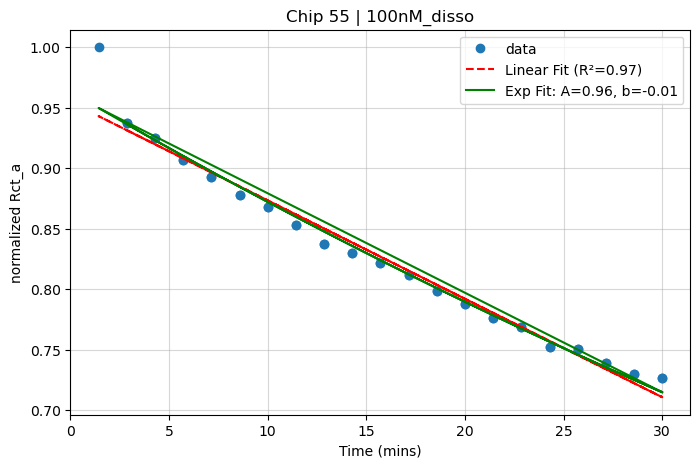

[0.85106414 0.81465752 0.78818684 0.77492011 0.75907429 0.74319295
 0.73141209 0.71976065 0.7095216  1.         0.85106414 0.81465752
 0.78818684 0.77492011 0.75907429 0.74319295 0.73141209 0.71976065
 0.7095216 ]  y
[0.85106414 0.81465752 0.78818684 0.77492011 0.75907429 0.74319295
 0.73141209 0.71976065 0.7095216  1.         0.85106414 0.81465752
 0.78818684 0.77492011 0.75907429 0.74319295 0.73141209 0.71976065
 0.7095216 ]  x


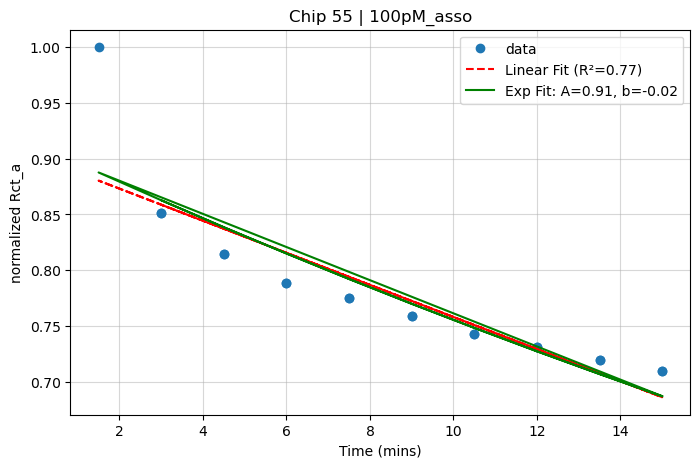

[0.95001728 0.9265096  0.91625131 0.89797683 0.88291195 0.86735599
 0.85942419 0.84933985 0.8395698  0.82842982 0.81733819 0.80613754
 0.79622338 0.78670882 0.77601205 0.76599787 0.75233894 0.74230154
 0.73606673 0.72510309 1.         0.95001728 0.9265096  0.91625131
 0.89797683 0.88291195 0.86735599 0.85942419 0.84933985 0.8395698
 0.82842982 0.81733819 0.80613754 0.79622338 0.78670882 0.77601205
 0.76599787 0.75233894 0.74230154 0.73606673 0.72510309]  y
[0.95001728 0.9265096  0.91625131 0.89797683 0.88291195 0.86735599
 0.85942419 0.84933985 0.8395698  0.82842982 0.81733819 0.80613754
 0.79622338 0.78670882 0.77601205 0.76599787 0.75233894 0.74230154
 0.73606673 0.72510309 1.         0.95001728 0.9265096  0.91625131
 0.89797683 0.88291195 0.86735599 0.85942419 0.84933985 0.8395698
 0.82842982 0.81733819 0.80613754 0.79622338 0.78670882 0.77601205
 0.76599787 0.75233894 0.74230154 0.73606673 0.72510309]  x


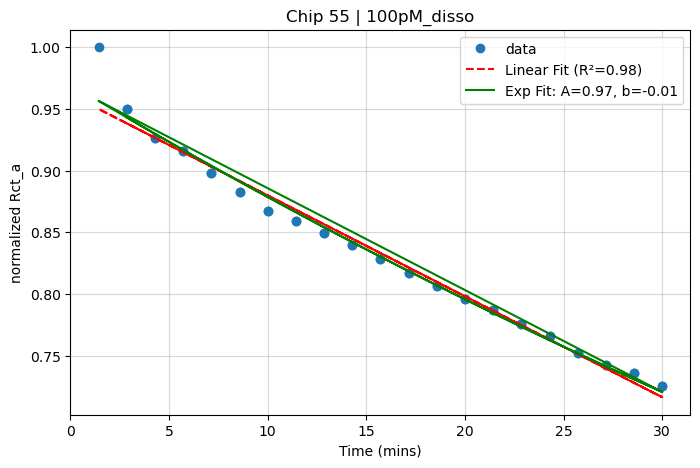

[0.8459671  0.81042353 0.79240606 0.77280084 0.76062742 0.7504627
 0.73523045 0.72375661 0.71127086 1.         0.8459671  0.81042353
 0.79240606 0.77280084 0.76062742 0.7504627  0.73523045 0.72375661
 0.71127086]  y
[0.8459671  0.81042353 0.79240606 0.77280084 0.76062742 0.7504627
 0.73523045 0.72375661 0.71127086 1.         0.8459671  0.81042353
 0.79240606 0.77280084 0.76062742 0.7504627  0.73523045 0.72375661
 0.71127086]  x


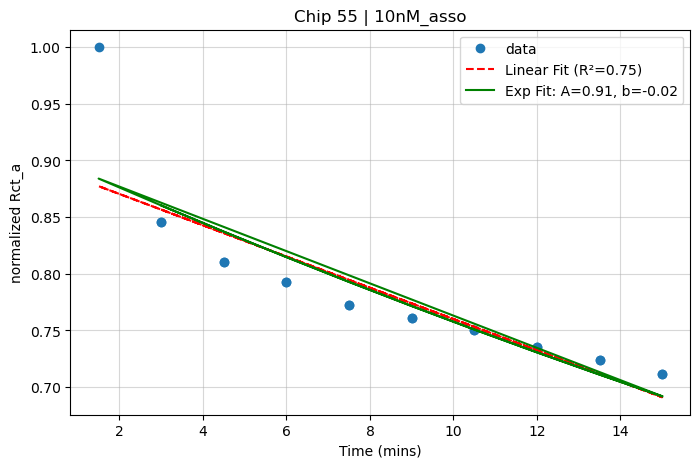

[0.94581841 0.92544195 0.91163446 0.89676822 0.88480031 0.87382913
 0.86424486 0.84974558 0.84512368 0.83445886 0.8233641  0.80901824
 0.79751295 0.79404166 0.78089946 0.77517664 0.76202212 0.75382429
 0.74239996 0.73706637 1.         0.94581841 0.92544195 0.91163446
 0.89676822 0.88480031 0.87382913 0.86424486 0.84974558 0.84512368
 0.83445886 0.8233641  0.80901824 0.79751295 0.79404166 0.78089946
 0.77517664 0.76202212 0.75382429 0.74239996 0.73706637]  y
[0.94581841 0.92544195 0.91163446 0.89676822 0.88480031 0.87382913
 0.86424486 0.84974558 0.84512368 0.83445886 0.8233641  0.80901824
 0.79751295 0.79404166 0.78089946 0.77517664 0.76202212 0.75382429
 0.74239996 0.73706637 1.         0.94581841 0.92544195 0.91163446
 0.89676822 0.88480031 0.87382913 0.86424486 0.84974558 0.84512368
 0.83445886 0.8233641  0.80901824 0.79751295 0.79404166 0.78089946
 0.77517664 0.76202212 0.75382429 0.74239996 0.73706637]  x


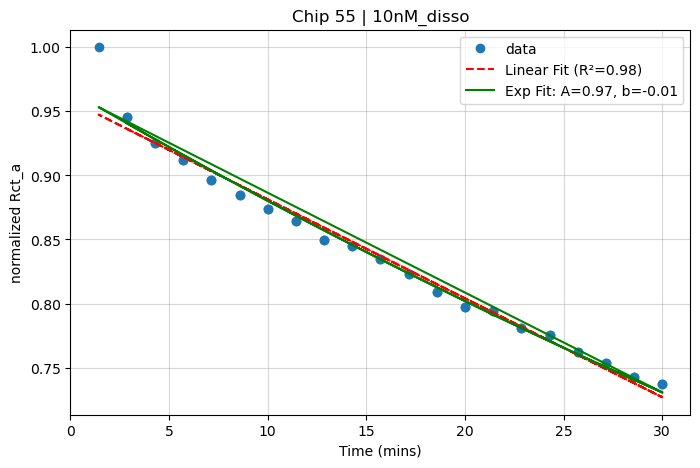

[0.8410964  0.79738342 0.77903399 0.76830654 0.7462284  0.73951541
 0.72612952 0.70951929 0.70034644 1.         0.8410964  0.79738342
 0.77903399 0.76830654 0.7462284  0.73951541 0.72612952 0.70951929
 0.70034644]  y
[0.8410964  0.79738342 0.77903399 0.76830654 0.7462284  0.73951541
 0.72612952 0.70951929 0.70034644 1.         0.8410964  0.79738342
 0.77903399 0.76830654 0.7462284  0.73951541 0.72612952 0.70951929
 0.70034644]  x


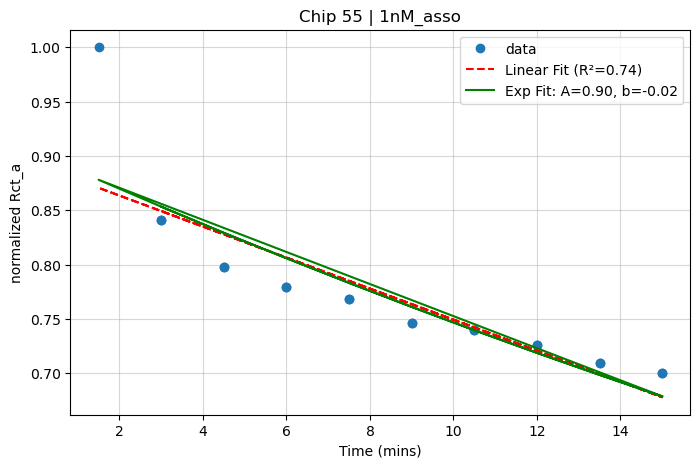

[0.95642712 0.93763547 0.91866084 0.90632267 0.89371697 0.87914755
 0.86921482 0.85674312 0.85064634 0.83798288 0.82799471 0.82201853
 0.81481791 0.8057275  0.78925119 0.78451054 0.77177732 0.76801113
 0.75166466 0.7483596  1.         0.95642712 0.93763547 0.91866084
 0.90632267 0.89371697 0.87914755 0.86921482 0.85674312 0.85064634
 0.83798288 0.82799471 0.82201853 0.81481791 0.8057275  0.78925119
 0.78451054 0.77177732 0.76801113 0.75166466 0.7483596 ]  y
[0.95642712 0.93763547 0.91866084 0.90632267 0.89371697 0.87914755
 0.86921482 0.85674312 0.85064634 0.83798288 0.82799471 0.82201853
 0.81481791 0.8057275  0.78925119 0.78451054 0.77177732 0.76801113
 0.75166466 0.7483596  1.         0.95642712 0.93763547 0.91866084
 0.90632267 0.89371697 0.87914755 0.86921482 0.85674312 0.85064634
 0.83798288 0.82799471 0.82201853 0.81481791 0.8057275  0.78925119
 0.78451054 0.77177732 0.76801113 0.75166466 0.7483596 ]  x


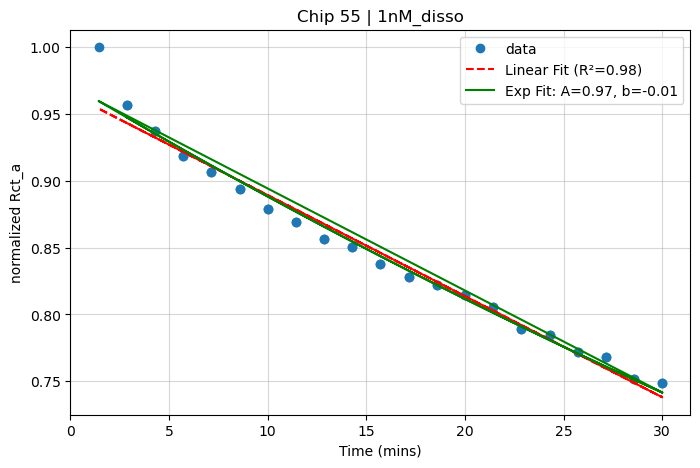

PDF saved to: /Users/deeptabharadwaj/Documents/lab/aranLab/AranLab/BioSensorAnalysisSrcCode/EIS_Analysis/Austin_EIS/MegaExcel/Processed Chips for PCAI1ia/Rct_vs_time_plots_normalized Rct_a.pdf
PDF saved to: /Users/deeptabharadwaj/Documents/lab/aranLab/AranLab/BioSensorAnalysisSrcCode/EIS_Analysis/Austin_EIS/MegaExcel/Processed Chips for PCAI1ia/Rct_vs_time_plots_normalized Rct_a_Subtracted.pdf

Processing: normalized Rct_d

Excel saved to: /Users/deeptabharadwaj/Documents/lab/aranLab/AranLab/BioSensorAnalysisSrcCode/EIS_Analysis/Austin_EIS/MegaExcel/Processed Chips for PCAI1ia/Big Excel normalized Rct_d.xlsx
Excel saved to: /Users/deeptabharadwaj/Documents/lab/aranLab/AranLab/BioSensorAnalysisSrcCode/EIS_Analysis/Austin_EIS/MegaExcel/Processed Chips for PCAI1ia/Big Excel normalized Rct_d Subtracted.xlsx
[0.97777669 0.96175844 0.94647447 0.91132362 0.91401061 0.90191293
 0.885193   0.87566287 0.8681921  1.         0.97606246 0.95928123
 0.94374614 0.92777086 0.91489328 0.90260147 0.8920

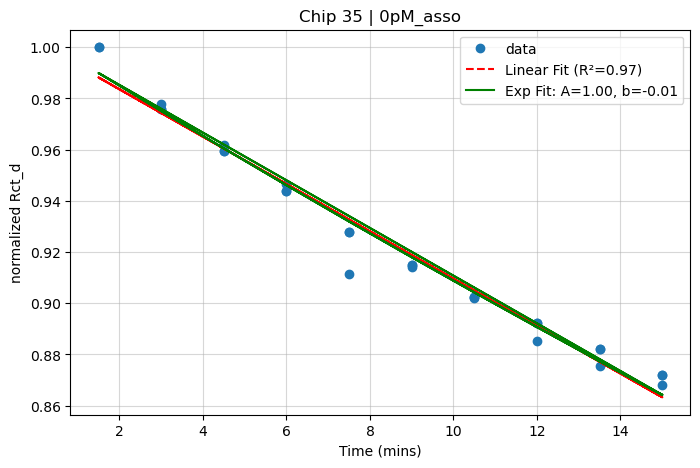

[0.93119065 0.89848642 0.90385038 0.87887948 0.88118654 0.87257484
 0.85833536 0.84242922 0.84378139 0.82551866 0.82396507 0.81886369
 0.81219545 0.80306447 0.7889441  0.78796125 0.77815804 0.77086493
 0.76250347 0.75592247 1.         0.93208036 0.91424668 0.90437465
 0.89333311 0.88470844 0.87447107 0.86578173 0.85696885 0.84776206
 0.8403158  0.83300811 0.82491119 0.8189489  0.8115417  0.80457253
 0.79786957 0.79182402 0.78493974 0.77830453 0.77243336 1.
 0.93208036 0.91424668 0.90437465 0.89333311 0.88470844 0.87447107
 0.86578173 0.85696885 0.84776206 0.8403158  0.83300811 0.82491119
 0.8189489  0.8115417  0.80457253 0.79786957 0.79182402 0.78493974
 0.77830453 0.77243336]  y
[0.93119065 0.89848642 0.90385038 0.87887948 0.88118654 0.87257484
 0.85833536 0.84242922 0.84378139 0.82551866 0.82396507 0.81886369
 0.81219545 0.80306447 0.7889441  0.78796125 0.77815804 0.77086493
 0.76250347 0.75592247 1.         0.93208036 0.91424668 0.90437465
 0.89333311 0.88470844 0.87447107 0.8657817

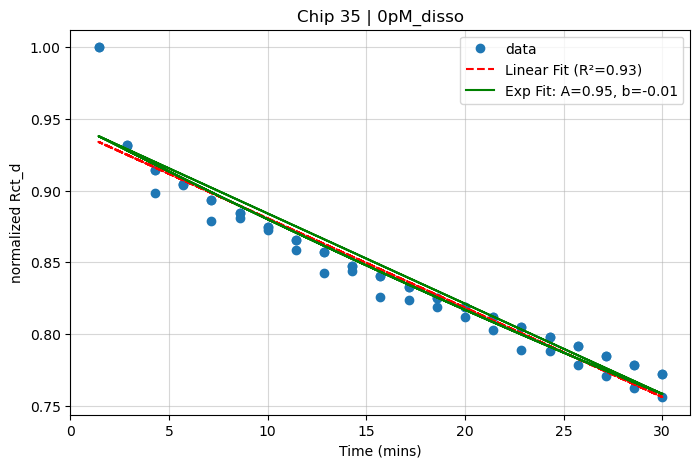

[0.85010606 0.8160831  0.79692271 0.77871717 0.75293926 0.75501464
 0.74822436 0.73327396 0.72862458 1.         0.84091205 0.82648158
 0.79495008 0.78325109 0.76935037 0.7615844  0.75175906 0.74230029
 0.73582441 1.         0.84091205 0.82648158 0.79495008 0.78325109
 0.76935037 0.7615844  0.75175906 0.74230029 0.73582441]  y
[0.85010606 0.8160831  0.79692271 0.77871717 0.75293926 0.75501464
 0.74822436 0.73327396 0.72862458 1.         0.84091205 0.82648158
 0.79495008 0.78325109 0.76935037 0.7615844  0.75175906 0.74230029
 0.73582441 1.         0.84091205 0.82648158 0.79495008 0.78325109
 0.76935037 0.7615844  0.75175906 0.74230029 0.73582441]  x


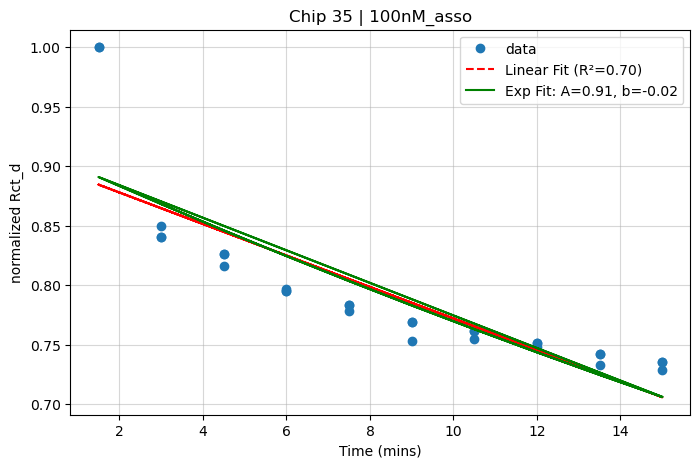

[0.92597755 0.90325213 0.89161564 0.88236577 0.86693659 0.85636032
 0.85033548 0.82873367 0.82830495 0.82189941 0.80969356 0.80060636
 0.79400633 0.7810872  0.77459502 0.76860529 0.76014518 0.75064102
 0.26775622 0.73580264 1.         0.92798187 0.90952244 0.89787654
 0.88806128 0.87587093 0.86736874 0.85596297 0.84695399 0.8382267
 0.8302654  0.82172487 0.81303097 0.80549762 0.79627873 0.78953612
 0.78231115 0.77528406 0.76731748 0.76161926 0.75350702 1.
 0.92798187 0.90952244 0.89787654 0.88806128 0.87587093 0.86736874
 0.85596297 0.84695399 0.8382267  0.8302654  0.82172487 0.81303097
 0.80549762 0.79627873 0.78953612 0.78231115 0.77528406 0.76731748
 0.76161926 0.75350702]  y
[0.92597755 0.90325213 0.89161564 0.88236577 0.86693659 0.85636032
 0.85033548 0.82873367 0.82830495 0.82189941 0.80969356 0.80060636
 0.79400633 0.7810872  0.77459502 0.76860529 0.76014518 0.75064102
 0.26775622 0.73580264 1.         0.92798187 0.90952244 0.89787654
 0.88806128 0.87587093 0.86736874 0.85596297

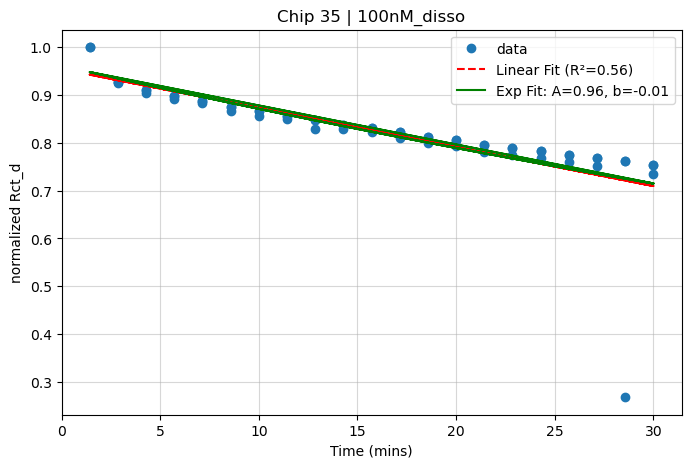

[0.86928864 0.83638543 0.82281257 0.81279947 0.80272852 0.7803732
 0.78135743 0.76742215 0.75927652 1.         0.85451892 0.82175228
 0.80755242 0.79724473 0.78772243 0.77828803 0.76827067 0.7603118
 0.7510339  1.         0.85451892 0.82175228 0.80755242 0.79724473
 0.78772243 0.77828803 0.76827067 0.7603118  0.7510339 ]  y
[0.86928864 0.83638543 0.82281257 0.81279947 0.80272852 0.7803732
 0.78135743 0.76742215 0.75927652 1.         0.85451892 0.82175228
 0.80755242 0.79724473 0.78772243 0.77828803 0.76827067 0.7603118
 0.7510339  1.         0.85451892 0.82175228 0.80755242 0.79724473
 0.78772243 0.77828803 0.76827067 0.7603118  0.7510339 ]  x


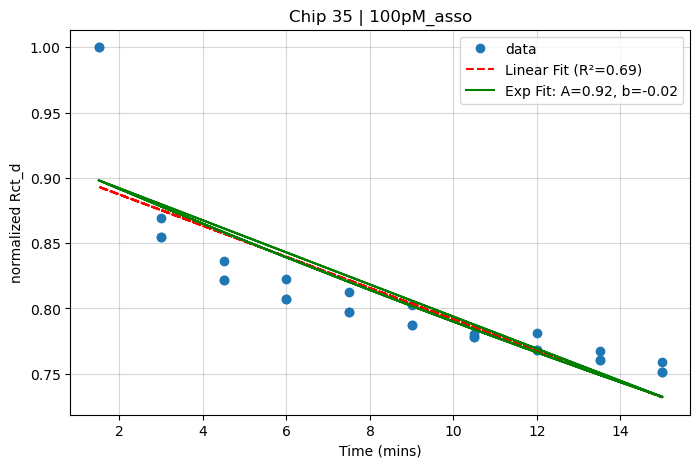

[0.95162779 0.93285117 0.92090065 0.91033403 0.89939934 0.88990603
 0.87967267 0.86661446 0.8573863  0.8430175  0.83746179 0.82997511
 0.81638824 0.81150794 0.79423108 0.79410238 0.78288062 0.77435095
 0.76706456 0.76043958 1.         0.93281444 0.91661336 0.90304327
 0.89207595 0.88184872 0.86857122 0.85889085 0.85092384 0.84216277
 0.83226281 0.82426738 0.81529023 0.80882003 0.80001514 0.79124034
 0.78510589 0.77761571 0.76979021 0.76233891 0.75712528 1.
 0.93281444 0.91661336 0.90304327 0.89207595 0.88184872 0.86857122
 0.85889085 0.85092384 0.84216277 0.83226281 0.82426738 0.81529023
 0.80882003 0.80001514 0.79124034 0.78510589 0.77761571 0.76979021
 0.76233891 0.75712528]  y
[0.95162779 0.93285117 0.92090065 0.91033403 0.89939934 0.88990603
 0.87967267 0.86661446 0.8573863  0.8430175  0.83746179 0.82997511
 0.81638824 0.81150794 0.79423108 0.79410238 0.78288062 0.77435095
 0.76706456 0.76043958 1.         0.93281444 0.91661336 0.90304327
 0.89207595 0.88184872 0.86857122 0.8588908

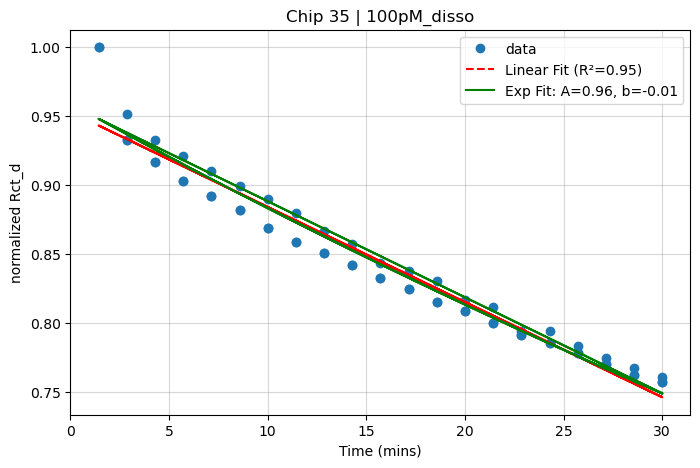

[0.86058197 0.82973915 0.81511679 0.8031154  0.7890901  0.77283521
 0.76538215 0.74993075 0.74439414 1.         0.84771001 0.81657821
 0.80228421 0.79075956 0.77962461 0.76846766 0.75845668 0.74926498
 0.73959052 1.         0.84771001 0.81657821 0.80228421 0.79075956
 0.77962461 0.76846766 0.75845668 0.74926498 0.73959052]  y
[0.86058197 0.82973915 0.81511679 0.8031154  0.7890901  0.77283521
 0.76538215 0.74993075 0.74439414 1.         0.84771001 0.81657821
 0.80228421 0.79075956 0.77962461 0.76846766 0.75845668 0.74926498
 0.73959052 1.         0.84771001 0.81657821 0.80228421 0.79075956
 0.77962461 0.76846766 0.75845668 0.74926498 0.73959052]  x


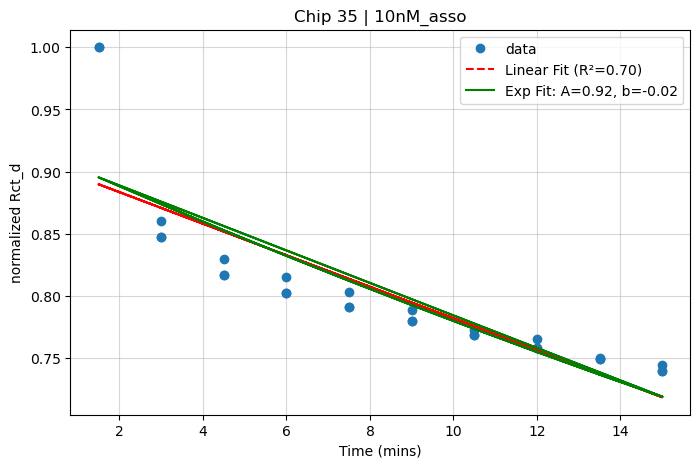

[0.94785878 0.93002509 0.91981276 0.91013777 0.9011291  0.88463809
 0.87890087 0.87120167 0.85633069 0.85148166 0.84445764 0.83167368
 0.82678924 0.81992109 0.80887331 0.80469767 0.79392025 0.78903574
 0.78050519 0.77042803 1.         0.93178541 0.91341258 0.90226481
 0.89296105 0.8829964  0.8738532  0.86356225 0.85652629 0.84822103
 0.84002653 0.8314053  0.82447198 0.81758962 0.81088544 0.80408502
 0.79689684 0.79080391 0.78320943 0.77704678 0.77203269 1.
 0.93178541 0.91341258 0.90226481 0.89296105 0.8829964  0.8738532
 0.86356225 0.85652629 0.84822103 0.84002653 0.8314053  0.82447198
 0.81758962 0.81088544 0.80408502 0.79689684 0.79080391 0.78320943
 0.77704678 0.77203269]  y
[0.94785878 0.93002509 0.91981276 0.91013777 0.9011291  0.88463809
 0.87890087 0.87120167 0.85633069 0.85148166 0.84445764 0.83167368
 0.82678924 0.81992109 0.80887331 0.80469767 0.79392025 0.78903574
 0.78050519 0.77042803 1.         0.93178541 0.91341258 0.90226481
 0.89296105 0.8829964  0.8738532  0.86356225

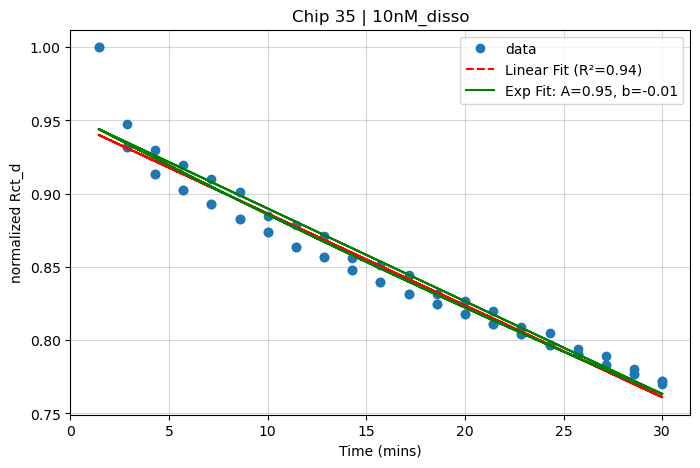

[0.86770124 0.82104726 0.82360587 0.81244077 0.78590954 0.7921996
 0.77862843 0.76377491 0.75487836 1.         0.85367255 0.82422289
 0.8099425  0.79824684 0.78717688 0.77676268 0.76582796 0.75706119
 0.74691459 1.         0.85367255 0.82422289 0.8099425  0.79824684
 0.78717688 0.77676268 0.76582796 0.75706119 0.74691459]  y
[0.86770124 0.82104726 0.82360587 0.81244077 0.78590954 0.7921996
 0.77862843 0.76377491 0.75487836 1.         0.85367255 0.82422289
 0.8099425  0.79824684 0.78717688 0.77676268 0.76582796 0.75706119
 0.74691459 1.         0.85367255 0.82422289 0.8099425  0.79824684
 0.78717688 0.77676268 0.76582796 0.75706119 0.74691459]  x


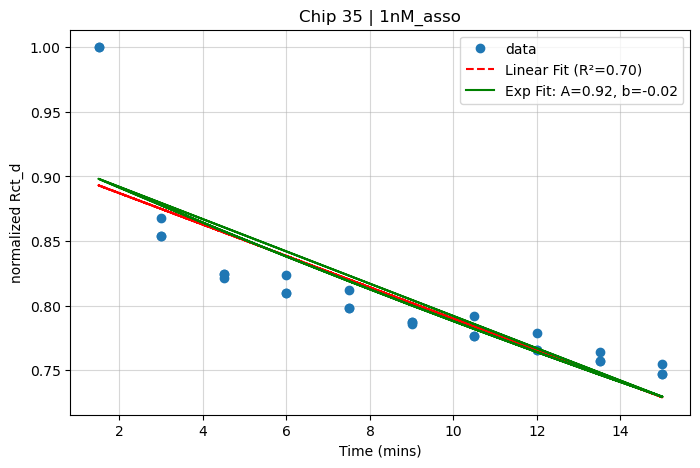

[0.95537384 0.93805585 0.92695421 0.91597071 0.90599685 0.89092129
 0.88092354 0.87049693 0.85590672 0.8498421  0.83995277 0.8293633
 0.81637318 0.80415564 0.7989476  0.79329339 0.78201316 0.7745152
 0.76656761 0.74520908 1.         0.9400627  0.92225939 0.91070009
 0.89982276 0.88952045 0.87813904 0.86741772 0.85698633 0.8486569
 0.83813532 0.82932998 0.81992357 0.81181038 0.80315678 0.7957
 0.78917691 0.78158899 0.77404144 0.76792185 0.75908126 1.
 0.9400627  0.92225939 0.91070009 0.89982276 0.88952045 0.87813904
 0.86741772 0.85698633 0.8486569  0.83813532 0.82932998 0.81992357
 0.81181038 0.80315678 0.7957     0.78917691 0.78158899 0.77404144
 0.76792185 0.75908126]  y
[0.95537384 0.93805585 0.92695421 0.91597071 0.90599685 0.89092129
 0.88092354 0.87049693 0.85590672 0.8498421  0.83995277 0.8293633
 0.81637318 0.80415564 0.7989476  0.79329339 0.78201316 0.7745152
 0.76656761 0.74520908 1.         0.9400627  0.92225939 0.91070009
 0.89982276 0.88952045 0.87813904 0.86741772 0.85698

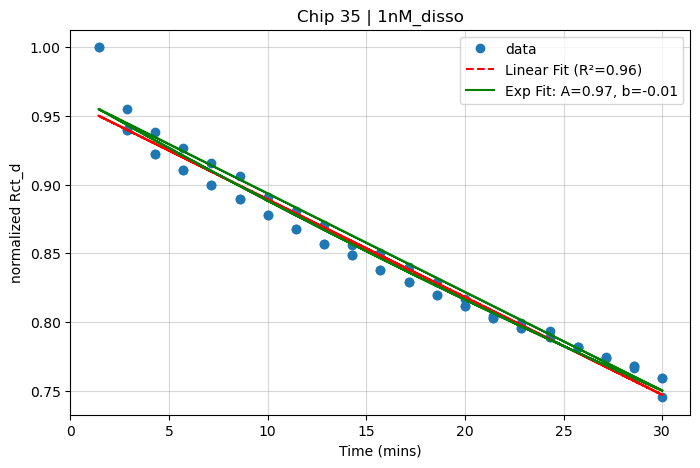

[0.97465751 0.95358421 0.93668785 0.92284842 0.90913382 0.89911315
 0.87750307 0.87221656 0.86482088 1.         0.97145546 0.95155599
 0.93621569 0.9218801  0.87962502 0.86798047 0.85668543 0.84512655
 0.83872522]  y
[0.97465751 0.95358421 0.93668785 0.92284842 0.90913382 0.89911315
 0.87750307 0.87221656 0.86482088 1.         0.97145546 0.95155599
 0.93621569 0.9218801  0.87962502 0.86798047 0.85668543 0.84512655
 0.83872522]  x


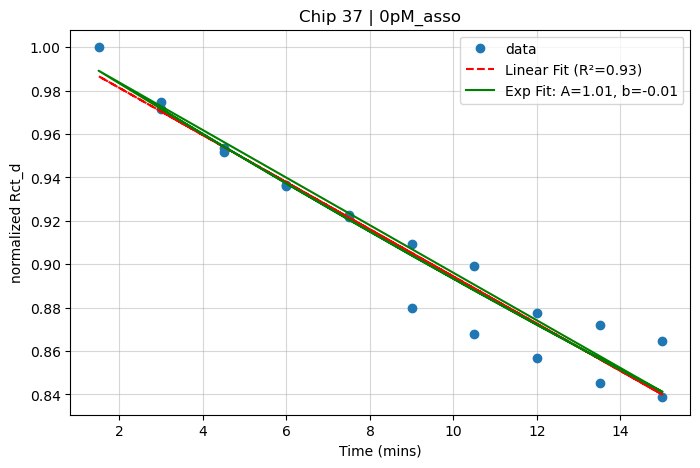

[0.97671417 0.96383714 0.95497121 0.93358288 0.93003147 0.92122765
 0.91351242 0.89534537 0.89153559 0.88373926 0.87673624 0.87201105
 0.85739567 0.84884521 0.84201545 0.83971984 0.82659874 0.80796643
 0.81690015 0.81194609 1.         0.97471069 0.96483171 0.95599916
 0.91386981 0.90573827 0.8957411  0.88703514 0.8782733  0.86956301
 0.86163833 0.85455336 0.84844378 0.84232257 0.83296833 0.82505478
 0.81948259 0.81369168 0.80551756 0.80015255 0.7955255 ]  y
[0.97671417 0.96383714 0.95497121 0.93358288 0.93003147 0.92122765
 0.91351242 0.89534537 0.89153559 0.88373926 0.87673624 0.87201105
 0.85739567 0.84884521 0.84201545 0.83971984 0.82659874 0.80796643
 0.81690015 0.81194609 1.         0.97471069 0.96483171 0.95599916
 0.91386981 0.90573827 0.8957411  0.88703514 0.8782733  0.86956301
 0.86163833 0.85455336 0.84844378 0.84232257 0.83296833 0.82505478
 0.81948259 0.81369168 0.80551756 0.80015255 0.7955255 ]  x


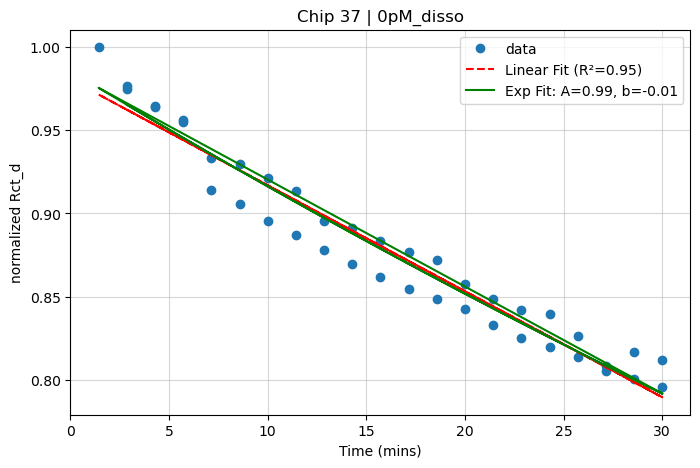

[0.91552376 0.88619165 0.87210627 0.8631007  0.85229564 0.82871698
 0.78576936 0.81662145 0.79531361 1.         0.94193814 0.91996388
 0.90085619 0.89654446 0.88919452 0.8460163  0.79934204 0.84767845
 0.81099065]  y
[0.91552376 0.88619165 0.87210627 0.8631007  0.85229564 0.82871698
 0.78576936 0.81662145 0.79531361 1.         0.94193814 0.91996388
 0.90085619 0.89654446 0.88919452 0.8460163  0.79934204 0.84767845
 0.81099065]  x


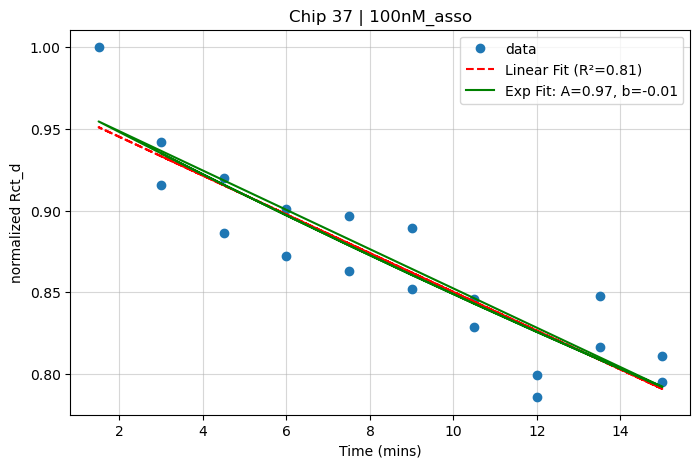

[0.92621893 0.90847684 0.89147154 0.88333778 0.87536438 0.86796016
 0.83236364 0.84280713 0.83993283 0.83334392 0.82658665 0.82006917
 0.81383914 0.78511322 0.79691331 0.79140489 0.78489281 0.772269
 0.77023919 0.76382217 1.         0.93230835 0.91612487 0.87284972
 0.86498873 0.85540866 0.8469289  0.83912404 0.83080918 0.82324679
 0.8176743  0.80914377 0.80247887 0.79592246 0.78781076 0.78272144
 0.77635285 0.77026677 0.76325117 0.75859028 0.75274933]  y
[0.92621893 0.90847684 0.89147154 0.88333778 0.87536438 0.86796016
 0.83236364 0.84280713 0.83993283 0.83334392 0.82658665 0.82006917
 0.81383914 0.78511322 0.79691331 0.79140489 0.78489281 0.772269
 0.77023919 0.76382217 1.         0.93230835 0.91612487 0.87284972
 0.86498873 0.85540866 0.8469289  0.83912404 0.83080918 0.82324679
 0.8176743  0.80914377 0.80247887 0.79592246 0.78781076 0.78272144
 0.77635285 0.77026677 0.76325117 0.75859028 0.75274933]  x


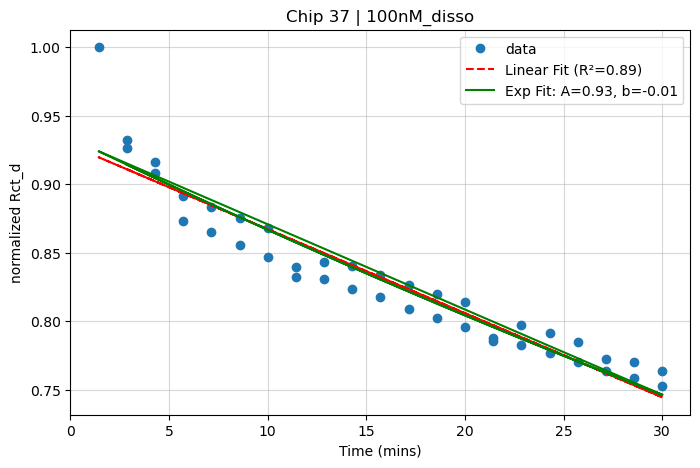

[0.86961307 0.83483544 0.79202929 0.81096916 0.79154934 0.78643082
 0.76940296 0.74658455 0.75634137 1.         0.86209808 0.82892302
 0.79234583 0.80689464 0.77364382 0.76348337 0.75350301 0.74415322
 0.73627072]  y
[0.86961307 0.83483544 0.79202929 0.81096916 0.79154934 0.78643082
 0.76940296 0.74658455 0.75634137 1.         0.86209808 0.82892302
 0.79234583 0.80689464 0.77364382 0.76348337 0.75350301 0.74415322
 0.73627072]  x


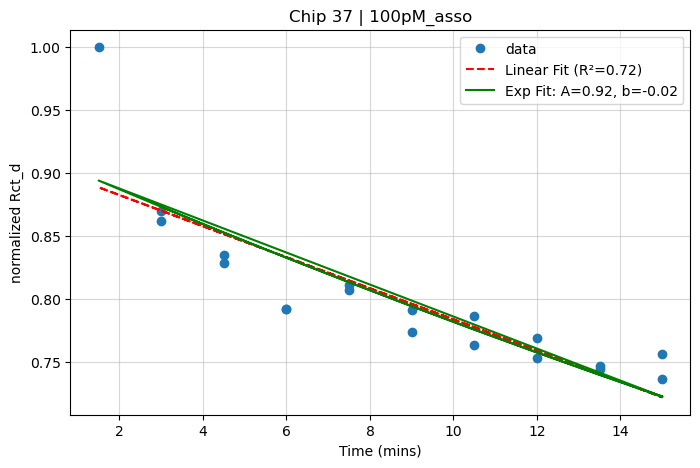

[0.98320839 0.96471279 0.95531668 0.94599764 0.93607775 0.92493233
 0.91471276 0.9055069  0.89692847 0.88745477 0.87921508 0.87178831
 0.86360097 0.8487509  0.83991233 0.83329    0.82686441 0.78327019
 0.80011668 0.79893397 1.         0.97449204 0.95672531 0.94762265
 0.93864895 0.9298225  0.91828587 0.90963215 0.90209817 0.89260039
 0.88510691 0.877775   0.87014357 0.86481393 0.80790314 0.79830362
 0.79216657 0.78624897 0.77719384 0.77098086 0.76408873]  y
[0.98320839 0.96471279 0.95531668 0.94599764 0.93607775 0.92493233
 0.91471276 0.9055069  0.89692847 0.88745477 0.87921508 0.87178831
 0.86360097 0.8487509  0.83991233 0.83329    0.82686441 0.78327019
 0.80011668 0.79893397 1.         0.97449204 0.95672531 0.94762265
 0.93864895 0.9298225  0.91828587 0.90963215 0.90209817 0.89260039
 0.88510691 0.877775   0.87014357 0.86481393 0.80790314 0.79830362
 0.79216657 0.78624897 0.77719384 0.77098086 0.76408873]  x


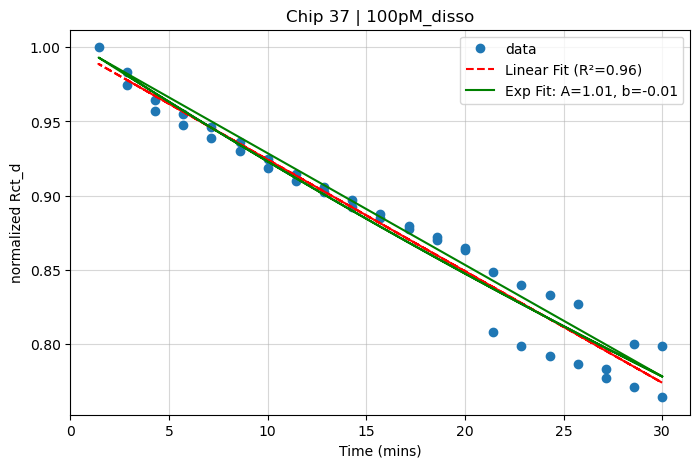

[0.8470561  0.84509168 0.83108533 0.82060842 0.81016696 0.76897891
 0.79174633 0.78311231 0.7743869  1.         0.84908522 0.84207403
 0.82867822 0.81945812 0.80973406 0.77131823 0.7917605  0.78409914
 0.77665815]  y
[0.8470561  0.84509168 0.83108533 0.82060842 0.81016696 0.76897891
 0.79174633 0.78311231 0.7743869  1.         0.84908522 0.84207403
 0.82867822 0.81945812 0.80973406 0.77131823 0.7917605  0.78409914
 0.77665815]  x


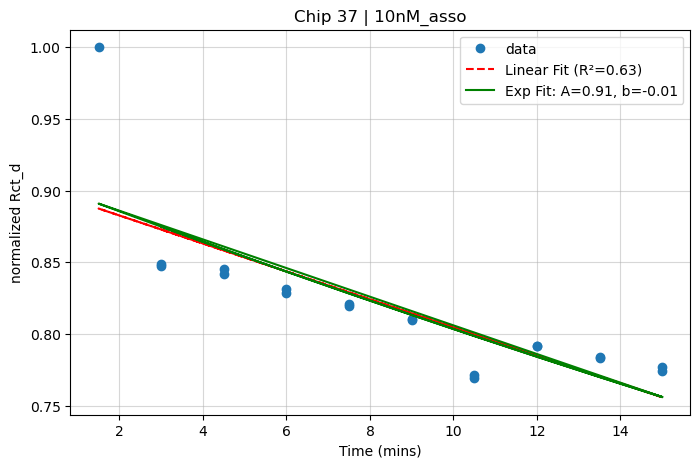

[0.96753788 0.94823224 0.93833029 0.92943398 0.9201678  0.91179368
 0.90453259 0.89612082 0.88927378 0.88205265 0.86385634 0.86767318
 0.85597405 0.82157625 0.84308551 0.83695232 0.82215158 0.81926685
 0.8141284  0.80795462 1.         0.96244795 0.94572994 0.93618367
 0.92796606 0.91898714 0.91122948 0.9038574  0.89638023 0.8892592
 0.88209807 0.83808692 0.86891276 0.82541563 0.81861248 0.81305679
 0.80559659 0.80103201 0.79412697 0.78906808 0.78369072]  y
[0.96753788 0.94823224 0.93833029 0.92943398 0.9201678  0.91179368
 0.90453259 0.89612082 0.88927378 0.88205265 0.86385634 0.86767318
 0.85597405 0.82157625 0.84308551 0.83695232 0.82215158 0.81926685
 0.8141284  0.80795462 1.         0.96244795 0.94572994 0.93618367
 0.92796606 0.91898714 0.91122948 0.9038574  0.89638023 0.8892592
 0.88209807 0.83808692 0.86891276 0.82541563 0.81861248 0.81305679
 0.80559659 0.80103201 0.79412697 0.78906808 0.78369072]  x


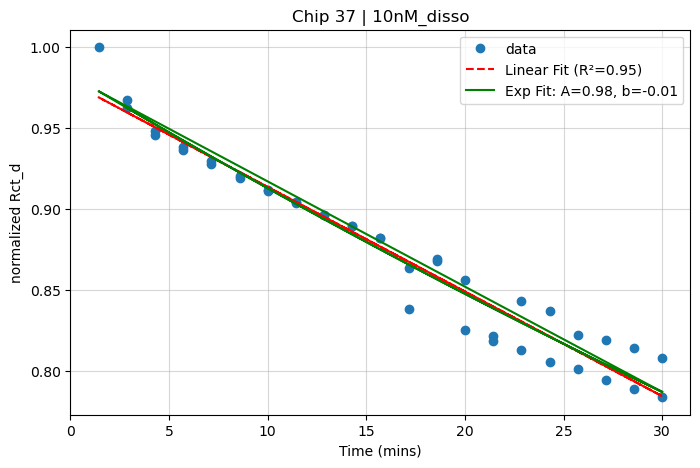

[0.83338759 0.82535141 0.80961959 0.80015528 0.79126116 0.78271759
 0.77315843 0.76493473 0.75673447 1.         0.82958928 0.81967173
 0.80476902 0.79638963 0.78813964 0.77957946 0.77095831 0.76386145
 0.72371782]  y
[0.83338759 0.82535141 0.80961959 0.80015528 0.79126116 0.78271759
 0.77315843 0.76493473 0.75673447 1.         0.82958928 0.81967173
 0.80476902 0.79638963 0.78813964 0.77957946 0.77095831 0.76386145
 0.72371782]  x


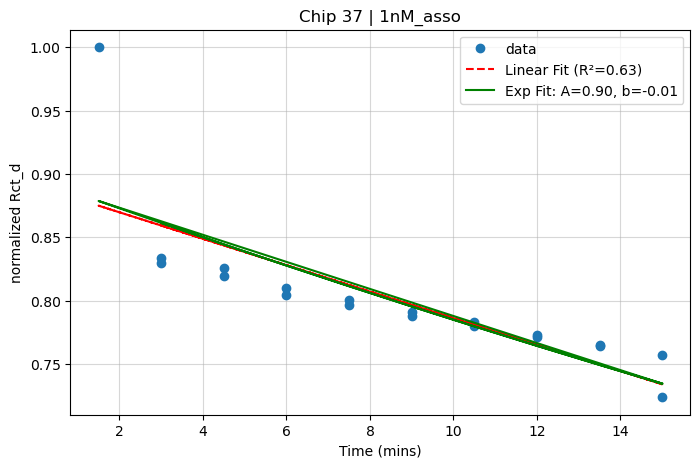

[0.97199502 0.95437765 0.94366528 0.93540102 0.92796361 0.91913798
 0.91087758 0.90354334 0.89581322 0.88853493 0.86932722 0.86738825
 0.86069638 0.85400709 0.84690282 0.81203233 0.82439855 0.82188101
 0.81563037 0.80874947 1.         0.96905024 0.95239983 0.94290459
 0.93509771 0.89487324 0.88444455 0.87731597 0.86827732 0.86113676
 0.85372313 0.84530464 0.8390888  0.83096075 0.82348259 0.81596544
 0.80846076 0.80311735 0.79598459 0.79039753 0.78399877]  y
[0.97199502 0.95437765 0.94366528 0.93540102 0.92796361 0.91913798
 0.91087758 0.90354334 0.89581322 0.88853493 0.86932722 0.86738825
 0.86069638 0.85400709 0.84690282 0.81203233 0.82439855 0.82188101
 0.81563037 0.80874947 1.         0.96905024 0.95239983 0.94290459
 0.93509771 0.89487324 0.88444455 0.87731597 0.86827732 0.86113676
 0.85372313 0.84530464 0.8390888  0.83096075 0.82348259 0.81596544
 0.80846076 0.80311735 0.79598459 0.79039753 0.78399877]  x


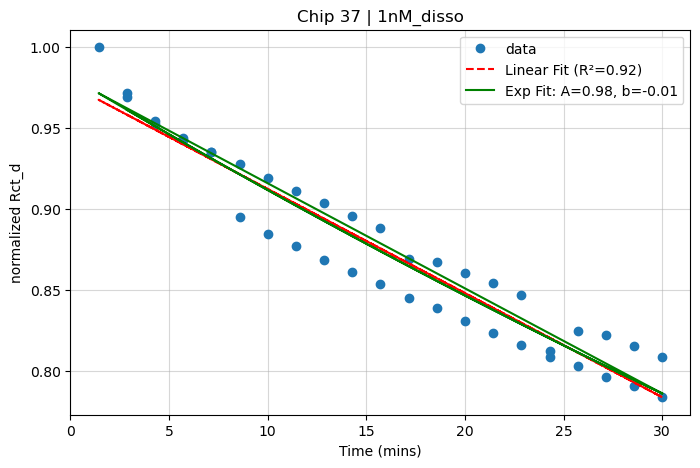

[0.9798026  1.00593148 0.951268   0.97964024 0.96812745 0.95553667
 0.94337429 0.93309182 0.92324628 1.         0.97783926 0.99145407
 0.94598507 0.96673491 0.95538462 0.94415941 0.93243196 0.92404112
 0.91559265]  y
[0.9798026  1.00593148 0.951268   0.97964024 0.96812745 0.95553667
 0.94337429 0.93309182 0.92324628 1.         0.97783926 0.99145407
 0.94598507 0.96673491 0.95538462 0.94415941 0.93243196 0.92404112
 0.91559265]  x


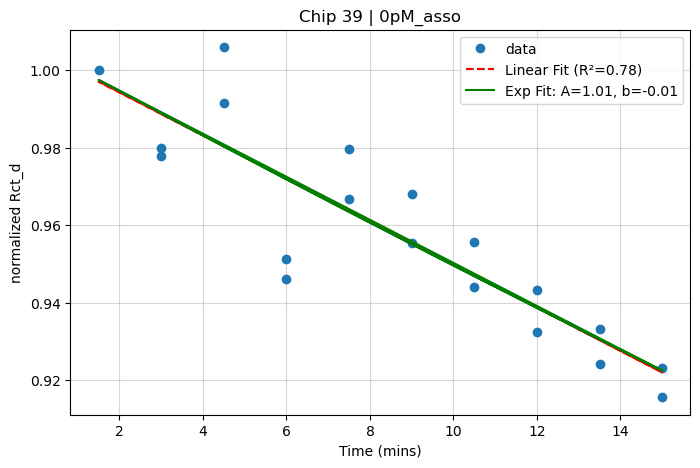

[0.94535716 0.96534331 0.92679385 0.94875798 0.93900192 0.92795136
 0.91790456 0.90853352 0.86711802 0.88978979 0.85105277 0.86079776
 0.8578275  0.84981428 0.84243728 0.80813831 0.81620383 0.80800187
 0.80342199 0.7755228  1.         0.9442154  0.95587323 0.92334552
 0.93905244 0.92943536 0.91903307 0.9090952  0.89890344 0.86158872
 0.88153349 0.84325294 0.83493849 0.82699304 0.81905061 0.81100121
 0.80093879 0.79249118 0.78468072 0.77563448 0.76643208]  y
[0.94535716 0.96534331 0.92679385 0.94875798 0.93900192 0.92795136
 0.91790456 0.90853352 0.86711802 0.88978979 0.85105277 0.86079776
 0.8578275  0.84981428 0.84243728 0.80813831 0.81620383 0.80800187
 0.80342199 0.7755228  1.         0.9442154  0.95587323 0.92334552
 0.93905244 0.92943536 0.91903307 0.9090952  0.89890344 0.86158872
 0.88153349 0.84325294 0.83493849 0.82699304 0.81905061 0.81100121
 0.80093879 0.79249118 0.78468072 0.77563448 0.76643208]  x


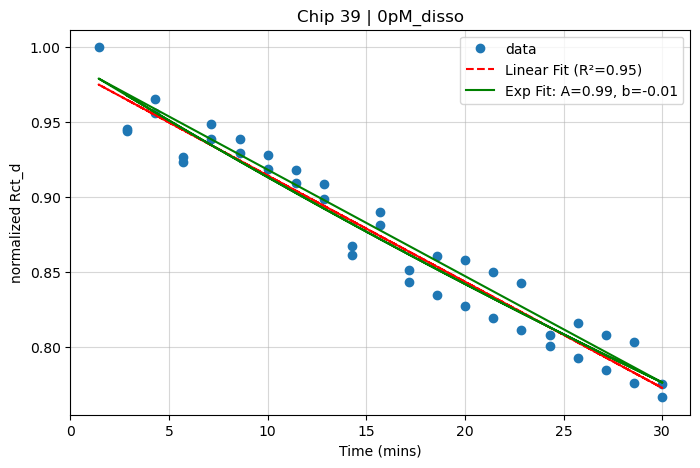

[0.83902775 0.8088867  0.84827499 0.83917663 0.77375855 0.82023026
 0.81165875 0.80278236 0.79531834 1.         0.83813318 0.80699303
 0.86727548 0.85157304 0.77178013 0.82603473 0.85463909 0.84142342
 0.828977  ]  y
[0.83902775 0.8088867  0.84827499 0.83917663 0.77375855 0.82023026
 0.81165875 0.80278236 0.79531834 1.         0.83813318 0.80699303
 0.86727548 0.85157304 0.77178013 0.82603473 0.85463909 0.84142342
 0.828977  ]  x


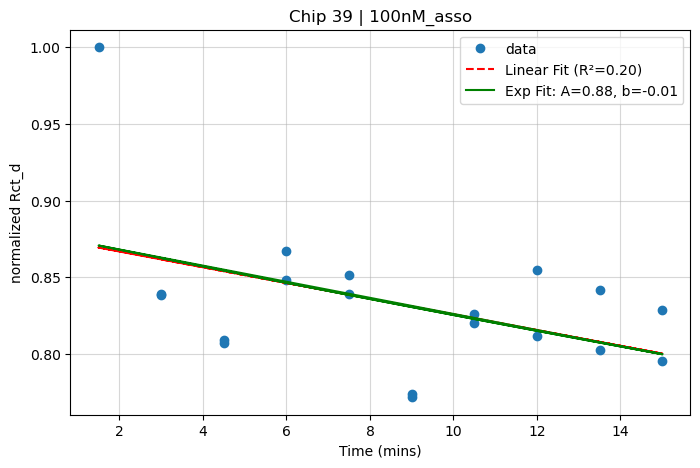

[0.96769925 0.94914587 0.93702049 0.92689147 0.88755453 0.87732741
 0.89606163 0.88643808 0.86613722 0.86934274 0.85367685 0.82218425
 0.81372985 0.80556364 0.81160011 0.78767227 0.78014169 0.79122675
 0.77423226 0.77060078 1.         0.96144397 0.94331857 0.93269513
 0.92160213 0.88189681 0.87176439 0.88006946 0.87107973 0.84303239
 0.85404523 0.82525159 0.81634279 0.80711646 0.79966789 0.79120819
 0.78262644 0.77486302 0.76625982 0.75670264 0.74971406]  y
[0.96769925 0.94914587 0.93702049 0.92689147 0.88755453 0.87732741
 0.89606163 0.88643808 0.86613722 0.86934274 0.85367685 0.82218425
 0.81372985 0.80556364 0.81160011 0.78767227 0.78014169 0.79122675
 0.77423226 0.77060078 1.         0.96144397 0.94331857 0.93269513
 0.92160213 0.88189681 0.87176439 0.88006946 0.87107973 0.84303239
 0.85404523 0.82525159 0.81634279 0.80711646 0.79966789 0.79120819
 0.78262644 0.77486302 0.76625982 0.75670264 0.74971406]  x


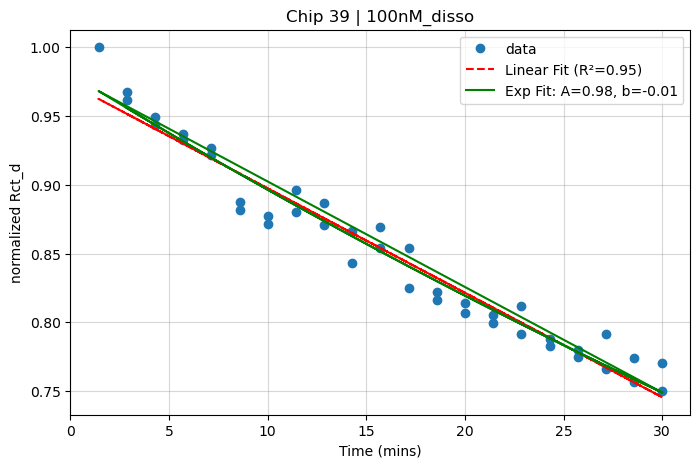

[0.87501184 0.84168749 0.83025495 0.85221625 0.84062881 0.83005289
 0.78159065 0.80871068 0.79924826 1.         0.87375011 0.8393524
 0.82720875 0.84179634 0.8306565  0.82150932 0.77866956 0.80032625
 0.79163473]  y
[0.87501184 0.84168749 0.83025495 0.85221625 0.84062881 0.83005289
 0.78159065 0.80871068 0.79924826 1.         0.87375011 0.8393524
 0.82720875 0.84179634 0.8306565  0.82150932 0.77866956 0.80032625
 0.79163473]  x


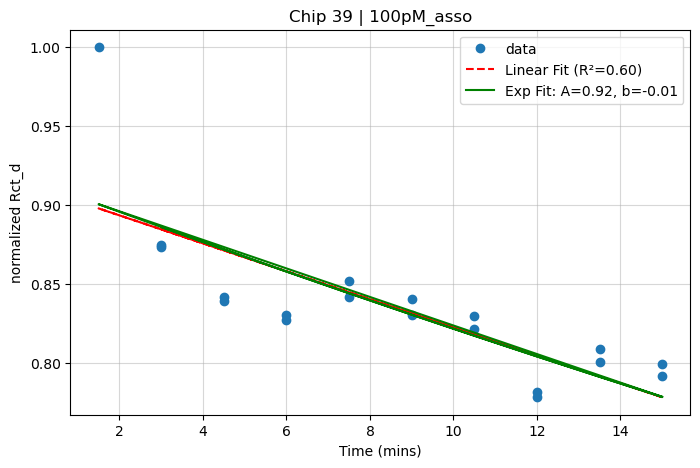

[0.97828575 0.93346725 0.95128216 0.94086246 0.93093254 0.92074599
 0.91128558 0.90183236 0.89279042 0.88358656 0.87386771 0.85297789
 0.84876639 0.83996312 0.83171757 0.81430746 0.80622306 0.79779909
 0.79405761 0.78574521 1.         0.97176786 0.9306501  0.94581782
 0.9350417  0.91461767 0.90483633 0.89462978 0.88584797 0.87599744
 0.86739451 0.85783682 0.82855913 0.81985302 0.81078875 0.80184115
 0.79342427 0.78485382 0.77693119 0.7686007  0.75983414]  y
[0.97828575 0.93346725 0.95128216 0.94086246 0.93093254 0.92074599
 0.91128558 0.90183236 0.89279042 0.88358656 0.87386771 0.85297789
 0.84876639 0.83996312 0.83171757 0.81430746 0.80622306 0.79779909
 0.79405761 0.78574521 1.         0.97176786 0.9306501  0.94581782
 0.9350417  0.91461767 0.90483633 0.89462978 0.88584797 0.87599744
 0.86739451 0.85783682 0.82855913 0.81985302 0.81078875 0.80184115
 0.79342427 0.78485382 0.77693119 0.7686007  0.75983414]  x


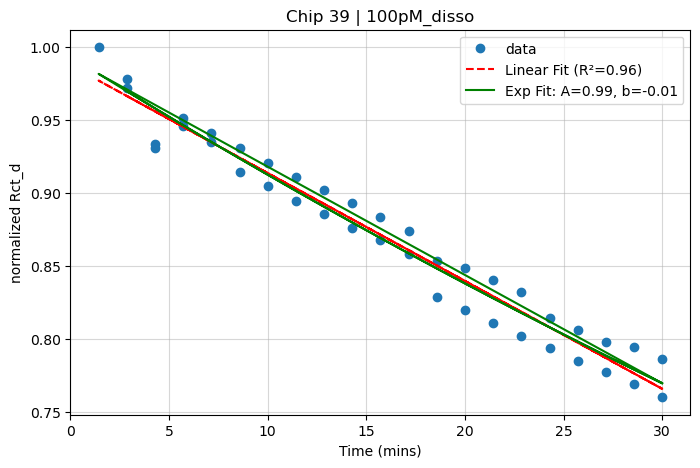

[0.84662892 0.81324119 0.83772917 0.79119846 0.81943792 0.77159692
 0.76204377 0.79238982 0.78366187 1.         0.84414831 0.81261182
 0.83189277 0.78843827 0.81493417 0.76918815 0.75956057 0.79132829
 0.78668862]  y
[0.84662892 0.81324119 0.83772917 0.79119846 0.81943792 0.77159692
 0.76204377 0.79238982 0.78366187 1.         0.84414831 0.81261182
 0.83189277 0.78843827 0.81493417 0.76918815 0.75956057 0.79132829
 0.78668862]  x


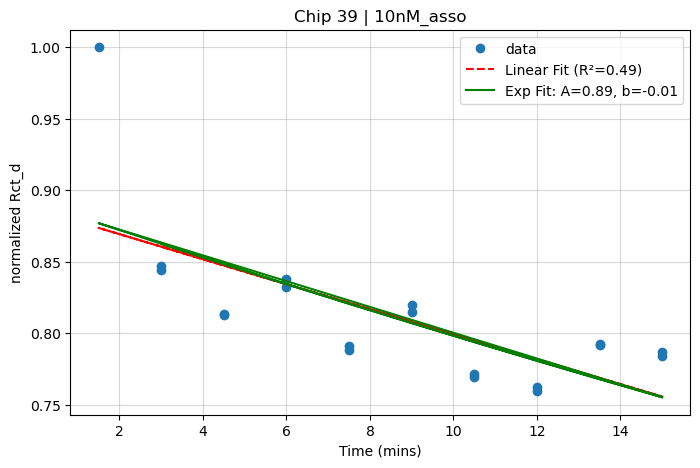

[0.98370114 0.96751383 0.95548492 0.94435831 0.90504063 0.9251941
 0.88652261 0.90710859 0.89805538 0.88907404 0.8723285  0.86270748
 0.85421593 0.82301619 0.82527216 0.82253807 0.79375079 0.79643461
 0.77475533 0.77604154 1.         0.97891391 0.96276481 0.95178857
 0.94133767 0.90187674 0.91067762 0.8822338  0.89224438 0.88348138
 0.8744651  0.84451388 0.83417377 0.8255749  0.81728749 0.80675445
 0.7988468  0.78846102 0.78020829 0.76995879 0.76242441]  y
[0.98370114 0.96751383 0.95548492 0.94435831 0.90504063 0.9251941
 0.88652261 0.90710859 0.89805538 0.88907404 0.8723285  0.86270748
 0.85421593 0.82301619 0.82527216 0.82253807 0.79375079 0.79643461
 0.77475533 0.77604154 1.         0.97891391 0.96276481 0.95178857
 0.94133767 0.90187674 0.91067762 0.8822338  0.89224438 0.88348138
 0.8744651  0.84451388 0.83417377 0.8255749  0.81728749 0.80675445
 0.7988468  0.78846102 0.78020829 0.76995879 0.76242441]  x


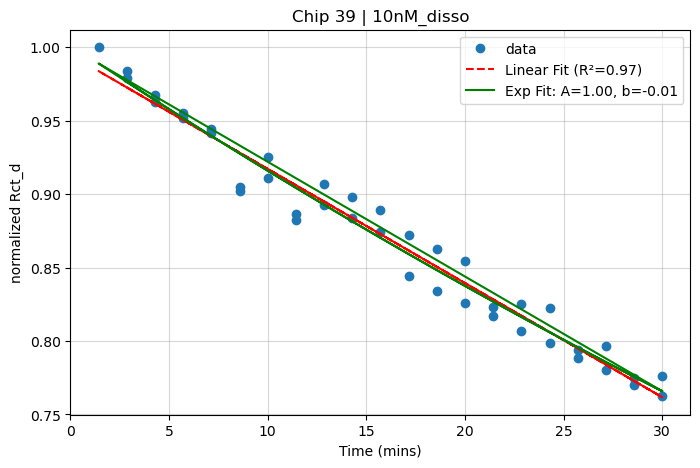

[0.80546244 0.79733039 0.78298283 0.77345241 0.76461545 0.75497626
 0.74615667 0.70401428 0.72847295 1.         0.80041606 0.78774041
 0.7755781  0.76586101 0.75870227 0.7497674  0.74257896 0.70043399
 0.72507109]  y
[0.80546244 0.79733039 0.78298283 0.77345241 0.76461545 0.75497626
 0.74615667 0.70401428 0.72847295 1.         0.80041606 0.78774041
 0.7755781  0.76586101 0.75870227 0.7497674  0.74257896 0.70043399
 0.72507109]  x


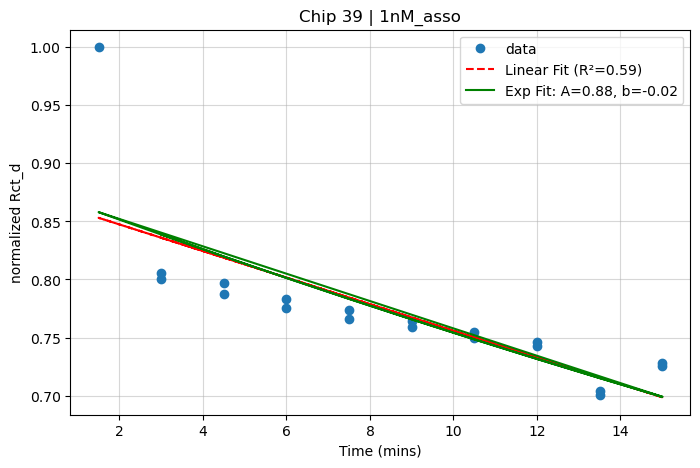

[0.97332541 0.92665192 0.94383939 0.90477302 0.92198931 0.91122418
 0.90207145 0.86275991 0.88381713 0.87462928 0.86659005 0.8579508
 0.84992203 0.83003167 0.82693772 0.81897858 0.78653379 0.78020549
 0.77264584 0.78240531 1.         0.96684149 0.92284889 0.93786582
 0.89991842 0.90571845 0.89444533 0.88582443 0.85673789 0.86712725
 0.85838978 0.85027626 0.84225307 0.83410056 0.80451992 0.79696443
 0.78832628 0.78040676 0.77227508 0.76471777 0.75609386]  y
[0.97332541 0.92665192 0.94383939 0.90477302 0.92198931 0.91122418
 0.90207145 0.86275991 0.88381713 0.87462928 0.86659005 0.8579508
 0.84992203 0.83003167 0.82693772 0.81897858 0.78653379 0.78020549
 0.77264584 0.78240531 1.         0.96684149 0.92284889 0.93786582
 0.89991842 0.90571845 0.89444533 0.88582443 0.85673789 0.86712725
 0.85838978 0.85027626 0.84225307 0.83410056 0.80451992 0.79696443
 0.78832628 0.78040676 0.77227508 0.76471777 0.75609386]  x


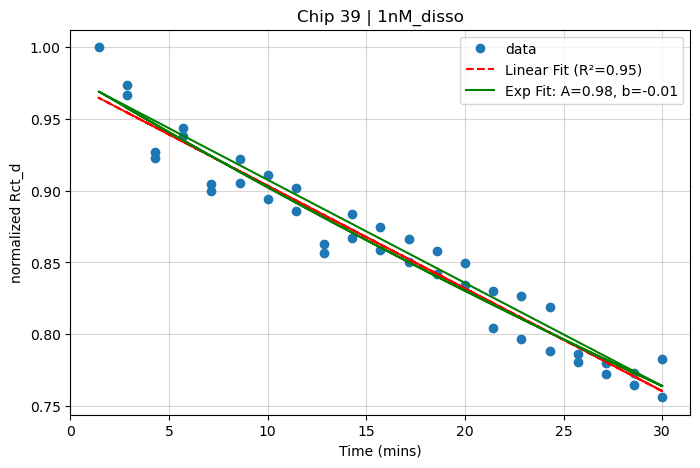

[0.97684598 0.94843639 0.93052092 0.91294565 0.89881881 0.88721981
 0.87527835 0.86820688 0.86015052 1.         0.96753471 0.93476008
 0.91281034 0.89557302 0.87989391 0.86721332 0.85579551 0.84633015
 0.83728612]  y
[0.97684598 0.94843639 0.93052092 0.91294565 0.89881881 0.88721981
 0.87527835 0.86820688 0.86015052 1.         0.96753471 0.93476008
 0.91281034 0.89557302 0.87989391 0.86721332 0.85579551 0.84633015
 0.83728612]  x


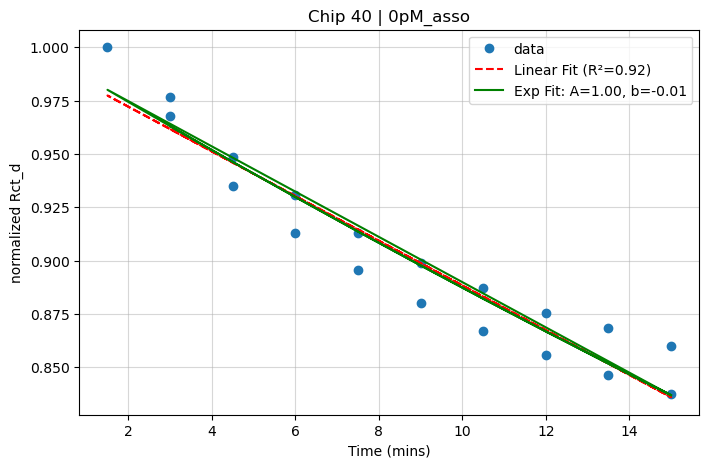

[0.99194252 0.98214505 0.97222566 0.96718304 0.95319074 0.94437317
 0.93548637 0.9272635  0.91764033 0.90991008 0.90041944 0.89642466
 0.88736429 0.88080705 0.87392107 0.86558941 0.8571179  0.85293024
 0.93325613 0.84412812 1.         0.98925623 0.9795574  0.96924459
 0.96002415 0.94924096 0.93988033 0.92949746 0.9201027  0.91063824
 0.90163087 0.89305517 0.88521402 0.87654261 0.86944369 0.86271119
 0.8554176  0.84806231 0.84259882 0.99187595 0.83005097]  y
[0.99194252 0.98214505 0.97222566 0.96718304 0.95319074 0.94437317
 0.93548637 0.9272635  0.91764033 0.90991008 0.90041944 0.89642466
 0.88736429 0.88080705 0.87392107 0.86558941 0.8571179  0.85293024
 0.93325613 0.84412812 1.         0.98925623 0.9795574  0.96924459
 0.96002415 0.94924096 0.93988033 0.92949746 0.9201027  0.91063824
 0.90163087 0.89305517 0.88521402 0.87654261 0.86944369 0.86271119
 0.8554176  0.84806231 0.84259882 0.99187595 0.83005097]  x


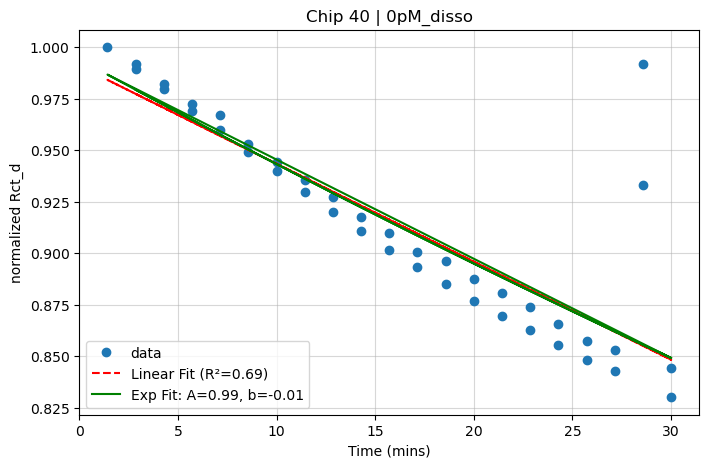

[0.82446031 0.78487603 0.76611925 0.75685442 0.74704911 0.7358157
 0.72823597 0.71939367 0.70633324 1.         0.81402951 0.77528871
 0.75727072 0.74569589 0.73409756 0.72337595 0.71280605 0.70264434
 0.69277319]  y
[0.82446031 0.78487603 0.76611925 0.75685442 0.74704911 0.7358157
 0.72823597 0.71939367 0.70633324 1.         0.81402951 0.77528871
 0.75727072 0.74569589 0.73409756 0.72337595 0.71280605 0.70264434
 0.69277319]  x


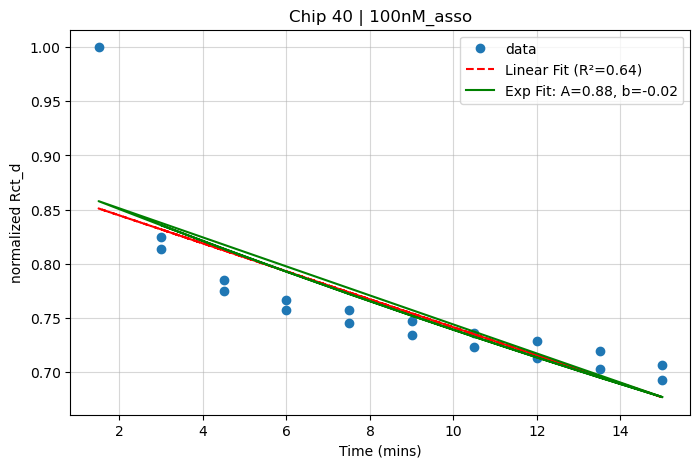

[0.93066361 0.91723208 0.90500591 0.89487087 0.88686283 0.87920647
 0.87143745 0.86695402 0.86009013 0.85023205 0.84519689 0.83726553
 0.83150411 0.82507635 0.81944605 0.81692701 0.80914854 0.80306885
 0.79503176 0.78882081 1.         0.92949152 0.91126741 0.89950975
 0.89064257 0.88137569 0.87359466 0.86453362 0.8587181  0.85078127
 0.84286038 0.83690773 0.83008195 0.82321012 0.81734597 0.81094744
 0.80465146 0.79745328 0.79214008 0.78448715 0.77775924]  y
[0.93066361 0.91723208 0.90500591 0.89487087 0.88686283 0.87920647
 0.87143745 0.86695402 0.86009013 0.85023205 0.84519689 0.83726553
 0.83150411 0.82507635 0.81944605 0.81692701 0.80914854 0.80306885
 0.79503176 0.78882081 1.         0.92949152 0.91126741 0.89950975
 0.89064257 0.88137569 0.87359466 0.86453362 0.8587181  0.85078127
 0.84286038 0.83690773 0.83008195 0.82321012 0.81734597 0.81094744
 0.80465146 0.79745328 0.79214008 0.78448715 0.77775924]  x


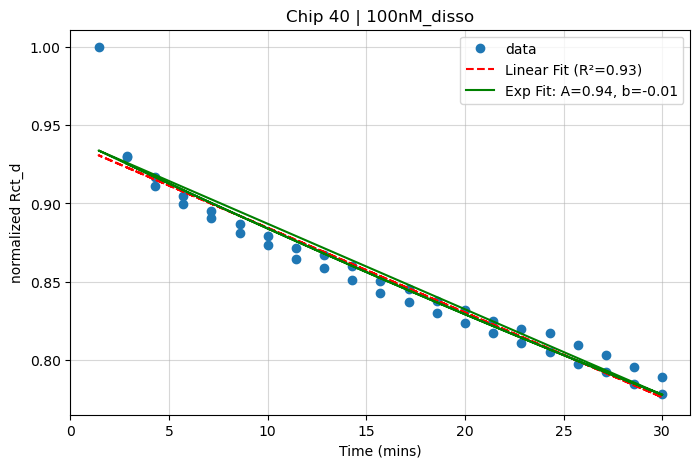

[0.84737045 0.81320786 0.7994069  0.78768015 0.78212889 0.77125703
 0.75941194 0.75444412 0.74431861 1.         0.84737045 0.80597766
 0.78915752 0.77704647 0.76699908 0.75651546 0.74681603 0.73825922
 0.72842143]  y
[0.84737045 0.81320786 0.7994069  0.78768015 0.78212889 0.77125703
 0.75941194 0.75444412 0.74431861 1.         0.84737045 0.80597766
 0.78915752 0.77704647 0.76699908 0.75651546 0.74681603 0.73825922
 0.72842143]  x


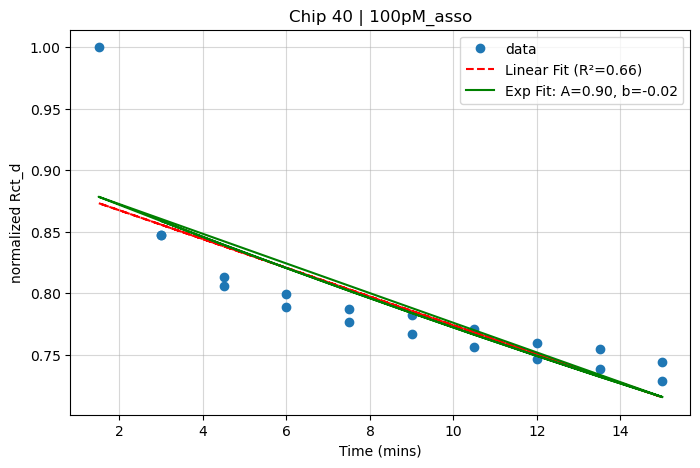

[0.98303135 0.97319452 0.95017209 0.93592416 0.92655368 0.91322785
 0.89912313 0.88860719 0.87624124 0.86764095 0.85912938 0.85402765
 0.84453599 0.83592317 0.83234843 0.82213858 0.81814572 0.80904371
 0.80570092 0.80450771 1.         0.98208995 0.96514474 0.94545066
 0.92921712 0.91281305 0.89828235 0.88430403 0.87243698 0.86124304
 0.85161862 0.84218625 0.83535046 0.82672777 0.81925851 0.81324416
 0.80661987 0.80048487 0.79508542 0.78883828 0.78308238]  y
[0.98303135 0.97319452 0.95017209 0.93592416 0.92655368 0.91322785
 0.89912313 0.88860719 0.87624124 0.86764095 0.85912938 0.85402765
 0.84453599 0.83592317 0.83234843 0.82213858 0.81814572 0.80904371
 0.80570092 0.80450771 1.         0.98208995 0.96514474 0.94545066
 0.92921712 0.91281305 0.89828235 0.88430403 0.87243698 0.86124304
 0.85161862 0.84218625 0.83535046 0.82672777 0.81925851 0.81324416
 0.80661987 0.80048487 0.79508542 0.78883828 0.78308238]  x


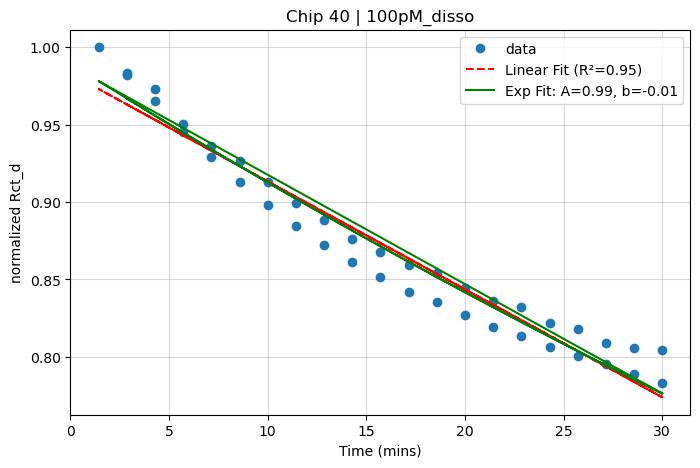

[0.83340816 0.79514859 0.7779457  0.76609732 0.75720644 0.74627401
 0.73353084 0.72589765 0.71676143 1.         0.82677644 0.7844806
 0.76587721 0.75283488 0.74175089 0.72994985 0.71906028 0.70859407
 0.69951225]  y
[0.83340816 0.79514859 0.7779457  0.76609732 0.75720644 0.74627401
 0.73353084 0.72589765 0.71676143 1.         0.82677644 0.7844806
 0.76587721 0.75283488 0.74175089 0.72994985 0.71906028 0.70859407
 0.69951225]  x


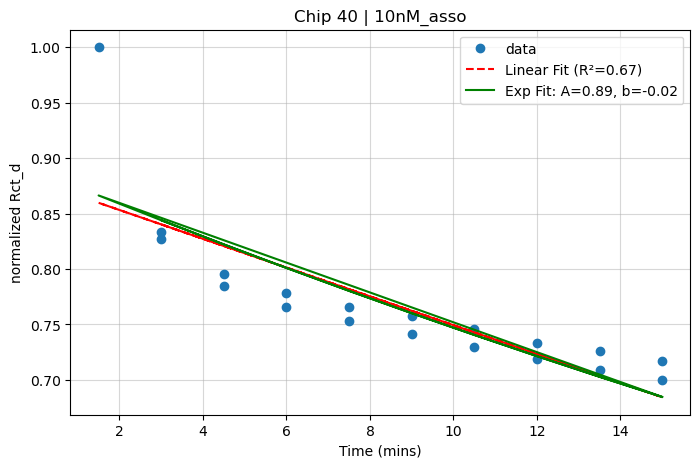

[0.93579785 0.92074653 0.90673496 0.90103814 0.88810628 0.8794025
 0.87073075 0.86282139 0.85428522 0.8452819  0.84129951 0.83224346
 0.82323435 0.81469871 0.81006679 0.80136055 0.79811498 0.8687783
 0.861083   0.77577475 1.         0.92610953 0.90793849 0.8961467
 0.88555422 0.87599561 0.86579235 0.85639008 0.84843618 0.83875157
 0.83117311 0.82341427 0.81558258 0.80756142 0.79969903 0.79371879
 0.78604124 0.77923859 0.92017549 0.91674607 0.75774127]  y
[0.93579785 0.92074653 0.90673496 0.90103814 0.88810628 0.8794025
 0.87073075 0.86282139 0.85428522 0.8452819  0.84129951 0.83224346
 0.82323435 0.81469871 0.81006679 0.80136055 0.79811498 0.8687783
 0.861083   0.77577475 1.         0.92610953 0.90793849 0.8961467
 0.88555422 0.87599561 0.86579235 0.85639008 0.84843618 0.83875157
 0.83117311 0.82341427 0.81558258 0.80756142 0.79969903 0.79371879
 0.78604124 0.77923859 0.92017549 0.91674607 0.75774127]  x


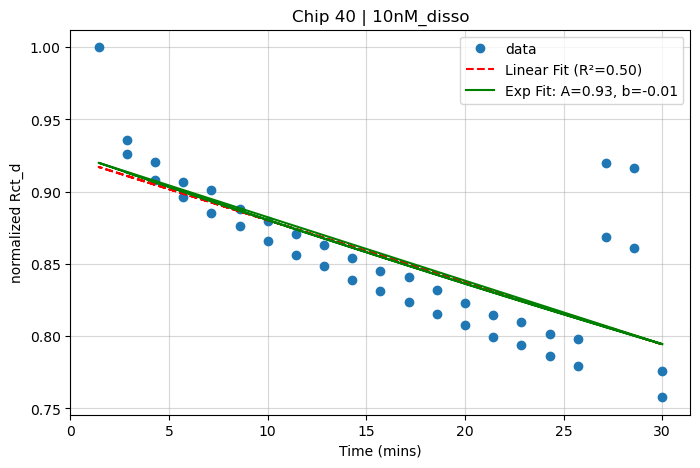

[0.80002294 0.75935205 0.7448153  0.73582265 0.72860143 0.72046851
 0.70888572 0.70217252 0.69424068 1.         0.80002294 0.75179251
 0.73507223 0.72441274 0.71496605 0.70542976 0.6956525  0.68667906
 0.67854046]  y
[0.80002294 0.75935205 0.7448153  0.73582265 0.72860143 0.72046851
 0.70888572 0.70217252 0.69424068 1.         0.80002294 0.75179251
 0.73507223 0.72441274 0.71496605 0.70542976 0.6956525  0.68667906
 0.67854046]  x


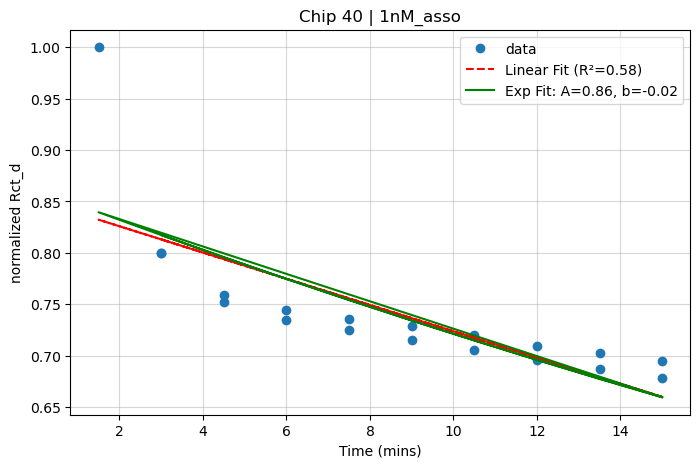

[0.971968   0.96007439 0.94939966 0.93636273 0.92664445 0.91490874
 0.90537235 0.89648911 0.89176101 0.88111543 0.87624703 0.8680073
 0.85938994 0.85610968 0.84919293 0.83816102 0.83207519 0.82879942
 0.82271808 0.81648009 1.         0.971968   0.96007439 0.94185868
 0.92573822 0.91269399 0.90016739 0.88916338 0.87910771 0.87038871
 0.86113721 0.85392265 0.84646141 0.83856704 0.83288245 0.82529842
 0.81711852 0.80973635 0.8050563  0.79874897 0.7915779 ]  y
[0.971968   0.96007439 0.94939966 0.93636273 0.92664445 0.91490874
 0.90537235 0.89648911 0.89176101 0.88111543 0.87624703 0.8680073
 0.85938994 0.85610968 0.84919293 0.83816102 0.83207519 0.82879942
 0.82271808 0.81648009 1.         0.971968   0.96007439 0.94185868
 0.92573822 0.91269399 0.90016739 0.88916338 0.87910771 0.87038871
 0.86113721 0.85392265 0.84646141 0.83856704 0.83288245 0.82529842
 0.81711852 0.80973635 0.8050563  0.79874897 0.7915779 ]  x


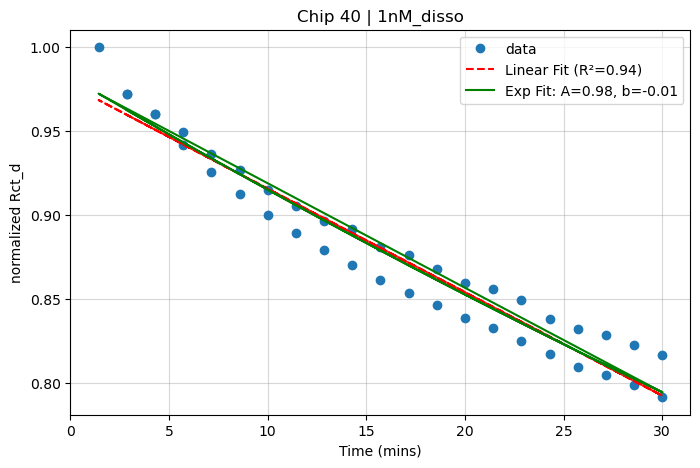

[0.94847594 0.92871332 0.91247497 0.89857473 0.88748662 0.87776134
 0.86945101 0.85848675 0.85032057 1.         0.94910703 0.9283067
 0.9109909  0.89822464 0.88671034 0.87604575 0.86582353 0.85668456
 0.84725999]  y
[0.94847594 0.92871332 0.91247497 0.89857473 0.88748662 0.87776134
 0.86945101 0.85848675 0.85032057 1.         0.94910703 0.9283067
 0.9109909  0.89822464 0.88671034 0.87604575 0.86582353 0.85668456
 0.84725999]  x


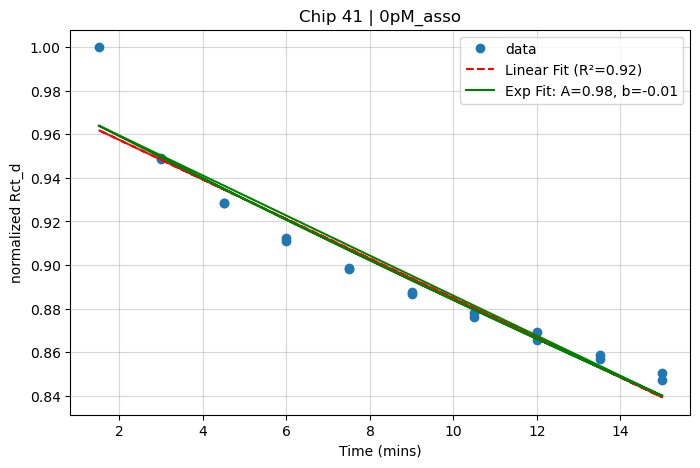

[0.93822971 0.91773005 0.90535395 0.89418394 0.88955303 0.87693822
 0.87141031 0.86512735 0.8544194  0.84948343 0.84149475 0.83604098
 0.86428123 0.82369897 0.85250112 0.84604352 0.84029078 0.79662925
 0.82773648 0.78487238 1.         0.93827552 0.9191728  0.90542936
 0.89533404 0.88693665 0.87754788 0.87040415 0.86117978 0.85402041
 0.84684618 0.83894304 0.83406619 0.82636997 0.82001363 0.81270604
 0.8067156  0.80033735 0.794026   0.78675202 0.78170062]  y
[0.93822971 0.91773005 0.90535395 0.89418394 0.88955303 0.87693822
 0.87141031 0.86512735 0.8544194  0.84948343 0.84149475 0.83604098
 0.86428123 0.82369897 0.85250112 0.84604352 0.84029078 0.79662925
 0.82773648 0.78487238 1.         0.93827552 0.9191728  0.90542936
 0.89533404 0.88693665 0.87754788 0.87040415 0.86117978 0.85402041
 0.84684618 0.83894304 0.83406619 0.82636997 0.82001363 0.81270604
 0.8067156  0.80033735 0.794026   0.78675202 0.78170062]  x


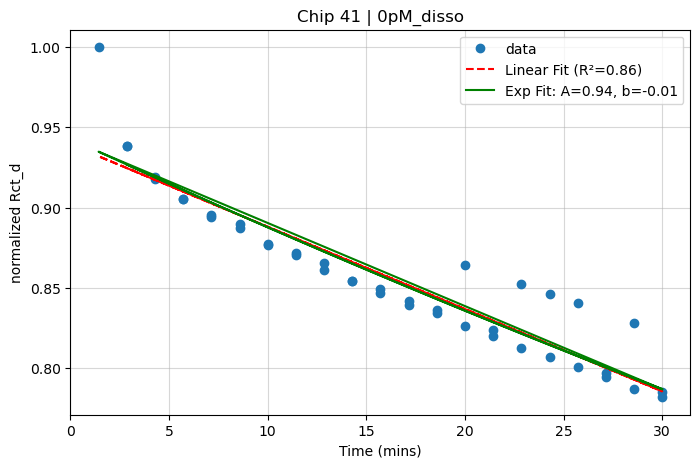

[0.80728313 0.77251435 0.75692704 0.74532208 0.73642348 0.7685236
 0.71625872 0.71090588 0.69925942 1.         0.81433577 0.77901613
 0.76466248 0.75335153 0.74252983 0.76787641 0.72416995 0.7157832
 0.70621122]  y
[0.80728313 0.77251435 0.75692704 0.74532208 0.73642348 0.7685236
 0.71625872 0.71090588 0.69925942 1.         0.81433577 0.77901613
 0.76466248 0.75335153 0.74252983 0.76787641 0.72416995 0.7157832
 0.70621122]  x


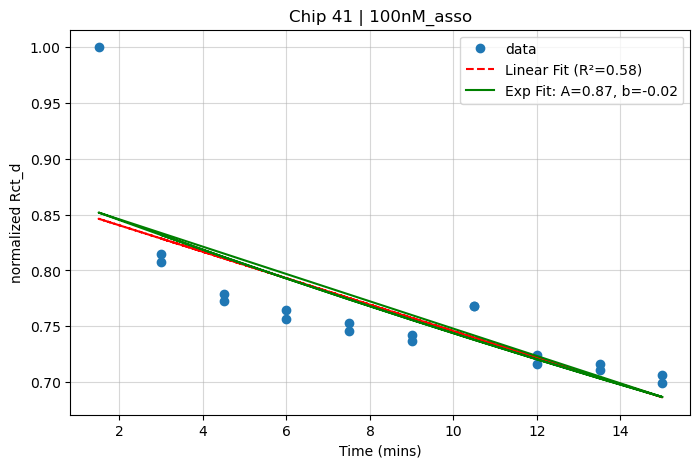

[0.93670845 0.91989144 0.90789058 0.89648234 0.88945902 0.88013932
 0.87098421 0.86477213 0.85776047 0.85107363 0.84508527 0.87626633
 0.83328454 0.82706295 0.82116401 0.81472923 0.80896346 0.84040857
 0.83389806 0.82775693 1.         0.93731447 0.91884207 0.90662809
 0.89499425 0.8866163  0.87811011 0.86857313 0.86162971 0.85413138
 0.84764387 0.84212015 0.83567298 0.82932744 0.82229074 0.81661919
 0.80903922 0.80217187 0.79805124 0.79071718 0.78469417]  y
[0.93670845 0.91989144 0.90789058 0.89648234 0.88945902 0.88013932
 0.87098421 0.86477213 0.85776047 0.85107363 0.84508527 0.87626633
 0.83328454 0.82706295 0.82116401 0.81472923 0.80896346 0.84040857
 0.83389806 0.82775693 1.         0.93731447 0.91884207 0.90662809
 0.89499425 0.8866163  0.87811011 0.86857313 0.86162971 0.85413138
 0.84764387 0.84212015 0.83567298 0.82932744 0.82229074 0.81661919
 0.80903922 0.80217187 0.79805124 0.79071718 0.78469417]  x


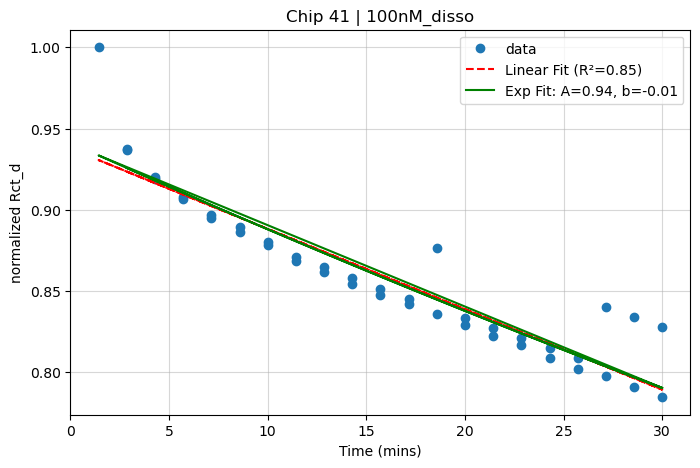

[0.85075926 0.81837206 0.80525389 0.78944525 0.78142799 0.76932362
 0.75935917 0.75053748 0.76878426 1.         0.85008088 0.81627364
 0.80056728 0.78953105 0.7774449  0.76563836 0.75589358 0.74524874
 0.73576268]  y
[0.85075926 0.81837206 0.80525389 0.78944525 0.78142799 0.76932362
 0.75935917 0.75053748 0.76878426 1.         0.85008088 0.81627364
 0.80056728 0.78953105 0.7774449  0.76563836 0.75589358 0.74524874
 0.73576268]  x


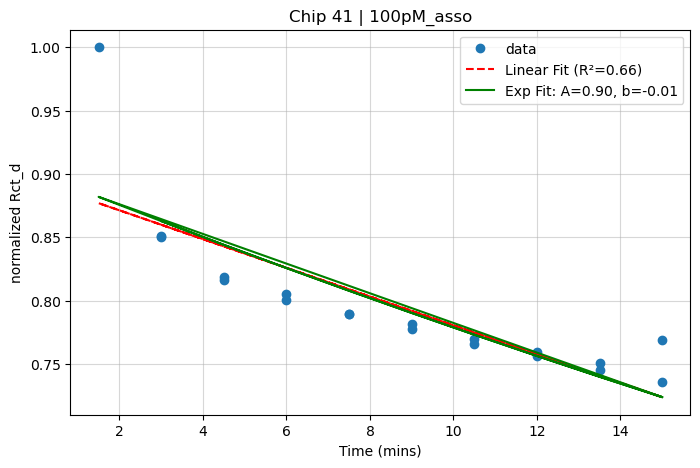

[0.93843211 0.91943066 0.90896814 0.89820215 0.89006227 0.88317103
 0.87435089 0.86505432 0.85956768 0.88665026 0.84427662 0.83576209
 0.82956153 0.82673056 0.85549114 0.81065557 0.80572182 0.83620753
 0.82984522 0.82357986 1.         0.9410049  0.92144003 0.91038254
 0.90127191 0.89196608 0.882917   0.87398871 0.86521558 0.85849869
 0.85053645 0.84368921 0.83660883 0.82948047 0.82259598 0.81646132
 0.80928203 0.80266846 0.79668104 0.78909937 0.78273755]  y
[0.93843211 0.91943066 0.90896814 0.89820215 0.89006227 0.88317103
 0.87435089 0.86505432 0.85956768 0.88665026 0.84427662 0.83576209
 0.82956153 0.82673056 0.85549114 0.81065557 0.80572182 0.83620753
 0.82984522 0.82357986 1.         0.9410049  0.92144003 0.91038254
 0.90127191 0.89196608 0.882917   0.87398871 0.86521558 0.85849869
 0.85053645 0.84368921 0.83660883 0.82948047 0.82259598 0.81646132
 0.80928203 0.80266846 0.79668104 0.78909937 0.78273755]  x


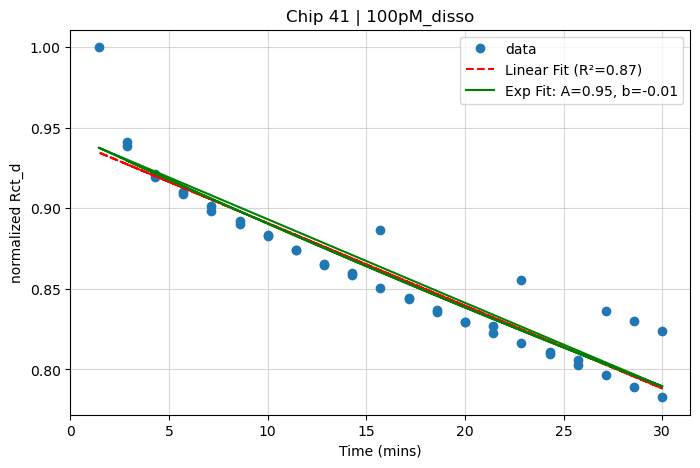

[0.84817349 0.81748191 0.80036972 0.7924299  0.7809294  0.77133798
 0.76219734 0.75380931 0.74488334 1.         0.85067121 0.81614738
 0.80188866 0.79064224 0.779503   0.76967903 0.76009892 0.75143892
 0.74216749]  y
[0.84817349 0.81748191 0.80036972 0.7924299  0.7809294  0.77133798
 0.76219734 0.75380931 0.74488334 1.         0.85067121 0.81614738
 0.80188866 0.79064224 0.779503   0.76967903 0.76009892 0.75143892
 0.74216749]  x


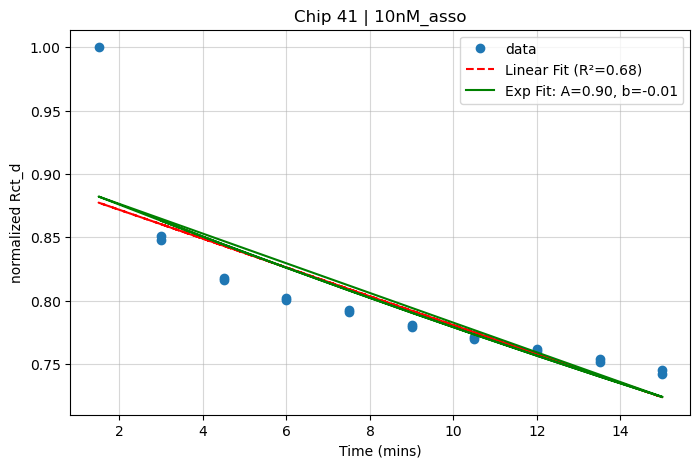

[0.94479141 0.92818359 0.91571977 0.90657616 0.89808536 0.88561761
 0.88172463 0.87297615 0.90253649 0.85902001 0.88928283 0.88258122
 0.87639598 0.83134439 0.82712676 0.85743509 0.85088683 0.80620002
 0.83893084 0.83320163 1.         0.94434596 0.92692769 0.91418513
 0.90444526 0.89404346 0.88508613 0.87712391 0.87057916 0.86275849
 0.85556373 0.84865099 0.84204301 0.83395144 0.8269233  0.82197496
 0.81438565 0.80842013 0.80135438 0.7950161  0.78957987]  y
[0.94479141 0.92818359 0.91571977 0.90657616 0.89808536 0.88561761
 0.88172463 0.87297615 0.90253649 0.85902001 0.88928283 0.88258122
 0.87639598 0.83134439 0.82712676 0.85743509 0.85088683 0.80620002
 0.83893084 0.83320163 1.         0.94434596 0.92692769 0.91418513
 0.90444526 0.89404346 0.88508613 0.87712391 0.87057916 0.86275849
 0.85556373 0.84865099 0.84204301 0.83395144 0.8269233  0.82197496
 0.81438565 0.80842013 0.80135438 0.7950161  0.78957987]  x


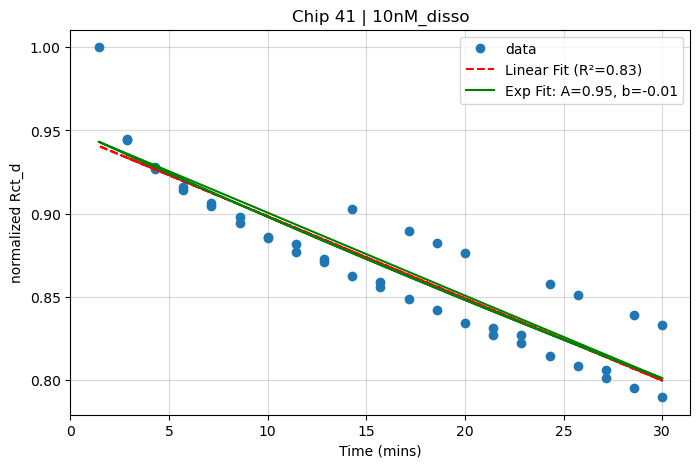

[0.85360024 0.8184381  0.80454239 0.7909874  0.78249674 0.77070324
 0.7614363  0.78064038 0.74293121 1.         0.85181642 0.81773378
 0.80162885 0.78897461 0.777616   0.76688151 0.75769405 0.74815491
 0.73784967]  y
[0.85360024 0.8184381  0.80454239 0.7909874  0.78249674 0.77070324
 0.7614363  0.78064038 0.74293121 1.         0.85181642 0.81773378
 0.80162885 0.78897461 0.777616   0.76688151 0.75769405 0.74815491
 0.73784967]  x


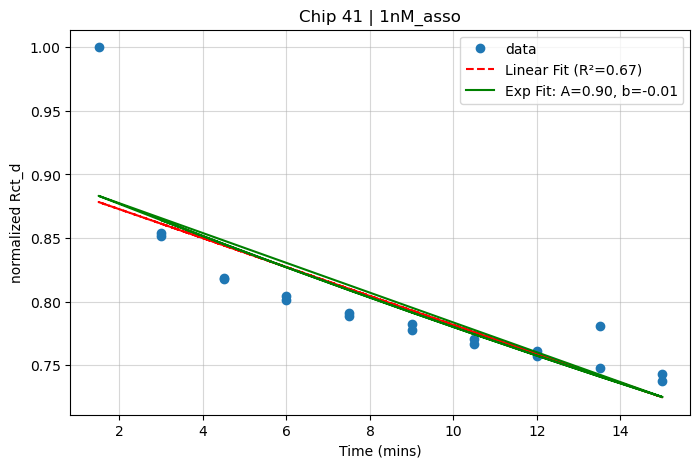

[0.92756526 0.91053666 0.90031191 0.88863908 0.88063967 0.87425641
 0.8681864  0.86093457 0.853295   0.84877873 0.84120885 0.83491432
 0.83016195 0.81966617 0.81478018 0.84432162 0.80178662 0.83180682
 0.81758796 0.81855718 1.         0.93016026 0.9107256  0.89827254
 0.88782712 0.87928306 0.87244614 0.86586192 0.85903812 0.85185383
 0.84626653 0.84003654 0.83215889 0.8252761  0.81889597 0.81209447
 0.80643133 0.79874167 0.79359433 0.78580851 0.77975184]  y
[0.92756526 0.91053666 0.90031191 0.88863908 0.88063967 0.87425641
 0.8681864  0.86093457 0.853295   0.84877873 0.84120885 0.83491432
 0.83016195 0.81966617 0.81478018 0.84432162 0.80178662 0.83180682
 0.81758796 0.81855718 1.         0.93016026 0.9107256  0.89827254
 0.88782712 0.87928306 0.87244614 0.86586192 0.85903812 0.85185383
 0.84626653 0.84003654 0.83215889 0.8252761  0.81889597 0.81209447
 0.80643133 0.79874167 0.79359433 0.78580851 0.77975184]  x


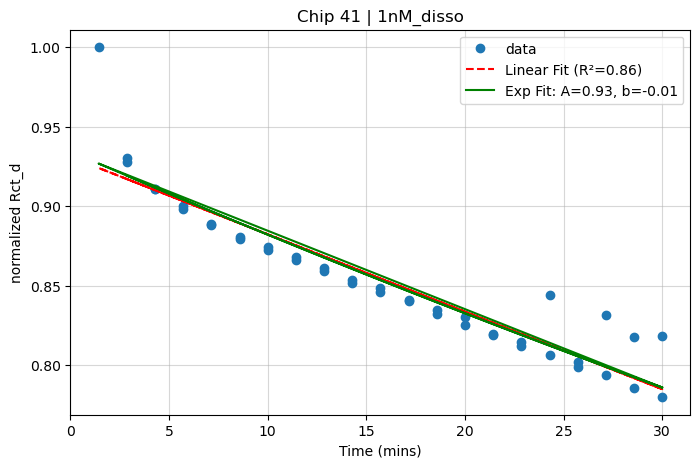

[0.92013204 0.89616995 0.59075487 0.77790281 0.85744093 0.84887571
 0.7759112  0.3367821  0.33923383 1.         0.92013204 0.89616995
 0.59075484 0.77790282 0.85744093 0.84887571 0.7759112  0.33678204
 0.33923382 1.         0.92013204 0.89616995 0.59075484 0.77790282
 0.85744093 0.84887571 0.7759112  0.33678204 0.33923382 1.
 0.92013204 0.89616995 0.59075484 0.77790282 0.85744093 0.84887571
 0.7759112  0.33678204 0.33923382 1.         0.92013204 0.89616995
 0.59075484 0.77790282 0.85744093 0.84887571 0.7759112  0.33678204
 0.33923382 1.         0.92990822 0.90569153 0.89009945 0.88031214
 0.86655103 0.85789481 0.84719506 0.83799524 0.82845542 1.
 0.92990822 0.90569153 0.89009945 0.88031214 0.86655103 0.85789481
 0.84719506 0.83799524 0.82845542]  y
[0.92013204 0.89616995 0.59075487 0.77790281 0.85744093 0.84887571
 0.7759112  0.3367821  0.33923383 1.         0.92013204 0.89616995
 0.59075484 0.77790282 0.85744093 0.84887571 0.7759112  0.33678204
 0.33923382 1.         0.92013204 0.8961

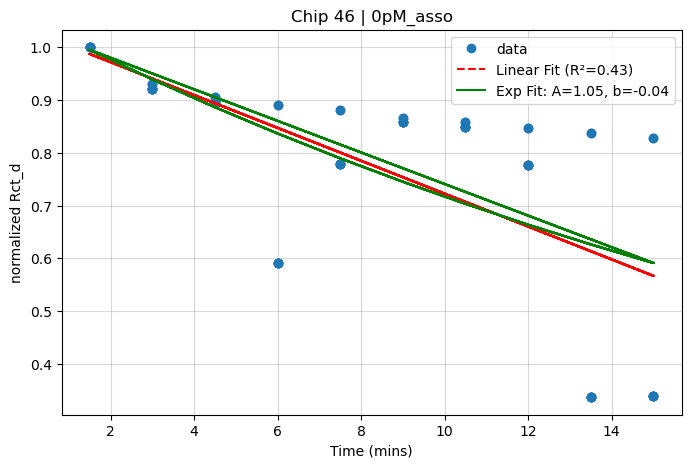

[0.94120827 0.92245593 0.82510782 0.82389148 0.88885362 0.35855323
 0.36141724 0.36286489 0.36413626 0.36593972 0.36720942 0.82414104
 0.81798336 0.42967419 0.42615026 0.41991426 0.7871743  0.40733906
 0.30464172 0.76737174 1.         0.94120827 0.92245593 0.82510781
 0.82389147 0.88885362 0.35855322 0.36141728 0.36286489 0.36413626
 0.36593972 0.36720942 0.82414104 0.81798336 0.42967419 0.42615029
 0.41991428 0.7871743  0.40733904 0.3046417  0.76737174 1.
 0.94120827 0.92245593 0.82510781 0.82389147 0.88885362 0.35855322
 0.36141728 0.36286489 0.36413626 0.36593972 0.36720942 0.82414104
 0.81798336 0.42967419 0.42615029 0.41991428 0.7871743  0.40733904
 0.3046417  0.76737174 1.         0.94120827 0.92245593 0.82510781
 0.82389147 0.88885362 0.35855322 0.36141728 0.36286489 0.36413626
 0.36593972 0.36720942 0.82414104 0.81798336 0.42967419 0.42615029
 0.41991428 0.7871743  0.40733904 0.3046417  0.76737174 1.
 0.94120827 0.92245593 0.82510781 0.82389147 0.88885362 0.35855322
 0.36141728

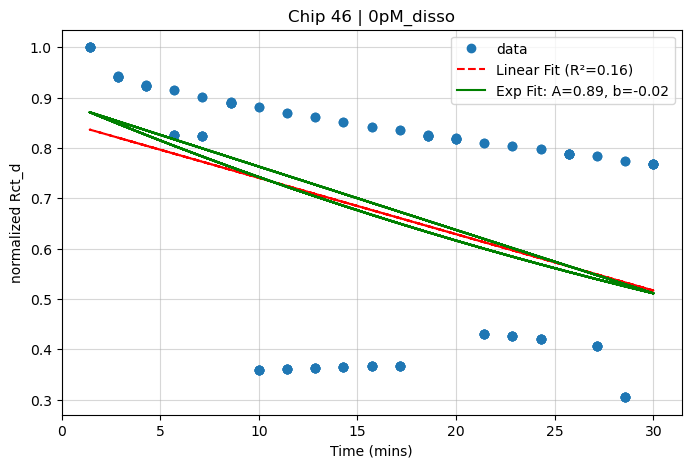

[2.59977331 0.90210842 2.35305036 2.31885114 1.65211339 2.24821853
 2.21686209 1.37730711 1.37263349 1.         2.59977332 0.90210842
 2.35305037 2.31885115 1.6521134  2.24821853 2.2168621  1.37730714
 1.37263347 1.         2.59977332 0.90210842 2.35305037 2.31885115
 1.6521134  2.24821853 2.2168621  1.37730714 1.37263347 1.
 2.59977332 0.90210842 2.35305037 2.31885115 1.6521134  2.24821853
 2.2168621  1.37730714 1.37263347 1.         2.59977332 0.90210842
 2.35305037 2.31885115 1.6521134  2.24821853 2.2168621  1.37730714
 1.37263347 1.         0.64919582 0.62213157 0.60934685 0.60172451
 0.59306533 0.58519087 0.57682524 0.56936596 0.56267882 1.
 0.64919582 0.62213157 0.60934685 0.60172451 0.59306533 0.58519087
 0.57682524 0.56936596 0.56267882]  y
[2.59977331 0.90210842 2.35305036 2.31885114 1.65211339 2.24821853
 2.21686209 1.37730711 1.37263349 1.         2.59977332 0.90210842
 2.35305037 2.31885115 1.6521134  2.24821853 2.2168621  1.37730714
 1.37263347 1.         2.59977332 0.9021

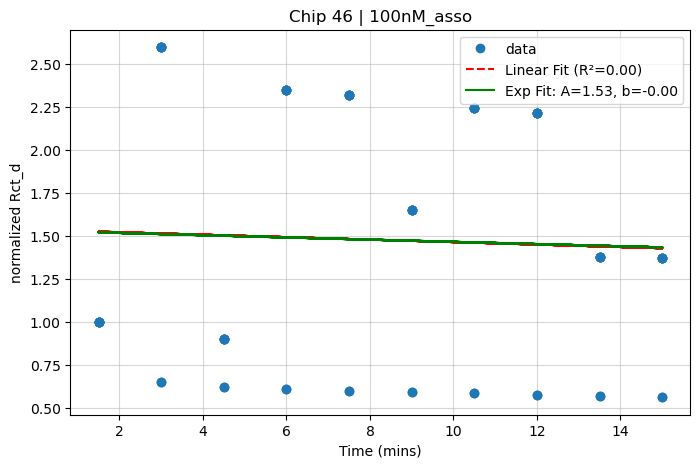

[0.54506336 0.91110955 0.89808302 0.88655523 0.5970375  0.86940392
 0.86119809 0.85415191 0.84595126 0.84064081 0.83432585 0.82818843
 0.82110041 0.81557169 0.81023627 0.80273041 0.79461491 0.41030955
 0.78244628 0.77469932 1.         0.54506336 0.91110955 0.89808302
 0.88655523 0.59703751 0.86940392 0.86119809 0.85415191 0.84595126
 0.84064081 0.83432585 0.82818843 0.82110041 0.81557169 0.81023627
 0.80273041 0.79461491 0.41030955 0.78244628 0.77469932 1.
 0.54506336 0.91110955 0.89808302 0.88655523 0.59703751 0.86940392
 0.86119809 0.85415191 0.84595126 0.84064081 0.83432585 0.82818843
 0.82110041 0.81557169 0.81023627 0.80273041 0.79461491 0.41030955
 0.78244628 0.77469932 1.         0.54506336 0.91110955 0.89808302
 0.88655523 0.59703751 0.86940392 0.86119809 0.85415191 0.84595126
 0.84064081 0.83432585 0.82818843 0.82110041 0.81557169 0.81023627
 0.80273041 0.79461491 0.41030955 0.78244628 0.77469932 1.
 0.54506336 0.91110955 0.89808302 0.88655523 0.59703751 0.86940392
 0.86119809

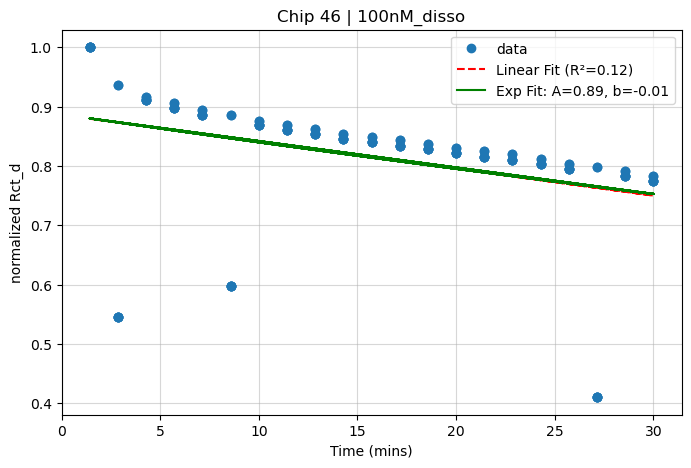

[0.81025452 0.74798812 0.7290134  0.71567248 0.70459418 0.69300292
 0.68428295 0.67492849 0.27196059 1.         0.81025452 0.74798812
 0.7290134  0.71567248 0.70459418 0.69300292 0.68428295 0.67492849
 0.27196062 1.         0.81025452 0.74798812 0.7290134  0.71567248
 0.70459418 0.69300292 0.68428295 0.67492849 0.27196062 1.
 0.81025452 0.74798812 0.7290134  0.71567248 0.70459418 0.69300292
 0.68428295 0.67492849 0.27196062 1.         0.81025452 0.74798812
 0.7290134  0.71567248 0.70459418 0.69300292 0.68428295 0.67492849
 0.27196062 1.         0.78961533 0.74242325 0.7279621  0.71567248
 0.70459418 0.69300292 0.68428295 0.67492849 0.66688394 1.
 0.78961533 0.74242325 0.7279621  0.71567248 0.70459418 0.69300292
 0.68428295 0.67492849 0.66688394]  y
[0.81025452 0.74798812 0.7290134  0.71567248 0.70459418 0.69300292
 0.68428295 0.67492849 0.27196059 1.         0.81025452 0.74798812
 0.7290134  0.71567248 0.70459418 0.69300292 0.68428295 0.67492849
 0.27196062 1.         0.81025452 0.7479

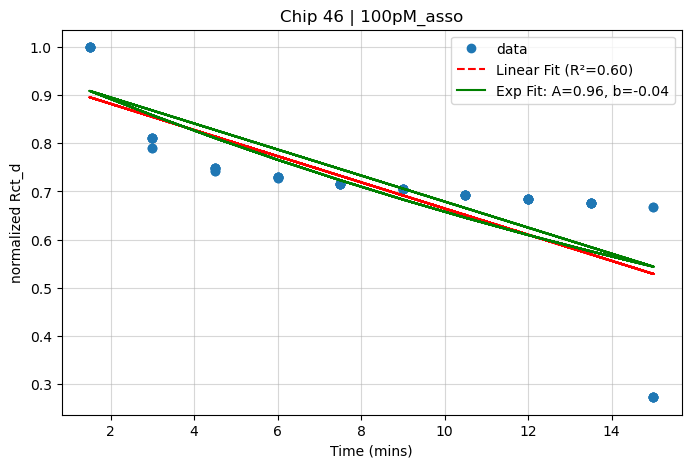

[0.90483364 0.88331132 0.87066134 0.86201396 0.34800129 0.34954938
 0.34938246 0.83495488 0.35103098 0.82213287 0.35136567 0.35077241
 0.80347417 0.79908403 0.35105693 0.78504579 0.42321756 0.41772015
 0.40614811 0.40318067 1.         0.90483364 0.88331132 0.87066134
 0.86201396 0.34800128 0.3495494  0.34938246 0.83495488 0.35103101
 0.82213287 0.35136568 0.35077242 0.80347417 0.79908403 0.35105692
 0.78504579 0.42321755 0.41772013 0.40614813 0.40318063 1.
 0.90483364 0.88331132 0.87066134 0.86201396 0.34800128 0.3495494
 0.34938246 0.83495488 0.35103101 0.82213287 0.35136568 0.35077242
 0.80347417 0.79908403 0.35105692 0.78504579 0.42321755 0.41772013
 0.40614813 0.40318063 1.         0.90483364 0.88331132 0.87066134
 0.86201396 0.34800128 0.3495494  0.34938246 0.83495488 0.35103101
 0.82213287 0.35136568 0.35077242 0.80347417 0.79908403 0.35105692
 0.78504579 0.42321755 0.41772013 0.40614813 0.40318063 1.
 0.90483364 0.88331132 0.87066134 0.86201396 0.34800128 0.3495494
 0.34938246 0

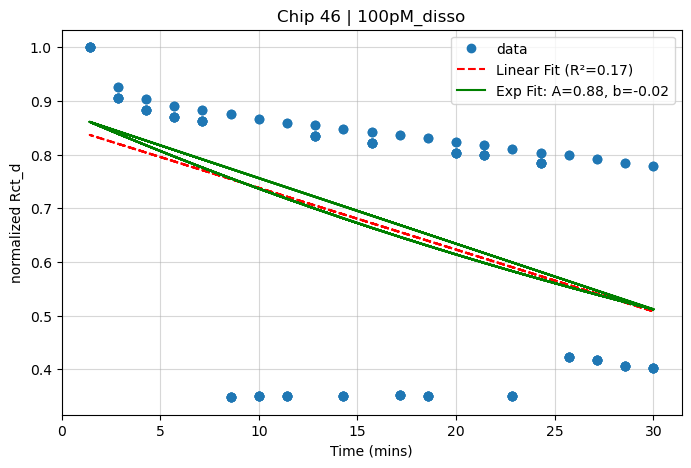

[0.86994493 0.80961961 0.79092642 0.77866607 0.76575743 0.75584187
 0.74502176 0.73692136 0.72775274 1.         0.86994493 0.80961961
 0.79092642 0.77866607 0.76575743 0.75584187 0.74502176 0.73692136
 0.72775274 1.         0.86994493 0.80961961 0.79092642 0.77866607
 0.76575743 0.75584187 0.74502176 0.73692136 0.72775274 1.
 0.86994493 0.80961961 0.79092642 0.77866607 0.76575743 0.75584187
 0.74502176 0.73692136 0.72775274 1.         0.86994493 0.80961961
 0.79092642 0.77866607 0.76575743 0.75584187 0.74502176 0.73692136
 0.72775274 1.         0.82625498 0.7906079  0.77733736 0.76760542
 0.75558506 0.74569769 0.73501361 0.72702706 0.7181535  1.
 0.82625498 0.7906079  0.77733736 0.76760542 0.75558506 0.74569769
 0.73501361 0.72702706 0.7181535 ]  y
[0.86994493 0.80961961 0.79092642 0.77866607 0.76575743 0.75584187
 0.74502176 0.73692136 0.72775274 1.         0.86994493 0.80961961
 0.79092642 0.77866607 0.76575743 0.75584187 0.74502176 0.73692136
 0.72775274 1.         0.86994493 0.8096

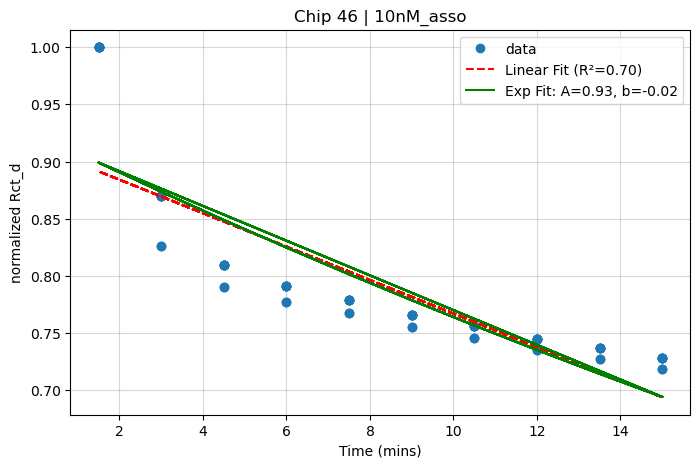

[0.85054714 0.82561377 0.81318157 0.80450733 0.79664499 0.78938049
 0.78187178 0.77458879 0.32009113 0.32052593 0.75445698 0.74705879
 0.74062595 0.73434345 0.72969755 0.72277416 0.71681154 0.70917463
 0.70389605 0.3630433  1.         0.85054714 0.82561377 0.81318157
 0.80450733 0.79664499 0.78938049 0.78187178 0.77458879 0.32009113
 0.32052594 0.75445698 0.74705879 0.74062595 0.73434345 0.72969755
 0.72277416 0.71681154 0.70917463 0.70389605 0.3631028  1.
 0.85054714 0.82561377 0.81318157 0.80450733 0.79664499 0.78938049
 0.78187178 0.77458879 0.32009113 0.32052594 0.75445698 0.74705879
 0.74062595 0.73434345 0.72969755 0.72277416 0.71681154 0.70917463
 0.70389605 0.3631028  1.         0.85054714 0.82561377 0.81318157
 0.80450733 0.79664499 0.78938049 0.78187178 0.77458879 0.32009113
 0.32052594 0.75445698 0.74705879 0.74062595 0.73434345 0.72969755
 0.72277416 0.71681154 0.70917463 0.70389605 0.3631028  1.
 0.85054714 0.82561377 0.81318157 0.80450733 0.79664499 0.78938049
 0.78187178

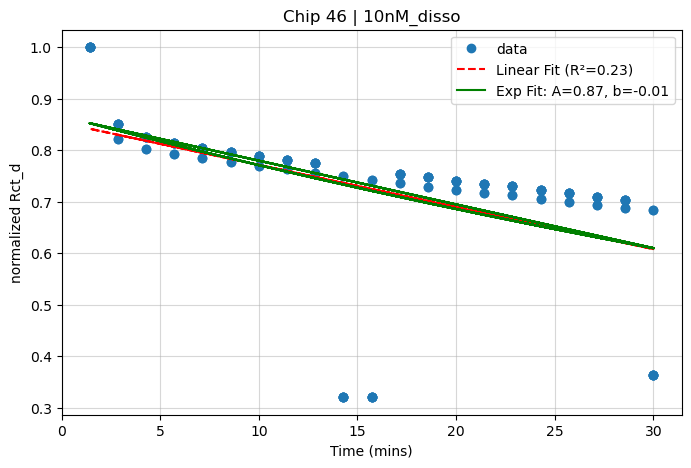

[0.84011013 0.77302983 0.7536441  0.74025376 0.7279486  0.71833128
 0.63725646 0.63926682 0.27868237 1.         0.84011013 0.77302983
 0.7536441  0.74025376 0.7279486  0.71833128 0.63725638 0.63926682
 0.27868237 1.         0.84011013 0.77302983 0.7536441  0.74025376
 0.7279486  0.71833128 0.63725638 0.63926682 0.27868237 1.
 0.84011013 0.77302983 0.7536441  0.74025376 0.7279486  0.71833128
 0.63725638 0.63926682 0.27868237 1.         0.84011013 0.77302983
 0.7536441  0.74025376 0.7279486  0.71833128 0.63725638 0.63926682
 0.27868237 1.         0.82350522 0.7661831  0.75170643 0.73995323
 0.7279486  0.71833128 0.70775801 0.69801057 0.6892807  1.
 0.82350522 0.7661831  0.75170643 0.73995323 0.7279486  0.71833128
 0.70775801 0.69801057 0.6892807 ]  y
[0.84011013 0.77302983 0.7536441  0.74025376 0.7279486  0.71833128
 0.63725646 0.63926682 0.27868237 1.         0.84011013 0.77302983
 0.7536441  0.74025376 0.7279486  0.71833128 0.63725638 0.63926682
 0.27868237 1.         0.84011013 0.7730

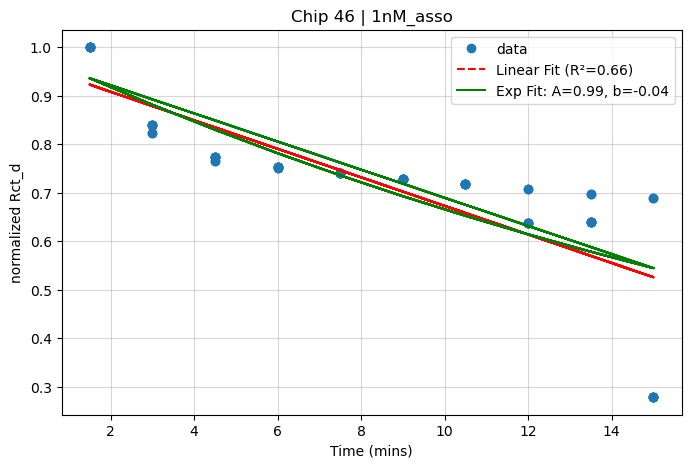

[0.85847215 0.83787405 0.82687624 0.73851248 0.73683418 0.73523041
 0.79448926 0.78693723 0.32247601 0.32238384 0.7658595  0.323473
 0.75098197 0.32471539 0.74072729 0.3973408  0.39549432 0.38293568
 0.7168563  0.37364894 1.         0.85847215 0.83787405 0.82687624
 0.73851249 0.73683418 0.7352304  0.79448926 0.78693723 0.32247601
 0.32238381 0.7658595  0.32347299 0.75098197 0.32471539 0.74072729
 0.3973408  0.39549431 0.38293567 0.7168563  0.37364895 1.
 0.85847215 0.83787405 0.82687624 0.73851249 0.73683418 0.7352304
 0.79448926 0.78693723 0.32247601 0.32238381 0.7658595  0.32347299
 0.75098197 0.32471539 0.74072729 0.3973408  0.39549431 0.38293567
 0.7168563  0.37364895 1.         0.85847215 0.83787405 0.82687624
 0.73851249 0.73683418 0.7352304  0.79448926 0.78693723 0.32247601
 0.32238381 0.7658595  0.32347299 0.75098197 0.32471539 0.74072729
 0.3973408  0.39549431 0.38293567 0.7168563  0.37364895 1.
 0.85847215 0.83787405 0.82687624 0.73851249 0.73683418 0.7352304
 0.79448926 0.7

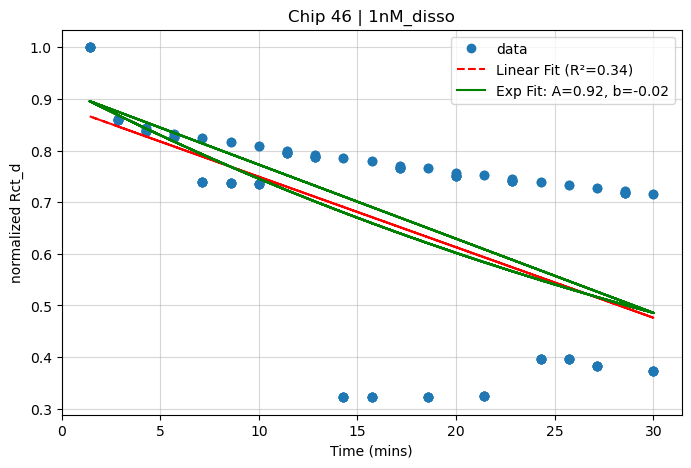

[0.90332989 2.80944862 2.61865997 2.53131725 2.4271725  2.3847439
 2.2828271  2.27737684 2.23086916 1.         0.97796266 0.96437289
 0.89888267 0.86890136 0.83315257 0.80991358 0.76991223 0.76001114
 0.75049898 1.         0.97796266 0.96437289 0.89888267 0.86890136
 0.83315257 0.80991358 0.76991223 0.76001114 0.75049898 1.
 0.97796266 0.96437289 0.89888267 0.86890136 0.83315257 0.80991358
 0.76991223 0.76001114 0.75049898 1.         0.97796266 0.96437289
 0.89888267 0.86890136 0.83315257 0.80991358 0.76991223 0.76001114
 0.75049898]  y
[0.90332989 2.80944862 2.61865997 2.53131725 2.4271725  2.3847439
 2.2828271  2.27737684 2.23086916 1.         0.97796266 0.96437289
 0.89888267 0.86890136 0.83315257 0.80991358 0.76991223 0.76001114
 0.75049898 1.         0.97796266 0.96437289 0.89888267 0.86890136
 0.83315257 0.80991358 0.76991223 0.76001114 0.75049898 1.
 0.97796266 0.96437289 0.89888267 0.86890136 0.83315257 0.80991358
 0.76991223 0.76001114 0.75049898 1.         0.97796266 0.964372

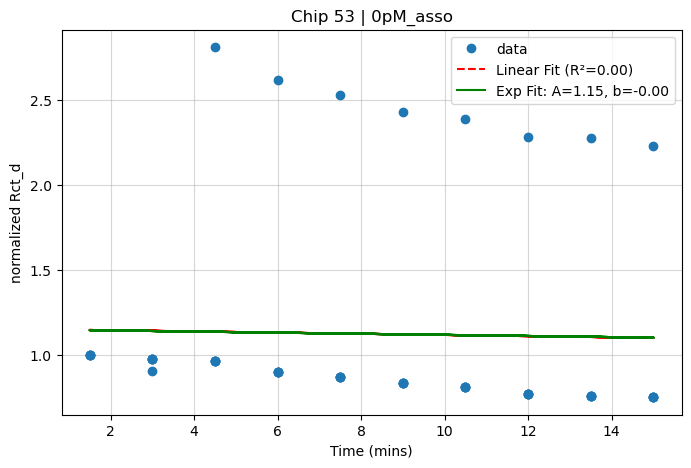

[0.34206583 1.00172586 0.96273345 0.92196218 0.90370536 0.88858489
 0.87063773 0.86458541 0.85247152 0.84340158 0.8319942  0.82392254
 0.54447984 0.80875392 0.79925641 0.79234126 0.78349807 0.53087646
 0.7699687  0.76193487 1.         1.07794162 1.00172586 0.96273345
 0.91881976 0.885841   0.87387016 0.8608162  0.85302153 0.84377716
 0.83441451 0.82624461 0.81947933 0.81053407 0.80318884 0.7953133
 0.78788996 0.78044274 0.77231105 0.76677329 0.7584717  1.
 1.07794162 1.00172586 0.96273345 0.91881976 0.885841   0.87387016
 0.8608162  0.85302153 0.84377716 0.83441451 0.82624461 0.81947933
 0.81053407 0.80318884 0.7953133  0.78788996 0.78044274 0.77231105
 0.76677329 0.7584717  1.         1.07794162 1.00172586 0.96273345
 0.91881976 0.885841   0.87387016 0.8608162  0.85302153 0.84377716
 0.83441451 0.82624461 0.81947933 0.81053407 0.80318884 0.7953133
 0.78788996 0.78044274 0.77231105 0.76677329 0.7584717  1.
 1.07794162 1.00172586 0.96273345 0.91881976 0.885841   0.87387016
 0.8608162  0

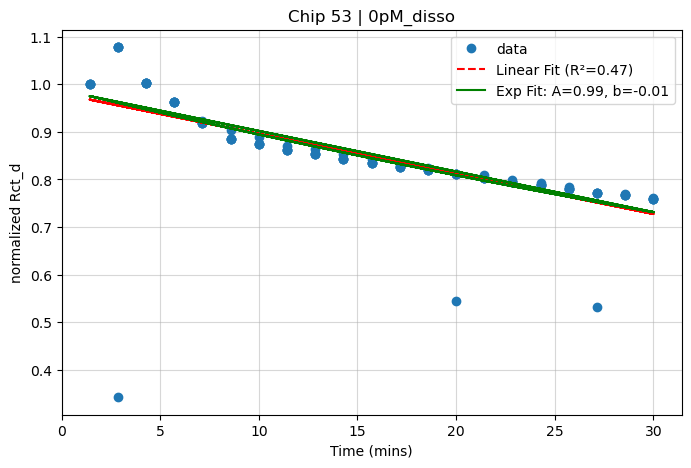

[0.27894779 0.50313231 0.86524988 0.81636671 0.79095571 0.75387902
 0.74626727 0.72684971 0.70964928 1.         1.00604069 0.98271511
 0.92886417 0.79661804 0.73294076 0.69456688 0.68392653 0.67467838
 0.6649907  1.         1.00604069 0.98271511 0.92886417 0.79661804
 0.73294076 0.69456688 0.68392653 0.67467838 0.6649907  1.
 1.00604069 0.98271511 0.92886417 0.79661804 0.73294076 0.69456688
 0.68392653 0.67467838 0.6649907  1.         1.00604069 0.98271511
 0.92886417 0.79661804 0.73294076 0.69456688 0.68392653 0.67467838
 0.6649907 ]  y
[0.27894779 0.50313231 0.86524988 0.81636671 0.79095571 0.75387902
 0.74626727 0.72684971 0.70964928 1.         1.00604069 0.98271511
 0.92886417 0.79661804 0.73294076 0.69456688 0.68392653 0.67467838
 0.6649907  1.         1.00604069 0.98271511 0.92886417 0.79661804
 0.73294076 0.69456688 0.68392653 0.67467838 0.6649907  1.
 1.00604069 0.98271511 0.92886417 0.79661804 0.73294076 0.69456688
 0.68392653 0.67467838 0.6649907  1.         1.00604069 0.9827

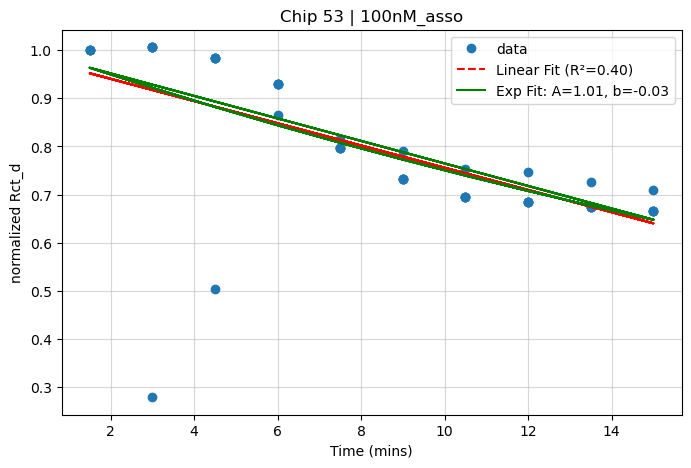

[0.93813743 0.91670205 0.90323041 0.55302147 1.00321974 0.97108543
 0.85661554 0.92858169 0.92326568 0.93204118 0.91295545 0.90879242
 0.84667889 0.84157341 0.86493291 0.81996801 0.80505979 0.80541516
 0.80691615 0.79368458 1.         0.93813743 0.90725986 0.87559823
 1.02108939 1.0310183  0.98874357 0.83601159 0.93043795 0.92534435
 0.94160649 0.91801876 0.91620111 0.80149685 0.79514086 0.84528693
 0.78121381 0.77402556 0.76950732 0.76274746 0.75502875 1.
 0.93813743 0.90725986 0.87559823 1.02108939 1.0310183  0.98874357
 0.83601159 0.93043795 0.92534435 0.94160649 0.91801876 0.91620111
 0.80149685 0.79514086 0.84528693 0.78121381 0.77402556 0.76950732
 0.76274746 0.75502875 1.         0.93813743 0.90725986 0.87559823
 1.02108939 1.0310183  0.98874357 0.83601159 0.93043795 0.92534435
 0.94160649 0.91801876 0.91620111 0.80149685 0.79514086 0.84528693
 0.78121381 0.77402556 0.76950732 0.76274746 0.75502875 1.
 0.93813743 0.90725986 0.87559823 1.02108939 1.0310183  0.98874357
 0.83601159

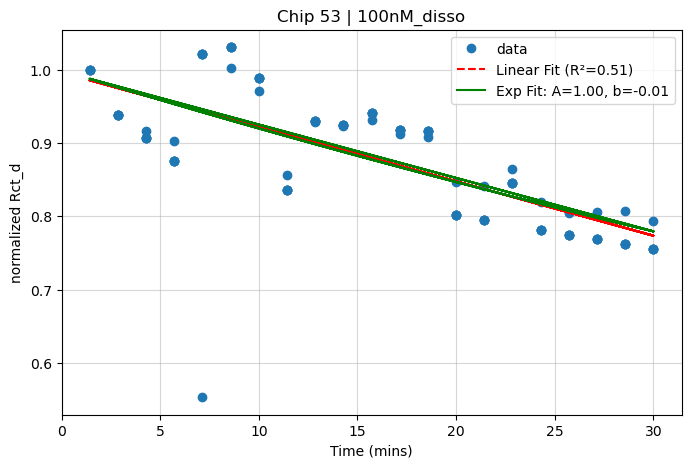

[0.84201864 0.31127987 0.28732837 0.77905589 0.81815841 0.79360001
 0.7786444  0.76084472 0.74483971 1.         0.84201864 0.90998175
 0.89423567 0.77905589 0.81815841 0.79360001 0.7786444  0.75353119
 0.72791368 1.         0.84201864 0.90998175 0.89423567 0.77905589
 0.81815841 0.79360001 0.7786444  0.75353119 0.72791368 1.
 0.84201864 0.90998175 0.89423567 0.77905589 0.81815841 0.79360001
 0.7786444  0.75353119 0.72791368 1.         0.84201864 0.90998175
 0.89423567 0.77905589 0.81815841 0.79360001 0.7786444  0.75353119
 0.72791368]  y
[0.84201864 0.31127987 0.28732837 0.77905589 0.81815841 0.79360001
 0.7786444  0.76084472 0.74483971 1.         0.84201864 0.90998175
 0.89423567 0.77905589 0.81815841 0.79360001 0.7786444  0.75353119
 0.72791368 1.         0.84201864 0.90998175 0.89423567 0.77905589
 0.81815841 0.79360001 0.7786444  0.75353119 0.72791368 1.
 0.84201864 0.90998175 0.89423567 0.77905589 0.81815841 0.79360001
 0.7786444  0.75353119 0.72791368 1.         0.84201864 0.9099

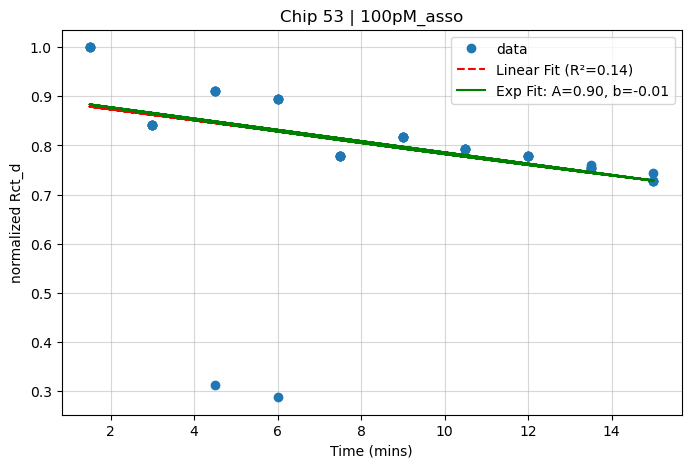

[0.33372958 0.9850509  0.94776063 0.93000504 0.91114043 0.8958683
 0.88467159 0.86770112 0.85797985 0.85097446 0.83905283 0.82914151
 0.81963612 0.80967116 0.8030194  0.79243792 0.5298772  0.7746852
 0.76751204 0.7592493  1.         1.08065032 0.9850509  0.94660438
 0.92136716 0.88767248 0.8791433  0.86757355 0.85659884 0.8475331
 0.83867699 0.82995068 0.82098862 0.81182336 0.80340767 0.79646843
 0.78707288 0.77942729 0.76983729 0.76259173 0.75436339 1.
 1.08065032 0.9850509  0.94660438 0.92136716 0.88767248 0.8791433
 0.86757355 0.85659884 0.8475331  0.83867699 0.82995068 0.82098862
 0.81182336 0.80340767 0.79646843 0.78707288 0.77942729 0.76983729
 0.76259173 0.75436339 1.         1.08065032 0.9850509  0.94660438
 0.92136716 0.88767248 0.8791433  0.86757355 0.85659884 0.8475331
 0.83867699 0.82995068 0.82098862 0.81182336 0.80340767 0.79646843
 0.78707288 0.77942729 0.76983729 0.76259173 0.75436339 1.
 1.08065032 0.9850509  0.94660438 0.92136716 0.88767248 0.8791433
 0.86757355 0.856

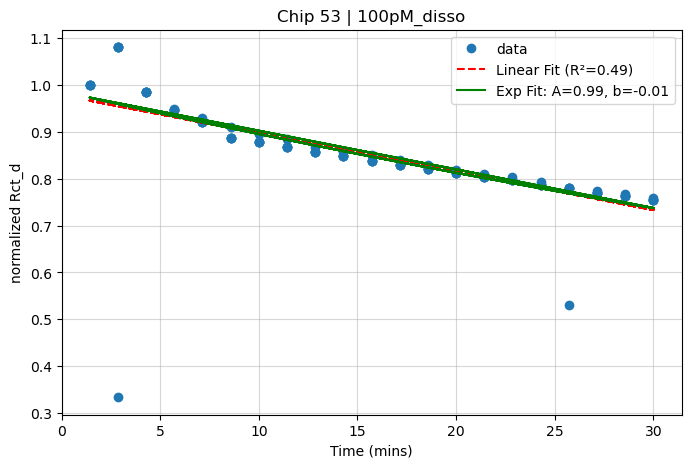

[0.3294997  0.29083536 0.27496825 0.86477627 0.82215649 0.79415811
 0.77247933 0.75459987 0.73567802 1.         0.92793893 0.8880565
 0.87385658 0.86477627 0.82215649 0.79415811 0.76584166 0.73983668
 0.70457775 1.         0.92793893 0.8880565  0.87385658 0.86477627
 0.82215649 0.79415811 0.76584166 0.73983668 0.70457775 1.
 0.92793893 0.8880565  0.87385658 0.86477627 0.82215649 0.79415811
 0.76584166 0.73983668 0.70457775 1.         0.92793893 0.8880565
 0.87385658 0.86477627 0.82215649 0.79415811 0.76584166 0.73983668
 0.70457775]  y
[0.3294997  0.29083536 0.27496825 0.86477627 0.82215649 0.79415811
 0.77247933 0.75459987 0.73567802 1.         0.92793893 0.8880565
 0.87385658 0.86477627 0.82215649 0.79415811 0.76584166 0.73983668
 0.70457775 1.         0.92793893 0.8880565  0.87385658 0.86477627
 0.82215649 0.79415811 0.76584166 0.73983668 0.70457775 1.
 0.92793893 0.8880565  0.87385658 0.86477627 0.82215649 0.79415811
 0.76584166 0.73983668 0.70457775 1.         0.92793893 0.8880565

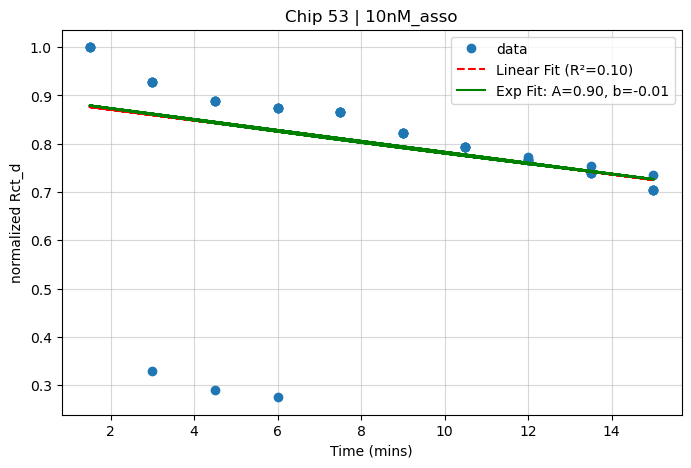

[0.33314852 0.99613001 0.97354499 0.89237091 0.92305191 0.90406598
 0.88420505 0.8778042  0.86489802 0.84496382 0.84817783 0.840706
 0.83300824 0.78962548 0.81498494 0.80828175 0.79797898 0.79234776
 0.7801906  0.77598079 1.         1.0590287  0.99613001 0.97354499
 0.87929901 0.91833543 0.8883852  0.8535872  0.84454915 0.83560076
 0.8273426  0.82245304 0.8162534  0.80968583 0.78962548 0.79587807
 0.78998478 0.7818194  0.77566962 0.76733875 0.76115201 1.
 1.0590287  0.99613001 0.97354499 0.87929901 0.91833543 0.8883852
 0.8535872  0.84454915 0.83560076 0.8273426  0.82245304 0.8162534
 0.80968583 0.78962548 0.79587807 0.78998478 0.7818194  0.77566962
 0.76733875 0.76115201 1.         1.0590287  0.99613001 0.97354499
 0.87929901 0.91833543 0.8883852  0.8535872  0.84454915 0.83560076
 0.8273426  0.82245304 0.8162534  0.80968583 0.78962548 0.79587807
 0.78998478 0.7818194  0.77566962 0.76733875 0.76115201 1.
 1.0590287  0.99613001 0.97354499 0.87929901 0.91833543 0.8883852
 0.8535872  0.84

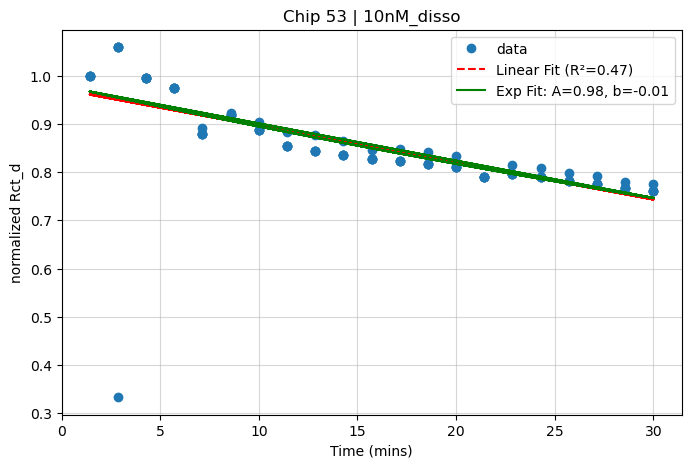

[0.81861902 0.29502685 0.27554058 0.85908694 0.79706988 0.78087076
 0.76016278 0.73632123 0.72537255 1.         0.81861902 0.88449749
 0.86922316 0.85908694 0.79706988 0.78087076 0.75821605 0.71487735
 0.69897159 1.         0.81861902 0.88449749 0.86922316 0.85908694
 0.79706988 0.78087076 0.75821605 0.71487735 0.69897159 1.
 0.81861902 0.88449749 0.86922316 0.85908694 0.79706988 0.78087076
 0.75821605 0.71487735 0.69897159 1.         0.81861902 0.88449749
 0.86922316 0.85908694 0.79706988 0.78087076 0.75821605 0.71487735
 0.69897159]  y
[0.81861902 0.29502685 0.27554058 0.85908694 0.79706988 0.78087076
 0.76016278 0.73632123 0.72537255 1.         0.81861902 0.88449749
 0.86922316 0.85908694 0.79706988 0.78087076 0.75821605 0.71487735
 0.69897159 1.         0.81861902 0.88449749 0.86922316 0.85908694
 0.79706988 0.78087076 0.75821605 0.71487735 0.69897159 1.
 0.81861902 0.88449749 0.86922316 0.85908694 0.79706988 0.78087076
 0.75821605 0.71487735 0.69897159 1.         0.81861902 0.8844

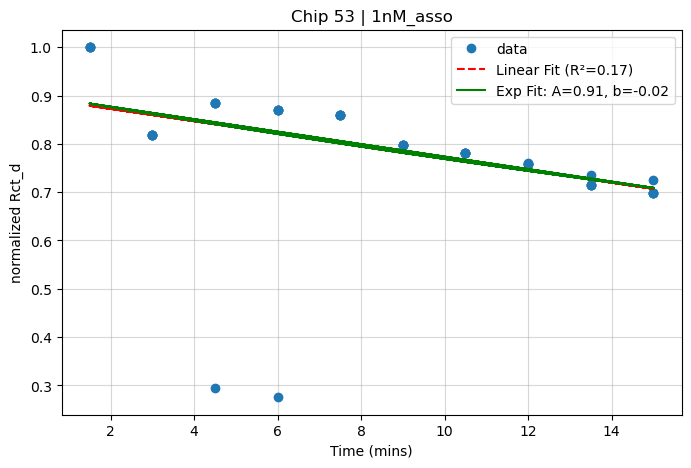

[0.34025947 1.02171319 0.98051926 0.93720223 0.9242214  0.89755153
 0.87281319 0.87151615 0.86530226 0.8539012  0.80812951 0.83738717
 0.8280733  0.81785886 0.81169592 0.80440207 0.7967157  0.78705309
 0.78198239 0.7742371  1.         1.06706729 1.02171319 0.98051926
 0.92654445 0.90634536 0.86363165 0.85223149 0.84533406 0.83785161
 0.83035077 0.80812951 0.81521007 0.80911998 0.80218786 0.79585089
 0.78799501 0.7829862  0.7744517  0.76937433 0.76159806 1.
 1.06706729 1.02171319 0.98051926 0.92654445 0.90634536 0.86363165
 0.85223149 0.84533406 0.83785161 0.83035077 0.80812951 0.81521007
 0.80911998 0.80218786 0.79585089 0.78799501 0.7829862  0.7744517
 0.76937433 0.76159806 1.         1.06706729 1.02171319 0.98051926
 0.92654445 0.90634536 0.86363165 0.85223149 0.84533406 0.83785161
 0.83035077 0.80812951 0.81521007 0.80911998 0.80218786 0.79585089
 0.78799501 0.7829862  0.7744517  0.76937433 0.76159806 1.
 1.06706729 1.02171319 0.98051926 0.92654445 0.90634536 0.86363165
 0.85223149 

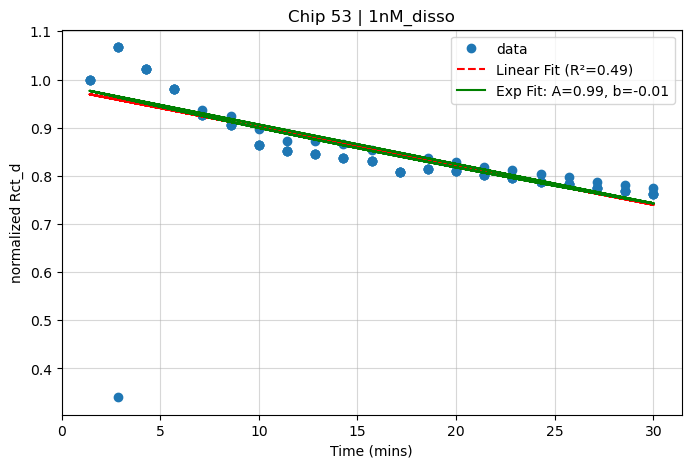

[0.95830099 0.93514221 0.9169485  0.90323699 0.92947435 0.91804674
 0.86722138 0.89517136 0.88495856 1.         0.94891161 0.92645448
 0.90795643 0.89330415 0.92191501 0.91100742 0.854849   0.89105641
 0.88022486]  y
[0.95830099 0.93514221 0.9169485  0.90323699 0.92947435 0.91804674
 0.86722138 0.89517136 0.88495856 1.         0.94891161 0.92645448
 0.90795643 0.89330415 0.92191501 0.91100742 0.854849   0.89105641
 0.88022486]  x


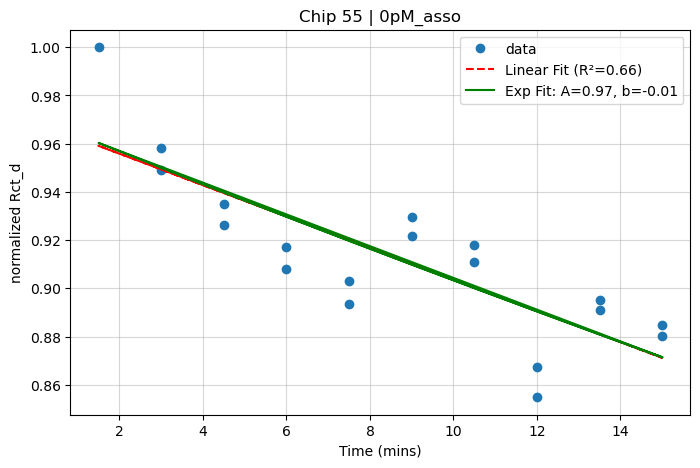

[0.93347393 0.95326976 0.94145511 0.93168597 0.92211634 0.87370456
 0.90274758 0.89432823 0.84397289 0.87606739 0.82698966 0.85996306
 0.85099346 0.84376842 0.8357716  0.82818253 0.8209528  0.81379436
 0.80645698 0.79929879 1.         0.93004551 0.95383335 0.93705354
 0.92852849 0.91966188 0.8658762  0.90276126 0.89369957 0.83576783
 0.87824308 0.81843473 0.86353072 0.85449737 0.83689899 0.84198515
 0.82302019 0.81506408 0.80984105 0.80259449 0.79730838]  y
[0.93347393 0.95326976 0.94145511 0.93168597 0.92211634 0.87370456
 0.90274758 0.89432823 0.84397289 0.87606739 0.82698966 0.85996306
 0.85099346 0.84376842 0.8357716  0.82818253 0.8209528  0.81379436
 0.80645698 0.79929879 1.         0.93004551 0.95383335 0.93705354
 0.92852849 0.91966188 0.8658762  0.90276126 0.89369957 0.83576783
 0.87824308 0.81843473 0.86353072 0.85449737 0.83689899 0.84198515
 0.82302019 0.81506408 0.80984105 0.80259449 0.79730838]  x


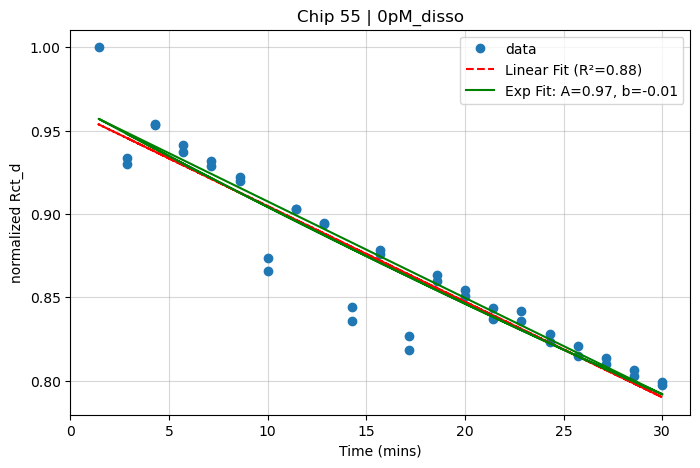

[0.86176674 0.82970063 0.88744776 0.80428802 0.79686721 0.78517046
 0.77685281 0.76910044 0.75824888 1.         0.87278843 0.8419004
 0.93926859 0.81693876 0.80775935 0.79837454 0.79141847 0.78176682
 0.77407316]  y
[0.86176674 0.82970063 0.88744776 0.80428802 0.79686721 0.78517046
 0.77685281 0.76910044 0.75824888 1.         0.87278843 0.8419004
 0.93926859 0.81693876 0.80775935 0.79837454 0.79141847 0.78176682
 0.77407316]  x


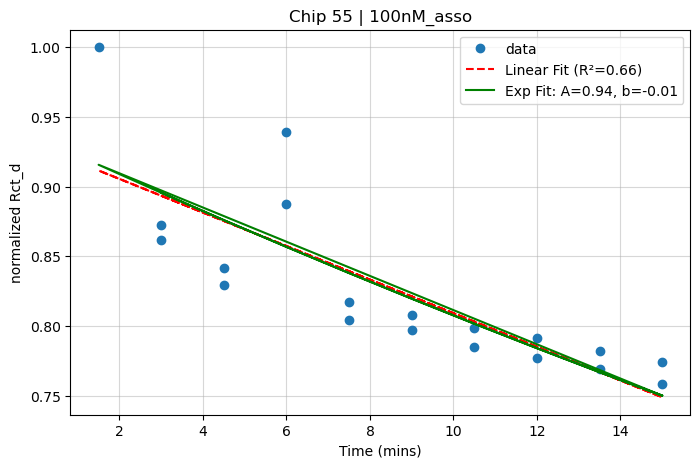

[0.94080938 0.92679934 0.91364603 0.90392261 0.89228134 0.88331567
 0.87139791 0.8614305  0.85351778 0.8829822  0.83641375 0.82674712
 0.85693399 0.8088807  0.80151934 0.79121125 0.82506743 0.81685989
 0.76957068 0.76520679 1.         0.94051665 0.92215148 0.91012764
 0.90119638 0.88836546 0.87731787 0.86695843 0.85778621 0.84850796
 0.88343614 0.82891598 0.82077906 0.85838691 0.80289873 0.79383264
 0.78611682 0.83108929 0.82314592 0.76338038 0.75431943]  y
[0.94080938 0.92679934 0.91364603 0.90392261 0.89228134 0.88331567
 0.87139791 0.8614305  0.85351778 0.8829822  0.83641375 0.82674712
 0.85693399 0.8088807  0.80151934 0.79121125 0.82506743 0.81685989
 0.76957068 0.76520679 1.         0.94051665 0.92215148 0.91012764
 0.90119638 0.88836546 0.87731787 0.86695843 0.85778621 0.84850796
 0.88343614 0.82891598 0.82077906 0.85838691 0.80289873 0.79383264
 0.78611682 0.83108929 0.82314592 0.76338038 0.75431943]  x


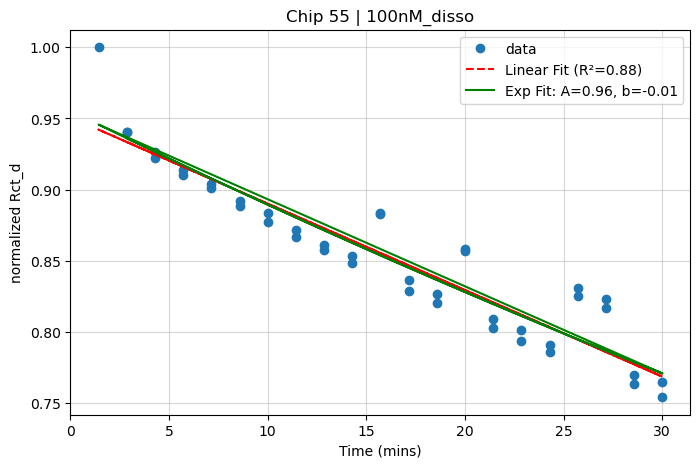

[0.85406799 0.82191575 0.80279846 0.79328626 0.78224761 0.77130031
 0.8109526  0.8031527  0.795245   1.         0.85456322 0.81879219
 0.80213719 0.79060716 0.77873408 0.76762535 0.81730563 0.8063516
 0.83090485]  y
[0.85406799 0.82191575 0.80279846 0.79328626 0.78224761 0.77130031
 0.8109526  0.8031527  0.795245   1.         0.85456322 0.81879219
 0.80213719 0.79060716 0.77873408 0.76762535 0.81730563 0.8063516
 0.83090485]  x


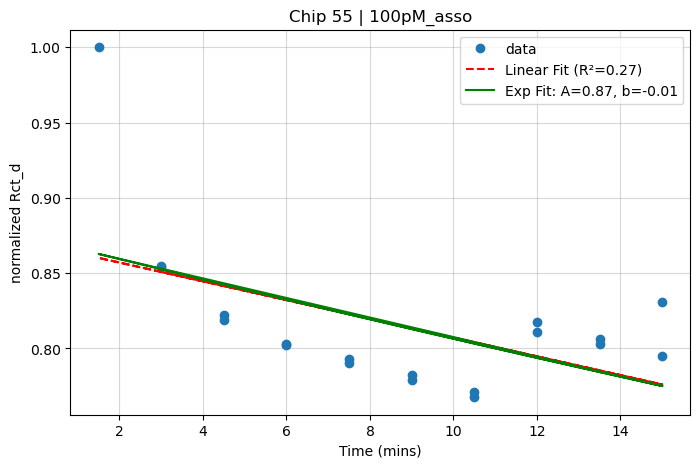

[0.95149132 0.97266061 0.96140642 0.91075374 0.94087301 0.93093699
 0.92217243 0.9131054  0.90408038 0.85416698 0.88642492 0.87826444
 0.8692432  0.85974131 0.85118241 0.84303546 0.79054529 0.82561898
 0.7751294  0.80875352 1.         0.94952738 0.97385043 0.96437914
 0.90523029 0.94431953 0.92586418 0.91730608 0.90773578 0.89980078
 0.84645377 0.88377214 0.87524925 0.86731843 0.85891926 0.85180575
 0.8426085  0.78315345 0.82731606 0.76393011 0.81331531]  y
[0.95149132 0.97266061 0.96140642 0.91075374 0.94087301 0.93093699
 0.92217243 0.9131054  0.90408038 0.85416698 0.88642492 0.87826444
 0.8692432  0.85974131 0.85118241 0.84303546 0.79054529 0.82561898
 0.7751294  0.80875352 1.         0.94952738 0.97385043 0.96437914
 0.90523029 0.94431953 0.92586418 0.91730608 0.90773578 0.89980078
 0.84645377 0.88377214 0.87524925 0.86731843 0.85891926 0.85180575
 0.8426085  0.78315345 0.82731606 0.76393011 0.81331531]  x


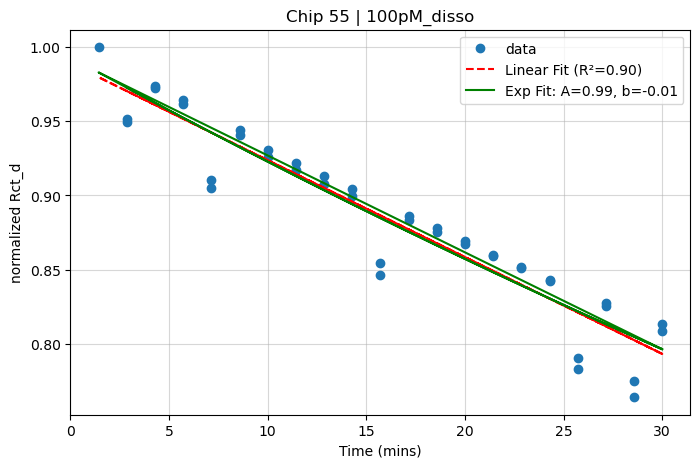

[0.84780547 0.8156663  0.84592732 0.78821768 0.77889428 0.81717354
 0.7601497  0.75145926 0.7909665  1.         0.84834282 0.8136001
 0.87196702 0.78766147 0.77828452 0.81943717 0.75741579 0.74913135
 0.79591429]  y
[0.84780547 0.8156663  0.84592732 0.78821768 0.77889428 0.81717354
 0.7601497  0.75145926 0.7909665  1.         0.84834282 0.8136001
 0.87196702 0.78766147 0.77828452 0.81943717 0.75741579 0.74913135
 0.79591429]  x


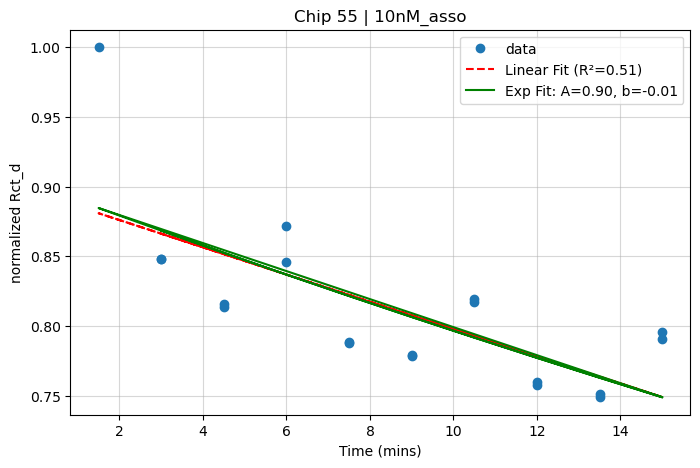

[0.94941718 0.93237058 0.92192286 0.94844712 0.93987948 0.93067003
 0.88426959 0.87425932 0.86715375 0.8973544  0.88842923 0.83852104
 0.87154906 0.8637257  0.85558888 0.84796209 0.83886071 0.831649
 0.82342795 0.81627896 1.         0.94936045 0.930596   0.92010552
 0.9550893  0.93782235 0.92815672 0.88185495 0.87317552 0.86385157
 0.8965612  0.88845385 0.83666937 0.87330675 0.86612283 0.85747052
 0.85068704 0.84084952 0.83495296 0.8271197  0.82092922]  y
[0.94941718 0.93237058 0.92192286 0.94844712 0.93987948 0.93067003
 0.88426959 0.87425932 0.86715375 0.8973544  0.88842923 0.83852104
 0.87154906 0.8637257  0.85558888 0.84796209 0.83886071 0.831649
 0.82342795 0.81627896 1.         0.94936045 0.930596   0.92010552
 0.9550893  0.93782235 0.92815672 0.88185495 0.87317552 0.86385157
 0.8965612  0.88845385 0.83666937 0.87330675 0.86612283 0.85747052
 0.85068704 0.84084952 0.83495296 0.8271197  0.82092922]  x


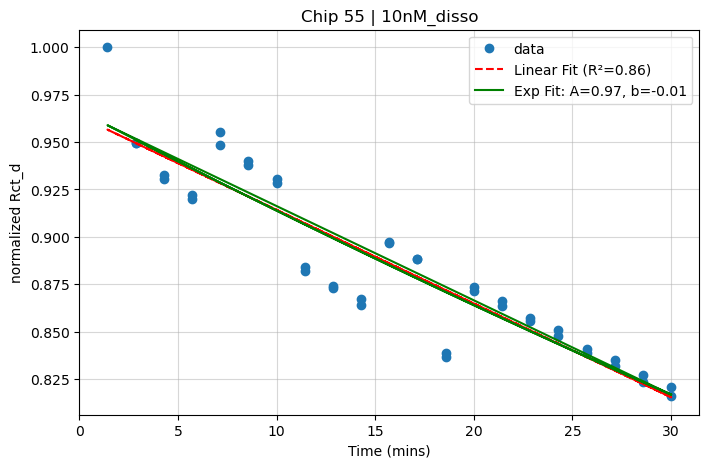

[0.84043638 0.8017478  0.78736028 0.7775788  0.76380598 0.80132264
 0.74714049 0.78317072 0.72795257 1.         0.83307342 0.79487871
 0.77958388 0.76760281 0.75750043 0.81006299 0.73688172 0.7953836
 0.71741771]  y
[0.84043638 0.8017478  0.78736028 0.7775788  0.76380598 0.80132264
 0.74714049 0.78317072 0.72795257 1.         0.83307342 0.79487871
 0.77958388 0.76760281 0.75750043 0.81006299 0.73688172 0.7953836
 0.71741771]  x


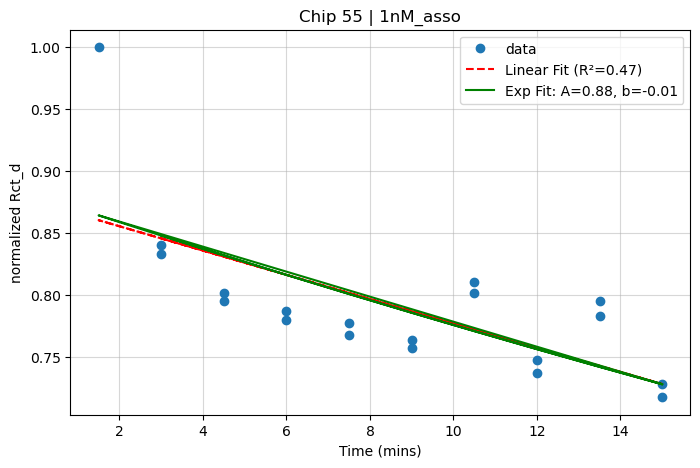

[0.95604802 0.97728273 0.92546605 0.95529923 0.94618345 0.89660739
 0.88762387 0.92146433 0.91307509 0.90490805 0.85407952 0.8472669
 0.84100426 0.83300252 0.82200471 0.85802465 0.85058052 0.84234238
 0.83554643 0.82770011 1.         0.94996346 0.97788482 0.91929758
 0.95247179 0.94446434 0.88997685 0.88060758 0.92172589 0.91423064
 0.90600896 0.84653002 0.83804212 0.83007348 0.82182903 0.8132671
 0.86308369 0.85682679 0.83743836 0.83068975 0.82368739]  y
[0.95604802 0.97728273 0.92546605 0.95529923 0.94618345 0.89660739
 0.88762387 0.92146433 0.91307509 0.90490805 0.85407952 0.8472669
 0.84100426 0.83300252 0.82200471 0.85802465 0.85058052 0.84234238
 0.83554643 0.82770011 1.         0.94996346 0.97788482 0.91929758
 0.95247179 0.94446434 0.88997685 0.88060758 0.92172589 0.91423064
 0.90600896 0.84653002 0.83804212 0.83007348 0.82182903 0.8132671
 0.86308369 0.85682679 0.83743836 0.83068975 0.82368739]  x


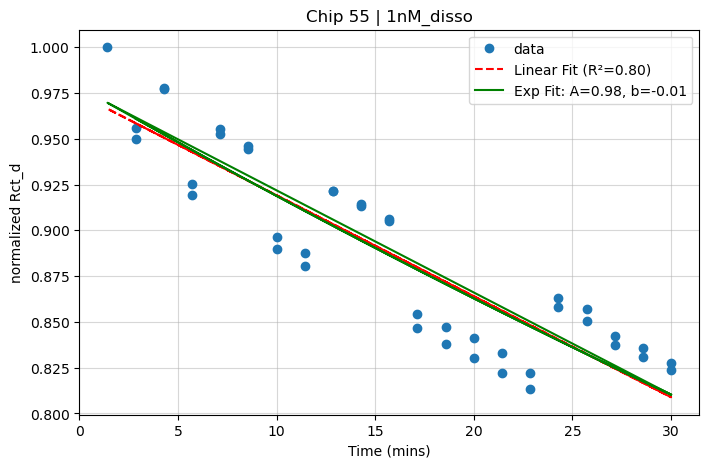

PDF saved to: /Users/deeptabharadwaj/Documents/lab/aranLab/AranLab/BioSensorAnalysisSrcCode/EIS_Analysis/Austin_EIS/MegaExcel/Processed Chips for PCAI1ia/Rct_vs_time_plots_normalized Rct_d.pdf
PDF saved to: /Users/deeptabharadwaj/Documents/lab/aranLab/AranLab/BioSensorAnalysisSrcCode/EIS_Analysis/Austin_EIS/MegaExcel/Processed Chips for PCAI1ia/Rct_vs_time_plots_normalized Rct_d_Subtracted.pdf
Created new folder: /Users/deeptabharadwaj/Documents/lab/aranLab/AranLab/BioSensorAnalysisSrcCode/EIS_Analysis/Austin_EIS/MegaExcel/Processed Chips for PCAI1ia/Big Excel Folder for Deependra
Moved: Big Excel normalized Rct_a.xlsx
Moved: Big Excel normalized Rct_a Subtracted.xlsx
Moved: Rct_vs_time_plots_normalized Rct_a.pdf
Moved: Rct_vs_time_plots_normalized Rct_a_Subtracted.pdf
Moved: Big Excel normalized Rct_d.xlsx
Moved: Big Excel normalized Rct_d Subtracted.xlsx
Moved: Rct_vs_time_plots_normalized Rct_d.pdf
Moved: Rct_vs_time_plots_normalized Rct_d_Subtracted.pdf
File organization complete. 

In [1]:
just_do_it = True
chip_choice = 1
if chip_choice == "all" or just_do_it == True:

    import os
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.backends.backend_pdf import PdfPages
    from scipy.stats import linregress
    from scipy.optimize import curve_fit
    import shutil

    # --- 1. Path and Data Loading Setup ---
    # Get the base directory dynamically to handle both script and interactive environments
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()

    # Define the processed chips folder path
    processed_chips_folder_path = os.path.join(base_dir, "Processed Chips for PCAI1ia")

    # Make sure the folder exists (create it if not)
    os.makedirs(processed_chips_folder_path, exist_ok=True)
    folder_path = processed_chips_folder_path

    print("Using folder:", folder_path)

    if not folder_path:
        print("No folder selected. Exiting.")
        exit()

    plot_boolean = False  # set True if you want plots

    CHIP_INFO = {
        #"CHIP TEMPLATE" : ["Cas_{complex} or Cas_{only}","{0.5} or {1} or {5} Conentration of MgCl2", "{HU} protein or {SCDU} protein"],
        'Chip 21': ["Cas_complex"   ,"0.5"   ,"HU"     ],
        'Chip 22': ["Cas_complex"   ,"0.5"   ,"HU"     ],
        'Chip 23': ["Cas_complex"   ,"5"     ,"SCDU"   ],
        'Chip 26': ["Cas_complex"   ,"5"     ,"HU"     ],
        'Chip 27': ["Cas_complex"   ,"5"     ,"HU"     ],
        'Chip 32': ["Cas_complex"   ,"5"     ,"HU"     ],
        'Chip 33': ["Cas_only"      ,"1"     ,"HU"     ],
        'Chip 35': ["Cas_complex"   ,"1"     ,"HU"     ],
        'Chip 36': ["Cas_only"      ,"1"     ,"HU"     ],
        'Chip 37': ["Cas_complex"   ,"1"     ,"HU"     ],
        'Chip 39': ["Cas_complex"   ,"1"     ,"HU"     ],
        'Chip 40': ["Cas_complex"   ,"1"     ,"HU"     ],
        'Chip 41': ["Cas_complex"   ,"1"     ,"SCDU"   ],
        'Chip 43': ["Cas_complex"   ,"5"     ,"SCDU"   ],
        'Chip 44': ["Cas_complex"   ,"5"     ,"SCDU"   ],
        'Chip 45': ["Cas_only"      ,"5"     ,"HU"     ],
        'Chip 46': ["Cas_complex"   ,"1"     ,"SCDU"   ],
        'Chip 47': ["Cas_only"      ,"1"     ,"HU"     ],
        'Chip 48': ["cas_complex"   ,"5"     ,"SCDU"   ],
        'Chip 52': ["Cas_complex"   ,"5"     ,"HU"     ],
        'Chip 53': ["Cas_complex"   ,"1"     ,"SCDU"   ],
        'Chip 54': ["Cas_only"      ,"5"     ,"HU"     ],
        'Chip 55': ["Cas_complex"   ,"1"     ,"SCDU"   ],
        'Chip 56': ["Cas_only"      ,"5"     ,"HU"     ],
        'Chip 57': ["Cas_only"      ,"5"     ,"HU"     ],
        'Chip 59': ["Cas_complex"   ,"0.5"   ,"HU"     ]
    }

    # Constants
    workbook_names = [f"Chip {n}" for n in [21,22,23,26,27,32,33,35,36,37,39,40,41,43,44,45,46,47,48,52,53,54,55,56,57,59]]
    worksheet_names = ["0pM_asso", "100pM_asso", "1nM_asso", "10nM_asso", "100nM_asso","0pM_disso", "100pM_disso",  "1nM_disso", "10nM_disso", "100nM_disso"]
    headers = [
        'time(mins)', 'delta Rct-a', 'normalized Rct_a','delta Rct-d','normalized Rct_d', 'Cp1', 'Ph1', 
        'Slope 1', 'Slope 2', 'Slope 3', 'Slope 4', 'Slope 5', 
        'Angle', 'Cp_exp-a', 'Cp_exp-b', 'Ph_slope', 'Ph_peak', 
        'Area Cp', 'Area Ph', 'Area Slope', 'Area Rs-direct', 'Area Rs-Para',
        '','','linear_eq_m','linear_eq_b','Rs','delta Rct-i','Q','n'
    ]
    # Read and combine all data
    all_data = []
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        chip_name = os.path.splitext(file_name)[0]

        if chip_name not in workbook_names or not file_path.endswith(".xlsx"):
            continue

        xl = pd.ExcelFile(file_path)
        for sheet in xl.sheet_names:
            if sheet not in worksheet_names:
                continue

            df = xl.parse(sheet, usecols=lambda col: col in headers)
            df['chip'] = chip_name
            df['sheet'] = sheet
            all_data.append(df)

    if not all_data:
        print("No valid data found.")
        exit()

    df_all = pd.concat(all_data, ignore_index=True)

    # Add CHIP_INFO metadata
    chip_info_df = pd.DataFrame.from_dict(CHIP_INFO, orient='index', columns=['Type', 'Concentration', 'Protein']).reset_index().rename(columns={'index': 'chip'})
    df_all = df_all.merge(chip_info_df, on='chip', how='left')

    # --- Build multi-index pivot with MgCl2 and type filters ---
    df_mgcl1_com = df_all[
        (df_all['Concentration'] == "1") & 
        (df_all['Type'] == "Cas_complex")
    ]

    pivot_df = df_mgcl1_com.pivot_table(
        index='time(mins)',
        columns=['sheet', 'Protein', 'chip'],
        values='normalized Rct_a',
        aggfunc='first'
    ).reset_index()

    # --- Define exponential fit function ---
    def exp_func(x, A, b):
        return A * np.exp(b * x)

    # --- Main processing loop for both normalized Rct_a and Rct_d ---
    for value_col in ["normalized Rct_a", "normalized Rct_d"]:
        print(f"\nProcessing: {value_col}\n")

        # Filter chips: MgCl2 == 1 and Cas_complex
        df_mgcl1_com = df_all[
            (df_all['Concentration'] == "1") &
            (df_all['Type'] == "Cas_complex")
        ]

        # Pivot table (normal values)
        pivot_df = df_mgcl1_com.pivot_table(
            index='time(mins)',
            columns=['sheet', 'Protein', 'chip'],
            values=value_col,
            aggfunc='first'
        ).reset_index()

        # --- Save Normal Excel ---
        output_file = os.path.join(folder_path, f"Big Excel {value_col}.xlsx")
        #with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer: # for austin
        with pd.ExcelWriter(output_file, engine='openpyxl') as writer: #for deepta
            pivot_df_flat = pivot_df.copy()
            pivot_df_flat.columns = [f"{col[0]}_{col[1]}_{col[2]}" if isinstance(col, tuple) else col for col in pivot_df.columns]
            pivot_df_flat.to_excel(writer, sheet_name="Summary", index=False, startrow=3)
        print(f"Excel saved to: {output_file}")

        # --- Baseline subtraction ---
        subtracted = []
        for chip in workbook_names:
            for protein in df_mgcl1_com["Protein"].unique():
                df_chip = df_mgcl1_com[(df_mgcl1_com["chip"] == chip) & (df_mgcl1_com["Protein"] == protein)]
                if df_chip.empty: 
                    continue

                # Get baseline asso/disso curves
                base_asso = df_chip[df_chip["sheet"] == "0pM_asso"][[value_col]].reset_index(drop=True)
                base_disso = df_chip[df_chip["sheet"] == "0pM_disso"][[value_col]].reset_index(drop=True)

                for sheet in ["100pM_asso", "1nM_asso", "10nM_asso", "100nM_asso"]:
                    df_target = df_chip[df_chip["sheet"] == sheet][[value_col, "time(mins)"]].reset_index(drop=True)
                    if not df_target.empty and not base_asso.empty:
                        df_target[value_col] = df_target[value_col] - base_asso[value_col]
                        df_target["chip"] = chip
                        df_target["Protein"] = protein
                        df_target["sheet"] = sheet + "_minus0pM"
                        subtracted.append(df_target)

                for sheet in ["100pM_disso", "1nM_disso", "10nM_disso", "100nM_disso"]:
                    df_target = df_chip[df_chip["sheet"] == sheet][[value_col, "time(mins)"]].reset_index(drop=True)
                    if not df_target.empty and not base_disso.empty:
                        df_target[value_col] = df_target[value_col] - base_disso[value_col]
                        df_target["chip"] = chip
                        df_target["Protein"] = protein
                        df_target["sheet"] = sheet + "_minus0pM"
                        subtracted.append(df_target)

        if subtracted:
            df_sub = pd.concat(subtracted, ignore_index=True)
            pivot_sub = df_sub.pivot_table(
                index="time(mins)",
                columns=["sheet", "Protein", "chip"],
                values=value_col,
                aggfunc="first"
            ).reset_index()

            # Save Subtracted Excel
            output_file_sub = os.path.join(folder_path, f"Big Excel {value_col} Subtracted.xlsx")
            #with pd.ExcelWriter(output_file_sub, engine="xlsxwriter") as writer: #for austin
            with pd.ExcelWriter(output_file_sub, engine="openpyxl") as writer: #for deepta
            
                pivot_sub_flat = pivot_sub.copy()
                pivot_sub_flat.columns = [f"{col[0]}_{col[1]}_{col[2]}" if isinstance(col, tuple) else col for col in pivot_sub.columns]
                pivot_sub_flat.to_excel(writer, sheet_name="Summary", index=False, startrow=3)
            print(f"Excel saved to: {output_file_sub}")

        # --- Normal PDF with linear regression + exponential fit ---
        pdf_file = os.path.join(folder_path, f"Rct_vs_time_plots_{value_col}.pdf")
        with PdfPages(pdf_file) as pdf:
            for (chip, sheet), sub_df in df_mgcl1_com.groupby(["chip", "sheet"]):
                plt.figure(figsize=(8, 5))
                x = sub_df["time(mins)"].iloc[1:].values
                y = sub_df[value_col].iloc[1:].values
                print(y," y")
                print(sub_df[value_col].iloc[1:].values," x") #maxfev=5000

                if len(x) < 2: 
                    plt.close()
                    continue

                # Scatter plot
                plt.plot(x, y, "o", label="data")

                # Linear regression
                slope, intercept, r_value, _, _ = linregress(x, y)
                plt.plot(x, slope * x + intercept, "r--", label=f"Linear Fit (R²={r_value**2:.2f})")

                # Exponential fit
                try:
                    popt, _ = curve_fit(exp_func, x, y, maxfev=5000)
                    plt.plot(x, exp_func(x, *popt), "g-", label=f"Exp Fit: A={popt[0]:.2f}, b={popt[1]:.2f}")
                except Exception as e:
                    pass

                plt.xlabel("Time (mins)")
                plt.ylabel(value_col)
                plt.title(f"{chip} | {sheet}")
                plt.legend()
                plt.grid(True, alpha=0.5)
                pdf.savefig()
                plt.show()
                plt.close()

        print(f"PDF saved to: {pdf_file}")

        # --- Subtracted PDF ---
        if subtracted:
            pdf_file_sub = os.path.join(folder_path, f"Rct_vs_time_plots_{value_col}_Subtracted.pdf")
            with PdfPages(pdf_file_sub) as pdf:
                for (chip, sheet), sub_df in df_sub.groupby(["chip", "sheet"]):
                    plt.figure(figsize=(8, 5))
                    x = sub_df["time(mins)"].iloc[1:].values
                    y = sub_df[value_col].iloc[1:].values

                    if len(x) < 2: 
                        plt.close()
                        continue

                    plt.plot(x, y, "o", label="data")

                    slope, intercept, r_value, _, _ = linregress(x, y)
                    plt.plot(x, slope * x + intercept, "r--", label=f"Linear Fit (R²={r_value**2:.2f})")

                    try:
                        popt, _ = curve_fit(exp_func, x, y, maxfev=5000)
                        plt.plot(x, exp_func(x, *popt), "g-", label=f"Exp Fit: A={popt[0]:.2f}, b={popt[1]:.2f}")
                    except:
                        pass

                    plt.xlabel("Time (mins)")
                    plt.ylabel(value_col)
                    plt.title(f"{chip} | {sheet}")
                    plt.legend()
                    plt.grid(True, alpha=0.5)
                    pdf.savefig()
                    #plt.show()
                    plt.close()

            print(f"PDF saved to: {pdf_file_sub}")

    # --- File Organization Section ---
    # 1. Define the name of the new subfolder for the output files.
    output_subfolder = "Big Excel Folder for Deependra"
    output_path = os.path.join(folder_path, output_subfolder)

    # 2. Create the new folder if it doesn't exist.
    os.makedirs(output_path, exist_ok=True)
    print(f"Created new folder: {output_path}")

    # 3. Identify the files you want to move.
    files_to_move = [
        f"Big Excel normalized Rct_a.xlsx",
        f"Big Excel normalized Rct_a Subtracted.xlsx",
        f"Rct_vs_time_plots_normalized Rct_a.pdf",
        f"Rct_vs_time_plots_normalized Rct_a_Subtracted.pdf",
        f"Big Excel normalized Rct_d.xlsx",
        f"Big Excel normalized Rct_d Subtracted.xlsx",
        f"Rct_vs_time_plots_normalized Rct_d.pdf",
        f"Rct_vs_time_plots_normalized Rct_d_Subtracted.pdf"
    ]

    # 4. Loop through the files and move them.
    for filename in files_to_move:
        source_file_path = os.path.join(folder_path, filename)
        destination_file_path = os.path.join(output_path, filename)

        # Check if the file exists before trying to move it.
        if os.path.exists(source_file_path):
            try:
                shutil.move(source_file_path, destination_file_path)
                print(f"Moved: {filename}")
            except Exception as e:
                print(f"Error moving {filename}: {e}")
        else:
            print(f"Skipping: {filename} (File not found)")

    print("File organization complete. ✨")

    print("Done.")
else:
    print("Next time.")